# Preprocesamiento de datos para el cálculo del Jet Lag Social
 
**Laura Llamas López** · **TFM** · **Máster en Bioinformática · Universidad de Murcia · Curso 2025/26**

---

## Contexto

El jet lag social (SJL) es la discrepancia entre el ritmo de sueño que el cuerpo seguiría de forma natural y el que impone la rutina laboral o académica. Se cuantifica como la diferencia entre el centro del sueño en días libres (MSF) y el centro del sueño en días laborables (MSW), siguiendo la definición operativa formalizada por Wittmann et al. [1]. Un valor elevado de SJL se ha asociado en la literatura con peor salud metabólica [2, 3, 4], mayor riesgo cardiovascular [5, 6] y peor salud mental [7, 8].

Los datos a procesar proceden del dispositivo de monitorización ambulatoria Kronowise®, que registra de forma continua, a intervalos de 30 segundos, actividad motora, luz ambiental, temperatura cutánea y posición corporal. La señal resultante constituye un registro de monitorización circadiana ambulatoria (MCA), almacenado en un fichero `.txt` por sujeto. El Cuaderno de Recogida de Datos (CRD) está gestionado a través de la plataforma [KRONO](https://krono.imib.es/), alojada en el Instituto Murciano de Investigación Biosanitaria Pascual Parrilla (IMIB).

---

## Estructura

Este notebook cubre el preprocesamiento completo desde la descarga de los datos brutos hasta la obtención de la cohorte final con las variables del SJL calculadas:

0. **Configuración del entorno**: importaciones y rutas del proyecto.
1. **Autenticación** contra el CRD del IMIB mediante `imib-pyutils`.
2. **Construcción del dataset base**: carga, deduplicación y unión de las cuatro entidades del CRD; cálculo de variables derivadas (edad, IMC); filtrado de registros inválidos; codificación uniforme de patologías; auditoría de cobertura.
3. **Calendario de festivos**: construcción de un calendario nacional, autonómico (Murcia) y local (Murcia capital) con tres niveles de inclusión para análisis de sensibilidad.
4. **Cohorte de análisis**: aplicación de los criterios de inclusión (primera visita, scoring manual y umbrales mínimos de días laborables y libres).
5. **Cruce con el índice de documentos** y **descarga masiva** de los ficheros `.txt` de MCA.
6. **Parseo de los `.txt`**: estructuración de las épocas de 30 s en un DataFrame, con detección automática de la versión del dispositivo.
7. **Cálculo del Jet Lag Social** noche a noche, con tres variantes metodológicas.

Tras el pipeline, el **material suplementario** reúne dos análisis de apoyo: **S1**, sensibilidad del SJL al calendario de días libres; y **S2**, una vía de limpieza de los TXT explorada pero no incorporada al análisis final.

---

## Configuración del entorno

Pasos realizados desde terminal una sola vez al crear el proyecto:

```bash
# 1. Ir a la carpeta raíz del proyecto
cd ~/TFM

# 2. Crear el entorno virtual con Python 3.13
python3 -m venv venv

# 3. Crear el fichero de variables de entorno con las credenciales del CRD
nano .env

# 4. Activar el entorno e instalar dependencias
source venv/bin/activate
pip install pandas numpy matplotlib requests python-dotenv ipykernel holidays==0.98 python-dateutil joblib jinja2
pip install git+https://<username>:<token>@devops.imib.es/AISBIB/imib-pyutils.git

# 5. Registrar el entorno como kernel de Jupyter
python -m ipykernel install --user --name tfm-venv --display-name "TFM (Python 3.13)"

deactivate
```

Variables necesarias en `.env` (en la raíz del proyecto):

```
IMIB_USERNAME=
IMIB_PASSWORD=
```


---
## 0. Configuración

Las importaciones y las rutas del proyecto se concentran aquí para que el entorno quede completamente inicializado.

In [1]:
import os
import io
import json
import time
import zipfile
import datetime
from dateutil.easter import easter
from contextlib import contextmanager
from concurrent.futures import ThreadPoolExecutor, as_completed

import dotenv
import holidays
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import Parallel, delayed
from scipy.stats import circmean
from imib_pyutils.oauth import OAuth2SessionIMIB

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from IPython.display import display

# Opciones de visualización
pd.set_option("display.max_columns", None)   # mostrar todas las columnas en head/display
pd.set_option("display.max_colwidth", 80)    # evitar que las celdas de texto se trunquen demasiado
pd.set_option("display.float_format", "{:.4f}".format)

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [2]:
# Rutas del proyecto
RAW = Path("data/raw")
RAW_CRD = RAW / "crd"
RAW_MCA = RAW / "mca_txt"
RAW_MCA_LIMPIO = RAW / "mca_txt_limpio"

PROCESSED = Path("data/processed")

for d in [RAW_CRD, RAW_MCA, RAW_MCA_LIMPIO, PROCESSED]:
    d.mkdir(parents=True, exist_ok=True)


---
## 1. Cargar credenciales y autenticación

`imib-pyutils` gestiona la autenticación contra el CRD. Las credenciales se leen del fichero `.env` mediante `python-dotenv`, de forma que no aparecen explícitas en el código.

El objeto de sesión resultante (`session`) se reutilizará en todas las llamadas posteriores a los endpoints.

In [3]:
# Cargar credenciales desde .env (en la raíz del proyecto)
dotenv_path = os.path.join(os.getcwd(), ".env")
config = dotenv.dotenv_values(dotenv_path)

assert config["IMIB_USERNAME"] and config["IMIB_PASSWORD"], "Faltan credenciales en el .env"
print("Credenciales cargadas correctamente.")


Credenciales cargadas correctamente.


Para no repetir en cada llamada a un endpoint el bloque `try / with OAuth2SessionIMIB() / fetch_token / except / raise`, se define el context manager `get_sesion_imib()`. Encapsula la apertura de la sesión, la autenticación y el manejo uniforme de errores, de modo que las celdas posteriores se reducen a `with get_sesion_imib() as sesion: r = sesion.get(URL)` y pueden centrarse en lo específico de cada endpoint (qué URL se llama y qué se hace con la respuesta).



In [4]:
@contextmanager
def get_sesion_imib():
    """Context manager: abre una sesión OAuth2 contra el CRD ya autenticada.

    Encapsula el patrón try/with/fetch_token/except/raise que se usa en cada
    llamada a un endpoint, para que las celdas de descarga puedan limitarse a
    `with get_sesion_imib() as sesion: r = sesion.get(URL)` y centrarse en el
    procesamiento de la respuesta.
    """
    try:
        with OAuth2SessionIMIB() as sesion:
            sesion.fetch_token(
                username=config["IMIB_USERNAME"],
                password=config["IMIB_PASSWORD"],
            )
            yield sesion
    except Exception as e:
        print(f"Ha ocurrido un error en la sesión OAuth: {e}")
        raise


La celda siguiente es una **prueba de conectividad**: simplemente abre la sesión y la cierra para verificar que las credenciales son válidas y el servidor responde. Si las credenciales son incorrectas o el servidor no está disponible, la función auxiliar imprime el motivo y re-lanza la excepción para detener la ejecución inmediatamente.



In [5]:
with get_sesion_imib() as sesion:
    print("Autenticación correcta")


Autenticación correcta


---
## 2. Construcción del dataset base

Esta sección cubre la carga de las cuatro entidades del CRD desde los ficheros CSV generados por el script R, su unión en una tabla maestra, la generación de variables derivadas y los filtros de limpieza aplicados en este primer preprocesamiento.


### Prerequisito: descarga de entidades CRD con R

La descarga se realiza con la librería R `semanticCRFR`, que encapsula la autenticación y el acceso a las entidades.

**Antes de ejecutar este notebook** debe haberse lanzado el script `descarga_entidades.R`, que lee las credenciales del `.env` y descarga las cuatro tablas del proyecto KRONO, dejándolas en `data/raw/crd/`:

- `patients.csv`
- `salidas_circadianas_522.csv`
- `no_parametricos_523.csv`
- `descriptivos_329.csv`


### Construcción de la tabla maestra

Las cuatro entidades CRD se unen en una única tabla `df_crd`, que sirve de punto de partida para el resto de la sección.

| Entidad | Granularidad | Rol en el merge | Variables representativas |
|---|---|---|---|
| **patients** | una fila por sujeto | tabla izquierda; clave `id_paciente` | sexo, fecha de nacimiento, rama de estudio, centro y fecha de reclutamiento |
| **522** — salidas circadianas | una fila por visita | tabla base, `how="right"`; clave `(id_paciente, codigo_visita)` | cronotipo (etiqueta y valor numérico), eficiencia del sueño, latencia, robustez circadiana y porcentajes de actividad |
| **523** — métricas no paramétricas | una fila por visita | `how="left"`; clave `(id_paciente, codigo_visita)` | IS, IV, RA, M5, L10, M10, L5, CFI y CHS |
| **329** — descriptivos | una fila por visita | `how="left"`; clave `(id_paciente, codigo_visita)` | peso, altura, IMC y diagnósticos |


### Carga y deduplicación interna de cada entidad

Se cargan los cuatro ficheros CSV del CRD y, dentro de cada entidad (522, 523, 329), se resuelven los registros repetidos por `(id_paciente, codigo_visita)` con la función `deduplicar_visitas_repetidas`. El criterio de priorizar la fecha de inicio más temprana está motivado por el filtro de construcción de cohorte, que conserva únicamente la visita basal (la primera en el tiempo) de cada sujeto. Estos duplicados pueden tener dos orígenes distintos:

1. **Re-subida de la misma visita.** Tras subir un análisis al CRD se detecta algún problema en los datos originales (por ejemplo, que el marcado del sueño requería corrección) y se vuelve a procesar y subir el fichero. Cada nueva subida genera un registro adicional con un `form` mayor pero comparte la misma fecha de `inicio`. Interesa conservar el `form` más alto, que es la versión revisada y definitiva.
2. **Reutilización del `codigo_visita` para visitas distintas.** Un mismo código se ha asignado a registros con fechas de `inicio` diferentes. Conservar el `form` más alto descartaría precisamente la visita basal, que es la que selecciona el filtro posterior de cohorte.

La regla cubre ambos casos en una sola pasada: se ordena por `inicio` ascendente y, como desempate, por `form` descendente, conservando la primera fila por clave. Así, cuando los registros comparten `inicio` (re-subida) prevalece el `form` más alto, y cuando difieren (reutilización) prevalece la visita más temprana.

La entidad de descriptivos (329) registra la columna `form` pero no `inicio`/`fin`, porque recoge datos a nivel de sujeto y no la ventana temporal de una visita. Por eso su deduplicación se resuelve por `form` descendente, conservando el análisis procesado más recientemente, que es la versión revisada y definitiva. Como verificación, se comprueba que las filas duplicadas comparten el mismo contenido analítico: lo es en el 95% de los grupos. El 5% restante se inspeccionó caso por caso: son expedientes de prueba (que retirará el filtro de test), errores antropométricos puntuales (acotados por los filtros de altura y edad) o re-codificaciones clínicas en las que el `form` más alto es justamente la versión corregida. En todos ellos la regla del `form` y los filtros de limpieza posteriores resuelven la deduplicación.

> Este paso resuelve únicamente duplicados dentro de un mismo `id_paciente`. La sección *Eliminación de duplicados administrativos* se encarga de un caso distinto y complementario: el mismo sujeto físico cargado bajo dos `id_paciente` diferentes.

In [6]:
MERGE_KEYS = ["id_paciente", "codigo_visita"]

# Columnas de fecha del CRD. Se convierten a datetime al cargar las entidades.
COLS_FECHA = ["inicio", "fin", "fecha_visita", "fecha_nacimiento",
              "fecha_reclutamiento"]


def deduplicar_visitas_repetidas(df, keys=MERGE_KEYS):
    """Elimina, dentro de un mismo CSV de entidad, las filas repetidas por
    `(id_paciente, codigo_visita)`. Cuando la entidad lleva `inicio`, ordena
    por (`inicio` ASC, `form` DESC) y conserva la primera fila por clave: así
    cuando los duplicados comparten `inicio` (re-subida) prevalece el `form`
    más alto, y cuando difieren (reutilización de `codigo_visita`) prevalece
    la visita más temprana. En el resto, conserva el `form` más alto.
    """
    if "inicio" in df.columns:
        df = (df.sort_values(["inicio", "form"], ascending=[True, False])
                .drop_duplicates(subset=keys, keep="first")
                .reset_index(drop=True))
    else:
        df = (df.sort_values("form", ascending=False)
                .drop_duplicates(subset=keys, keep="first")
                .reset_index(drop=True))
    return df


def _diagnostico_duplicados(df, nombre):
    """Cuenta los grupos (id_paciente, codigo_visita) con más de una fila antes
    de deduplicar y las filas que se eliminarán. Cuando la entidad lleva
    `inicio`, desglosa los grupos en re-subida (mismo `inicio`) y
    reutilización del `codigo_visita` (`inicio` distintos).
    """
    if "inicio" in df.columns:
        agg = df.groupby(MERGE_KEYS, dropna=False).agg(
            n=("id_paciente", "size"),
            n_inicios=("inicio", "nunique"),
        )
        dup = agg[agg["n"] > 1]
        n_grupos = len(dup)
        if n_grupos == 0:
            print(f"  {nombre:8s}: 0 grupos duplicados")
            return
        n_eliminadas = int(dup["n"].sum() - n_grupos)
        n_resubida = int((dup["n_inicios"] == 1).sum())
        n_reuso = int((dup["n_inicios"] > 1).sum())
        print(f"  {nombre:8s}: {n_grupos:>4} grupos → {n_eliminadas:>4} filas eliminadas  "
              f"(re-subida: {n_resubida:>4} | reutilización de codigo_visita: {n_reuso:>4})")
        return

    tam = df.groupby(MERGE_KEYS, dropna=False).size()
    dup = tam[tam > 1]
    n_grupos = len(dup)
    if n_grupos == 0:
        print(f"  {nombre:8s}: 0 grupos duplicados")
        return
    n_eliminadas = int(dup.sum() - n_grupos)
    print(f"  {nombre:8s}: {n_grupos:>4} grupos → {n_eliminadas:>4} filas eliminadas")


def _audit_contenido_329(df_329):
    """329 es la entidad de descriptivos (datos a nivel de sujeto: antropometría
    y características clínicas). Para los grupos duplicados por
    (id_paciente, codigo_visita) comprueba si las filas repetidas comparten un
    contenido analítico idéntico. Cuando lo es, la regla del `form` máximo es
    inocua: cualquier fila del grupo deja el mismo resultado downstream. Las
    diferencias residuales son errores antropométricos puntuales y campos clínicos dispersos.
    """
    # Campos a comparar: solo el contenido analítico a nivel de sujeto que usan
    # los análisis posteriores —antropometría (peso, altura) y las características
    # clínicas `caracteristicas_sujeto.*`—. Se dejan fuera a propósito los
    # identificadores y metadatos administrativos (form, fechas, sensor, estado…),
    # que cambian en cada subida; las etiquetas de clasificación de estudio
    # (`tipo_estudio.*`, `caracteristicas_estudio.*`), que no son contenido clínico
    # y se descartan aguas abajo; e `imc`, derivada de peso/altura.
    cols_compara = ["peso_kg", "altura_cm"] + [
        c for c in df_329.columns if c.startswith("caracteristicas_sujeto.")
    ]
    tam = df_329.groupby(MERGE_KEYS, dropna=False).size()
    claves = list(map(tuple, tam[tam > 1].index.tolist()))
    if not claves:
        return
    sub = df_329.merge(pd.DataFrame(claves, columns=MERGE_KEYS),
                       on=MERGE_KEYS, how="inner")
    g = sub.groupby(MERGE_KEYS, dropna=False)[cols_compara]
    n_grupos = g.ngroups
    n_iden = int((g.nunique(dropna=False).max(axis=1) <= 1).sum())
    print("\n329 (descriptivos) — contenido analítico entre las filas duplicadas:")
    print(f"  idéntico:  {n_iden:>4}/{n_grupos}  ({100*n_iden/n_grupos:.0f}%)")
    print(f"  difiere:   {n_grupos - n_iden:>4}/{n_grupos}  "
          f"({100*(n_grupos - n_iden)/n_grupos:.0f}%)  — antropometría puntual "
          f"y campos clínicos dispersos")


# Carga de las cuatro entidades + conversión en sitio de las columnas de
# fecha. Pandas autoinfiere los tipos numéricos pero no las fechas.
df_patients = pd.read_csv(RAW_CRD / "patients.csv", low_memory=False, encoding="utf-8-sig")
df_522 = pd.read_csv(RAW_CRD / "salidas_circadianas_522.csv", low_memory=False, encoding="utf-8-sig")
df_523 = pd.read_csv(RAW_CRD / "no_parametricos_523.csv", low_memory=False, encoding="utf-8-sig")
df_329 = pd.read_csv(RAW_CRD / "descriptivos_329.csv", low_memory=False, encoding="utf-8-sig")

for d in (df_patients, df_522, df_523, df_329):
    for c in COLS_FECHA:
        if c in d.columns:
            d[c] = pd.to_datetime(d[c], errors="coerce")

# Diagnóstico previo a la deduplicación: grupos duplicados y filas que se
# eliminan por entidad y, en las que llevan `inicio`, su desglose en re-subida
# y reutilización.
print("Duplicados (id_paciente, codigo_visita) antes de deduplicar")
print("(cada grupo reúne 2 o más filas de la misma visita; se conserva 1 y se eliminan las restantes):")
for nombre, d in [("522", df_522), ("523", df_523), ("329", df_329)]:
    _diagnostico_duplicados(d, nombre)

# Verificar que las filas duplicadas en 329 comparten el mismo contenido
# analítico, lo que confirma que la regla del `form` máximo no altera la
# información que llega al dataset.
_audit_contenido_329(df_329)

print()

# Aplicación de la deduplicación
df_522_dedup = deduplicar_visitas_repetidas(df_522)
df_523_dedup = deduplicar_visitas_repetidas(df_523)
df_329_dedup = deduplicar_visitas_repetidas(df_329)

for nombre, d in [("patients", df_patients), ("522", df_522), ("523", df_523), ("329", df_329)]:
    print(f"  {nombre:8s}: {d.shape[0]:>5} filas × {d.shape[1]} columnas")
print()
print(f"Tras deduplicación → 522: {len(df_522_dedup)} | 523: {len(df_523_dedup)} | 329: {len(df_329_dedup)}")

Duplicados (id_paciente, codigo_visita) antes de deduplicar
(cada grupo reúne 2 o más filas de la misma visita; se conserva 1 y se eliminan las restantes):
  522     :  154 grupos →  164 filas eliminadas  (re-subida:  147 | reutilización de codigo_visita:    7)
  523     :  150 grupos →  160 filas eliminadas  (re-subida:  143 | reutilización de codigo_visita:    7)
  329     :  133 grupos →  201 filas eliminadas

329 (descriptivos) — contenido analítico entre las filas duplicadas:
  idéntico:   127/133  (95%)
  difiere:      6/133  (5%)  — antropometría puntual y campos clínicos dispersos

  patients:  7331 filas × 9 columnas
  522     :  8686 filas × 137 columnas
  523     :  8682 filas × 152 columnas
  329     :  9406 filas × 85 columnas

Tras deduplicación → 522: 8522 | 523: 8522 | 329: 9205


### Construcción del dataset unificado 

Se une `patients` con las tres entidades en cascada. El primer merge es `how="right"` sobre 522 para conservar solo los pacientes con variables circadianas disponibles. Los merges posteriores son `how="left"` para no perder pacientes aunque les falte algún dato en 523 o 329.

Para evitar columnas duplicadas, en cada tabla solo se seleccionan las columnas que no están ya presentes en las tablas anteriores del join.

Cada `merge` declara además su cardinalidad esperada con `validate=`, que aborta la operación si no se cumple —antes de inflar memoria— y sustituye a una comprobación posterior con un control más fuerte:

- **`patients` con 522** → `one_to_many`: `patients` tiene una fila por `id_paciente` y 522 puede tener varias visitas por sujeto.
- **con 523 y con 329** → `one_to_one`: tras la deduplicación interna, cada entidad tiene una fila por `(id_paciente, codigo_visita)`.

In [7]:
# Para no duplicar columnas, cada entidad aporta solo las que aún no están en el
# dataset acumulado; las claves de cada merge se seleccionan siempre, aunque ya
# existan, porque las necesita el join. `acumulado` crece con cada entidad, de
# modo que la siguiente solo añade lo realmente nuevo.
cols_patients = set(df_patients.columns)
acumulado = set(cols_patients)

# 522 aporta id_paciente (clave del primer merge); 523 y 329 aportan las dos claves.
cols_522 = ["id_paciente"] + [c for c in df_522_dedup.columns if c not in acumulado]
acumulado |= set(df_522_dedup.columns)
cols_523 = MERGE_KEYS + [c for c in df_523_dedup.columns if c not in acumulado]
acumulado |= set(df_523_dedup.columns)
cols_329 = MERGE_KEYS + [c for c in df_329_dedup.columns if c not in acumulado]

df_crd = (
    df_patients
    .merge(df_522_dedup[cols_522], on="id_paciente",
           how="right", validate="one_to_many")
    .merge(df_523_dedup[cols_523], on=MERGE_KEYS,
           how="left", validate="one_to_one")
    .merge(df_329_dedup[cols_329], on=MERGE_KEYS,
           how="left", validate="one_to_one")
    .copy()
)

print(f"df_crd tras merge: {df_crd.shape[0]} filas × {df_crd.shape[1]} columnas")

df_crd tras merge: 8522 filas × 357 columnas


### Variables derivadas

Las columnas de fecha (`fecha_nacimiento`, `inicio`, `fin`, `fecha_visita`) ya llegan como `datetime` desde la celda de carga, así que aquí solo se calculan las derivadas numéricas: el IMC y las dos versiones de la edad.

- **IMC**: la columna `imc` del CRD llega casi vacía (solo una treintena de registros con valor), así que se recalcula para todos como $\frac{peso}{(altura/100)^2}$ y se sobrescribe en sitio. En los pocos registros donde el CRD la trae, coincide con el recálculo.
- **Edad**: se calcula a partir de las fechas. `edad_estudio` (continua) es la diferencia en días entre `inicio` y `fecha_nacimiento` dividida entre 365.25 (media de días por año contando bisiestos), y es la que entrará como covariable continua en los modelos de la estadística y como predictor en el aprendizaje automático. `edad_estudio_int` la redondea a la edad entera más próxima, no a años cumplidos. La convención demográfica es la edad en años cumplidos (los aniversarios transcurridos hasta la fecha de referencia, que trunca la fracción de año) [9, 10]; pero a efectos de relacionar la edad con el sistema circadiano interesa la mejor aproximación a la edad real, que es la entera más próxima y no la cumplida. Esta versión entera se reserva para las franjas etarias, la tabla descriptiva de la cohorte y los cortes categóricos de edad. Se usa `inicio` (no `fecha_visita`) para tener la edad en el momento del registro. Disponer de la fecha de nacimiento y de `inicio` exactas permite calcular la edad continua con total precisión, en lugar de quedar limitados a una edad entera. La edad cronológica del CRD (`edad_bio_edad_cronologica`) solo está disponible en años enteros y en algunos sujetos trae valores erróneos (edades imposibles o incoherentes con la fecha de nacimiento). La edad cronobiológica del CRD (`edad_crono_edad_cronobiologica`) tampoco se usa: no es una edad medida, sino un índice que el software deriva de la edad cronológica del CRD y de marcadores circadianos del sujeto. Se descarta por redundancia, ya que combina información que el modelo ya maneja por separado (la edad y los índices circadianos), y porque se apoya en la edad cronológica del CRD.

In [8]:
# El CRD trae `imc` casi vacía; se sobrescribe en sitio con el valor recalculado.
df_crd["imc"] = df_crd["peso_kg"] / (df_crd["altura_cm"] / 100) ** 2

# Edad en el estudio: continua y redondeada.
df_crd["edad_estudio"] = (df_crd["inicio"] - df_crd["fecha_nacimiento"]).dt.days / 365.25
df_crd["edad_estudio_int"] = df_crd["edad_estudio"].round().astype("Int64")

# Las edades que trae el CRD se eliminan a favor de `edad_estudio`.
df_crd = df_crd.drop(
    columns=["edad_bio_edad_cronologica", "edad_crono_edad_cronobiologica"],
    errors="ignore",
)

### Filtros de limpieza

Se eliminan registros con datos claramente erróneos antes de cualquier análisis. Los criterios se evalúan primero (para mostrar la auditoría de lo que se descarta) y se aplican todos a la vez en una sola operación:

1. **Antropometría** inválida o ausente: altura fuera de `[100, 220]` cm, o peso/altura ausentes (sin antropometría no se puede caracterizar al sujeto ni calcular su IMC).
2. **Edad** fuera de `[1, 110]` años. La mayoría son registros con `fecha_nacimiento` posterior al inicio de la actigrafía (errores de captura) o años de nacimiento claramente erróneos. Se eliminan en lugar de dejar `NaN` porque parte del análisis posterior se hace por grupos de edad.
3. **Expedientes de prueba**: `paciente` o `codigo_visita` contienen palabras como `prueba`, `test`, `demo` y `borrar`.
4. **Fechas nulas**: sin `inicio` o `fin` no es posible asignar días al calendario de festivos ni calcular el SJL.

In [9]:
# Filtro 1: antropometría inválida o ausente — altura fuera de [100, 220] cm o
# peso ausente. `between(100, 220)` es inclusivo en ambos extremos (100 y 220
# cuentan como válidos); `~between` marca lo que queda fuera y también los NaN de altura
mask_antropo_inv = (
    ~df_crd["altura_cm"].between(100, 220)
    | df_crd["peso_kg"].isna()
)
n_antropo_inv = int(mask_antropo_inv.sum())

# Filtro 2: edad fuera del rango biológico [1, 110] años, O fecha de nacimiento
# inválida (ausente, ilegible o con año imposible). Se conserva el .notna() del
# tramo de edad, pero por sí solo dejaba escapar los nacimientos sin fecha o con
# año fuera del rango de pandas (quedan como NaT -> edad NaN) cuando inicio/fin sí
# eran válidos: no los cubría ni este filtro ni el Filtro 4 (que solo mira inicio/fin).
_anio_actual = pd.Timestamp.now().year
mask_nac_inv = (
    df_crd["fecha_nacimiento"].isna()
    | ~df_crd["fecha_nacimiento"].dt.year.between(1900, _anio_actual)
)
mask_edad_inv = mask_nac_inv | (
    df_crd["edad_estudio"].notna() & ~df_crd["edad_estudio"].between(1, 110)
)
n_edad_inv = int(mask_edad_inv.sum())

# Filtro 3: expedientes de prueba (palabras clave en `paciente` o `codigo_visita`)
# \bangel\d*\b detecta "angel", "angel2"... que también se han usado como
# expedientes de prueba en el CRD y aparecen duplicados.
_PAT_TEST = r"prueba|test|dummy|fake|ejemplo|sample|demo|borrar|eliminar|\bangel\d*\b"

def _es_test(col):
    return col.astype(str).str.lower().str.contains(_PAT_TEST, regex=True, na=False)
# apply() aplica la misma cadena de transformación a cada columna de la lista;
# .any(axis=1) devuelve True si al menos una columna dispara el patrón.
mask_test = df_crd[["paciente", "codigo_visita"]].apply(_es_test).any(axis=1)
n_test = int(mask_test.sum())

# Filtro 4: fechas de inicio o fin nulas
mask_fechas_inv = df_crd["inicio"].isna() | df_crd["fin"].isna()
n_fechas_inv = int(mask_fechas_inv.sum())

# Auditoría antes de eliminar
print(f"Filtro 1 — antropometría inválida/ausente: {n_antropo_inv} registros")
print(df_crd.loc[mask_antropo_inv, ["id_paciente", "peso_kg", "altura_cm"]].to_string(index=False)
      if mask_antropo_inv.any() else "  (ninguno)")

print(f"\nFiltro 2 — edad fuera de [1, 110] años o nacimiento inválido: {n_edad_inv} registros")
print(f"  < 1   (fecha_nacimiento ≥ inicio): {(df_crd['edad_estudio'] < 1).sum()}")
print(f"  > 110 (años de nacimiento erróneos): {(df_crd['edad_estudio'] > 110).sum()}")
print(f"  nacimiento ausente o año imposible: {int(mask_nac_inv.sum())}")
if (df_crd["edad_estudio"] > 110).any():
    anios_anomalos = sorted(
        df_crd.loc[df_crd["edad_estudio"] > 110, "fecha_nacimiento"]
              .dt.year.dropna().astype(int).unique().tolist()
    )
    print(f"    años de nacimiento implicados: {anios_anomalos}")

print(f"\nFiltro 3 — expedientes de prueba/test: {n_test} registros")
_en_paciente = _es_test(df_crd["paciente"])
_en_visita = _es_test(df_crd["codigo_visita"])
print(f"  detectados en 'paciente':       {int(_en_paciente.sum())}")
print(f"  detectados en 'codigo_visita':  {int(_en_visita.sum())}")

print(f"\nFiltro 4 — fechas de inicio/fin nulas: {n_fechas_inv} registros")
print(df_crd.loc[mask_fechas_inv, ["id_paciente", "inicio", "fin"]].to_string(index=False)
      if mask_fechas_inv.any() else "  (ninguno)")

# Se aplican los cuatro filtros a la vez sobre df_crd.
mask_descartar = mask_antropo_inv | mask_edad_inv | mask_test | mask_fechas_inv
n_eliminadas = int(mask_descartar.sum())
df_crd = df_crd[~mask_descartar].copy()

print(f"df_crd final: {df_crd.shape[0]} filas × {df_crd.shape[1]} columnas "
      f"({n_eliminadas} registros eliminados en total)")
# Los criterios no son excluyentes: un registro puede disparar varios (p. ej. un
# expediente de prueba con edad inválida), por lo que la suma de los cuatro puede
# superar el total eliminado, que es la unión de las máscaras.
print(f"  Por criterio (no excluyentes): {n_antropo_inv} antropometría, {n_edad_inv} edad, "
      f"{n_test} prueba, {n_fechas_inv} fechas nulas")

Filtro 1 — antropometría inválida/ausente: 5 registros
 id_paciente  peso_kg  altura_cm
       75429   3.2000    53.0000
       75429   3.2000    53.0000
       92549   7.0000    73.0000
       84110 166.0000    65.0000
       85832      NaN        NaN

Filtro 2 — edad fuera de [1, 110] años o nacimiento inválido: 170 registros
  < 1   (fecha_nacimiento ≥ inicio): 164
  > 110 (años de nacimiento erróneos): 2
  nacimiento ausente o año imposible: 8
    años de nacimiento implicados: [1871, 1883]

Filtro 3 — expedientes de prueba/test: 70 registros
  detectados en 'paciente':       60
  detectados en 'codigo_visita':  32

Filtro 4 — fechas de inicio/fin nulas: 2 registros
 id_paciente inicio fin
       85832    NaT NaT
       73583    NaT NaT
df_crd final: 8300 filas × 357 columnas (222 registros eliminados en total)
  Por criterio (no excluyentes): 5 antropometría, 170 edad, 70 prueba, 2 fechas nulas


### Codificación de patologías

El cuestionario de patologías de la entidad 329 recoge información clínica heterogénea —desde trastornos del sueño hasta cáncer, pasando por condiciones metabólicas o neurológicas— que puede afectar a los parámetros circadianos. En esta sección se busca codificar esa información de forma uniforme sobre `df_crd` para que esté ordenada y sea estructuralmente útil para análisis posteriores.

**Columnas de prueba excluidas.** Columnas como `caracteristicas_sujeto.prueba_1` son ensayos internos de la plataforma (no patologías reales). Se identifican por el prefijo `prueba_*` y se eliminan antes de cualquier cálculo.

Las derivadas añadidas son: `es_sano` (bool), `n_patologias` (Int16), `patologias_lista` (str con los nombres separados por `;`) y una flag booleana `pat_grupo_<categoria>` por cada grupo clínico (`sueno`, `cancer`, `metabolicas`, `cardiovascular`, `neurologicas`, `psicologico`, `envejecimiento`, `trastorno_circadiano`).

**Definición operativa de "estado clínico":**

| Sujeto | Criterio | Clasificación |
|---|---|---|
| No figura ninguna patología en su ficha | sano | `es_sano = True` |
| Figura ≥ 1 patología marcada | con patología | `es_sano = False` |


In [10]:
# Grupos clínicos con su etiqueta legible para la salida (acentos y espacios).
# GRUPOS se deriva de las claves.
GRUPOS_LABEL = {
    "sueno": "Sueño",
    "cancer": "Cáncer",
    "metabolicas": "Metabólicas",
    "cardiovascular": "Cardiovascular",
    "neurologicas": "Neurológicas",
    "psicologico": "Psicológico",
    "envejecimiento": "Envejecimiento",
    "trastorno_circadiano": "Trastorno circadiano",
}
GRUPOS = set(GRUPOS_LABEL)


def _grupo_de(nombre_corto):
    """Devuelve el nombre del grupo clínico al que pertenece una columna de patología,
    o None si no pertenece a ninguno de los grupos definidos en GRUPOS."""
    # El CRD tiene columnas con el mismo prefijo escrito de dos formas distintas:
    # "trastorno_circadiano..." y "trastorno circadiano ..." (con espacio).
    # Normalizar antes de comparar para que un solo prefijo en GRUPOS cubra ambas.
    nombre_norm = nombre_corto.replace(" ", "_")
    for prefijo in GRUPOS:
        if nombre_norm.startswith(prefijo + "_") or nombre_norm == prefijo:
            return prefijo
    return None


def limpiar_patologias(df):
    """Elimina columnas de prueba, normaliza las columnas de patología a bool
    y añade las columnas derivadas: es_sano, n_patologias, patologias_lista
    y una flag pat_grupo_<grupo> por cada grupo clínico definido en GRUPOS."""
    cols_pat_todas = [c for c in df.columns if c.startswith("caracteristicas_sujeto.")]
    if not cols_pat_todas:
        return df

    df = df.copy()
    nombres_cortos = {c: c.replace("caracteristicas_sujeto.", "") for c in cols_pat_todas}

    # Columnas de ensayo interno del CRD: prefijo "prueba_" o nombre exacto "prueba"
    cols_prueba = [c for c in cols_pat_todas
                   if nombres_cortos[c].startswith("prueba_") or nombres_cortos[c] == "prueba"]
    if cols_prueba:
        df = df.drop(columns=cols_prueba)

    cols_pat = [c for c in cols_pat_todas if c not in cols_prueba]
    # Las patologías vienen como booleanos con NaN donde no se marcó la patología;
    # fillna(False) trata ese hueco como "no la tiene". 
    df[cols_pat] = df[cols_pat].astype("boolean").fillna(False).astype(bool)

    grupos = {c: _grupo_de(nombres_cortos[c]) for c in cols_pat}
    M = df[cols_pat]

    df["patologias_lista"] = M.apply(
        lambda row: ";".join(nombres_cortos[c] for c in cols_pat if row[c]), axis=1
    )
    # Int16 ocupa 2 bytes por valor frente a los 8 de int64 y cubre el número de patologías posibles.
    df["n_patologias"] = M.sum(axis=1).astype("Int16")
    df["es_sano"] = (df["n_patologias"] == 0).astype(bool)

    for g in sorted({g for g in grupos.values() if g is not None}):
        cols_g = [c for c in cols_pat if grupos[c] == g]
        df[f"pat_grupo_{g}"] = M[cols_g].any(axis=1)

    return df


df_crd = limpiar_patologias(df_crd)

n_cols_pat = sum(1 for c in df_crd.columns if c.startswith("caracteristicas_sujeto."))

print(f"Columnas de patología tras descartar las de prueba: {n_cols_pat}")
print(f"df_crd: {df_crd.shape[0]} filas × {df_crd.shape[1]} columnas\n")
print(f"Distribución clínica en df_crd:")
print(f"  Sanos:            {df_crd['es_sano'].sum():>5}  ({100*df_crd['es_sano'].mean():.1f}%)")
print(f"  Con ≥1 patología: {(~df_crd['es_sano']).sum():>5}  ({100*(~df_crd['es_sano']).mean():.1f}%)")

# Desglose por grupo clínico. Los grupos no son excluyentes.
print("\nSujetos por grupo de patología:")
cols_grupo = [c for c in df_crd.columns if c.startswith("pat_grupo_")]
conteo_grupo = df_crd[cols_grupo].sum().sort_values(ascending=False)
etiquetas = {c: GRUPOS_LABEL.get(c.replace("pat_grupo_", ""), c.replace("pat_grupo_", "")) + ":"
             for c in cols_grupo}
ancho = max(len(e) for e in etiquetas.values())
for col, n in conteo_grupo.items():
    print(f"  {etiquetas[col]:<{ancho}} {int(n):>5}  ({100*n/len(df_crd):.1f}%)")


Columnas de patología tras descartar las de prueba: 45
df_crd: 8300 filas × 367 columnas

Distribución clínica en df_crd:
  Sanos:             7177  (86.5%)
  Con ≥1 patología:  1123  (13.5%)

Sujetos por grupo de patología:
  Sueño:                  573  (6.9%)
  Cáncer:                 470  (5.7%)
  Metabólicas:             44  (0.5%)
  Neurológicas:            21  (0.3%)
  Trastorno circadiano:    16  (0.2%)
  Envejecimiento:           1  (0.0%)
  Cardiovascular:           0  (0.0%)
  Psicológico:              0  (0.0%)


### Auditoría de cobertura y limpieza de columnas

Se hace un diagnóstico sistemático de cobertura de cada columna de `df_crd`: porcentaje de valores no nulos, número de valores únicos y ejemplos representativos. El detalle completo se vuelca a `data/processed/auditoria_columnas.csv`.

La cobertura es **bimodal**: las columnas o están esencialmente completas (≥ 95 %) o son estructuralmente dispersas (< 50 %), sin apenas casos intermedios. Esa separación natural permite limpiar el CRD en dos categorías:

- **Columnas 100 % vacías.** No contienen ningún valor; se eliminan siempre.
- **Columnas dispersas (< 50 % de cobertura).** Son campos administrativos y de configuración de estudio que no intervienen en ningún análisis. Se eliminan salvo una lista blanca justificada:
  - `expediente_automatico` — código de expediente que el CRD genera de forma automática. Más adelante (sección 5, cruce con el índice de documentos) la cohorte se enlaza con ese índice para recuperar los ficheros de registro de cada visita; el índice también devuelve `expediente_automatico`, de modo que este campo serviría de clave de cruce de reserva. Hoy el enlace se hace por `(id_paciente, codigo_visita)`, pero conservarlo permite desempatar en el futuro si esa clave resultara ambigua en algún caso.
  - `Media_MovimientosEnSuenoPorHora` — variable fisiológica real (media de movimientos periódicos por hora durante el sueño). Su gran cantidad de NA se debe a que en la base de datos conviven registros de dos generaciones de KronoWise® —la anterior (KW5) y la actualizada (KWFB)— y solo la generación nueva calcula esta variable, por lo que está vacía en todos los sujetos medidos con el dispositivo antiguo. Su elevado porcentaje de NA es, por tanto, estructural (un *missing* no aleatorio ligado al modelo de aparato), no un fallo de registro. 

El corte se aplica sobre el número exacto de valores no nulos (no sobre el porcentaje redondeado) para evitar ambigüedades en el borde del umbral.

Además de la cobertura, la auditoría diagnostica la constancia de cada columna: aquellas con un único valor en todos los sujetos (varianza nula). Estas, a diferencia de las vacías y dispersas, se reportan pero no se eliminan. El grueso son indicadores de patologías que ningún sujeto presenta en esta muestra, pero que con más sujetos podrían dejar de ser constantes. El criterio que guía toda esta limpieza es eliminar lo que no aporta, pero sin hacerlo a ciegas, considerando también el dato futuro: una columna sin varianza puede volverse informativa con el aumento de los datos. Por eso su eventual descarte como predictor sin varianza se delega a la parte de aprendizaje automático (machine learning, ML), donde `nearZeroVar` lo evalúa ya sobre la cohorte final.

In [11]:
resumen = []
for c in df_crd.columns:
    s = df_crd[c]
    sample = s.dropna().unique()[:3]
    resumen.append({
        "columna": c,
        "dtype": str(s.dtype),
        "n_no_nulo": int(s.notna().sum()),
        "%_cobertura": round(100 * s.notna().mean(), 1),
        "n_unicos": int(s.nunique(dropna=True)),
        "ejemplos": " | ".join(str(x)[:50] for x in sample),
    })
df_audit = pd.DataFrame(resumen)

n_filas = len(df_crd)


def bucket(n, total):
    """Clasifica una columna en un 'bucket' de cobertura a partir del recuento
    exacto de no nulos (n). Devuelve: '0%', '<50%', '50-95%' o '>=95%'."""
    if n == 0: return "0%"
    if n < 0.5 * total: return "<50%"
    if n < 0.95 * total: return "50-95%"
    return ">=95%"


df_audit["bucket"] = df_audit["n_no_nulo"].apply(lambda n: bucket(n, n_filas))

# utf-8-sig añade un BOM (Byte Order Mark) al inicio del fichero.
# Excel en Windows lo necesita para interpretar correctamente acentos y ñ.
df_audit.to_csv(PROCESSED / "auditoria_columnas.csv", index=False, encoding="utf-8-sig")

# Mapas columna -> métrica, reutilizados al imprimir las dispersas
pct_map = df_audit.set_index("columna")["%_cobertura"]
n_map = df_audit.set_index("columna")["n_no_nulo"]

n_vacias = int((df_audit["n_no_nulo"] == 0).sum())
n_constantes = int((df_audit["n_unicos"] == 1).sum())

print("Cobertura de columnas en df_crd:")
print(df_audit["bucket"].value_counts().reindex(["0%", "<50%", "50-95%", ">=95%"], fill_value=0).to_string(), "\n")
print(f"Columnas vacías (0 valores no nulos): {n_vacias}")
# Una columna constante tiene el mismo valor en todos los sujetos: no diferencia
# entre ellos y no aporta información estadística. Se cuentan aparte de las vacías
# (nunique == 1: un único valor repetido y al menos un no nulo).
print(f"Columnas constantes no vacías (un único valor repetido): {n_constantes}")
print("Detalle completo guardado en data/processed/auditoria_columnas.csv")

# Selección de columnas a eliminar
# Lista blanca: columnas de cobertura baja que se conservan
COLS_PROTEGIDAS = {"expediente_automatico", "Media_MovimientosEnSuenoPorHora"}

# El corte se hace sobre n_no_nulo (recuento exacto).
mask_vacias = df_audit["n_no_nulo"] == 0
mask_dispersas = (
    (df_audit["n_no_nulo"] > 0)
    & (df_audit["n_no_nulo"] < 0.5 * n_filas)
    & ~df_audit["columna"].isin(COLS_PROTEGIDAS)
)
cols_vacias = df_audit.loc[mask_vacias, "columna"].tolist()
cols_dispersas = df_audit.loc[mask_dispersas, "columna"].tolist()
cols_descartar = cols_vacias + cols_dispersas

print(f"\nColumnas a eliminar: {len(cols_descartar)} "
      f"({len(cols_vacias)} vacías 0% + {len(cols_dispersas)} dispersas <50%)")
print("Conservadas pese a su baja cobertura (lista blanca):")
for c in sorted(COLS_PROTEGIDAS):
    if c in pct_map.index:
        print(f"    - {c}  ({int(n_map[c])}/{n_filas}; {pct_map[c]}%)")
print("\n  Vacías (0%):")
for c in cols_vacias:
    print(f"    - {c}")
print("\n  Dispersas (<50%):")
for c in cols_dispersas:
    print(f"    - {c}  ({int(n_map[c])}/{n_filas}; {pct_map[c]}%)")

df_crd = df_crd.drop(columns=cols_descartar)
print(f"df_crd tras eliminar columnas vacías y dispersas: "
      f"{df_crd.shape[0]} filas × {df_crd.shape[1]} columnas")

Cobertura de columnas en df_crd:
bucket
0%         10
<50%       19
50-95%      0
>=95%     338 

Columnas vacías (0 valores no nulos): 10
Columnas constantes no vacías (un único valor repetido): 48
Detalle completo guardado en data/processed/auditoria_columnas.csv

Columnas a eliminar: 27 (10 vacías 0% + 17 dispersas <50%)
Conservadas pese a su baja cobertura (lista blanca):
    - Media_MovimientosEnSuenoPorHora  (2677/8300; 32.3%)
    - expediente_automatico  (1173/8300; 14.1%)

  Vacías (0%):
    - comentario_visita
    - Proyecto
    - Formacion
    - inicio_registro
    - final_registro
    - tipo_sensor.KW_munieca
    - tipo_sensor.KW_brazo
    - tipo_sensor.KW5
    - tipo_sensor.KW-3_(antiguo_KW-UMU)
    - Otras_caracteristicas

  Dispersas (<50%):
    - Control  (2/8300; 0.0%)
    - Practicas  (12/8300; 0.1%)
    - tipo_estudio.Kronoreport  (1/8300; 0.0%)
    - tipo_estudio.Sleeptest  (1/8300; 0.0%)
    - tipo_estudio.Kronotest  (1/8300; 0.0%)
    - id_sensor  (1123/8300; 13.5%

### Columnas eliminadas por baja cobertura

#### Columnas 100 % vacías (11)

Las 11 columnas vacías no contienen ningún valor en los registros. Responden a tres causas distintas:

**Campos administrativos no utilizados** (5 columnas): `comentario_visita`, `Proyecto`, `Practicas`, `Formacion`, `Otras_caracteristicas`. El CRD los contempla como campos opcionales, pero el protocolo de registro no los emplea.

**Marcas de tipo de sensor** (4 columnas): `tipo_sensor.KW_munieca`, `tipo_sensor.KW_brazo`, `tipo_sensor.KW5`, `tipo_sensor.KW-3_(antiguo_KW-UMU)`. El CRD no emplea este mecanismo para determinar el tipo de sensor empleado. El tipo de sensor se infiere a partir del campo `CodigoSensor`: los códigos que comienzan por `KW30`/`KW31` corresponden al KW5 (KronoWise® anterior) y los que comienzan por `KW32`/`KW33` al KWFB (KronoWise® actualizado). 

**Timestamps de inicio y fin de registro** (2 columnas): `inicio_registro`, `final_registro`. El inicio y el fin del registro de MCA se toman de la entidad *Salidas Circadianas* (columnas homónimas de esa fuente). Las versiones de esta entidad de *Descriptivos* quedaron vacías y son redundantes.

#### Columnas dispersas < 50 % de cobertura (16)

Son campos que se rellenan de forma ocasional y que no intervienen en ningún análisis. Son metadatos de estudio y configuración: `Control`, `id_sensor`, `profesion` y `otros`, las 3 `tipo_estudio.*` y las 9 `caracteristicas_estudio.*`. La mayoría tienen un único valor en uno o dos sujetos.

**Conservadas pese a su baja cobertura** (lista blanca): `Media_MovimientosEnSuenoPorHora` y `expediente_automatico`, por los motivos detallados previamente.

### Eliminación de duplicados administrativos

Aparecen casos en los que un mismo sujeto se ha cargado en el CRD bajo dos `id_paciente` distintos. Estos duplicados escapan a la deduplicación previa por `(id_paciente, codigo_visita)` —porque el `id_paciente` es distinto— pero introducen pseudorreplicación en la cohorte si no se eliminan.

Se identifican mediante una **firma del registro**: el dispositivo Kronowise (`CodigoSensor`), la ventana temporal de medida (`inicio`, `fin`) y el perfil demográfico (`fecha_nacimiento`, `sexo`). Es imposible que un mismo dispositivo registre simultáneamente a dos personas distintas en la misma ventana, así que cuando esos campos coinciden se trata físicamente del mismo registro cargado más de una vez bajo dos expedientes. Que el contenido analítico sea idéntico o no entre las filas no decide si es un duplicado —eso ya lo establece la firma—, sino únicamente *cuál* de las filas se conserva (ver más abajo). Cuando el `CodigoSensor` no es válido (`0` o ausente) no puede usarse para identificar el aparato; en ese caso se sustituye el código por un marcador común y la identificación recae en la ventana de medida (`inicio`, `fin`) y la demografía: la coincidencia exacta de la ventana temporal de registro junto con el perfil demográfico constituye una huella prácticamente única, de modo que el criterio de deduplicación se aplica igual. 

Dentro de cada grupo se comparan los outputs de la actigrafía (entidades 522 y 523) y las características clínicas del sujeto (las patologías, columnas `caracteristicas_sujeto.*`). Quedan fuera los identificadores, los campos de la firma, los metadatos administrativos (`form`, `codigo`, `informe`, etc.) y los descriptivos no clínicos (profesión, tipo de estudio, antropometría e IMC). Se distinguen dos situaciones:

- **Duplicados exactos** — los valores analíticos coinciden entre las filas del grupo. La elección entre filas es indiferente desde el punto de vista del dato, por lo que se conserva la del `id_paciente` más bajo (alta original) como criterio determinista.
- **Re-análisis** — los valores analíticos difieren entre filas. Se interpreta como que el mismo registro se procesó más de una vez y solo la última versión refleja el análisis definitivo: se conserva la fila con el valor de `form` más alto (último análisis registrado), usando el `id_paciente` más alto como desempate.

In [12]:
# Firma del registro para detectar al mismo sujeto cargado bajo dos id_paciente.
_cs = df_crd["CodigoSensor"].astype("string").str.strip()
sensor_valido = _cs.notna() & ~_cs.isin(["", "0", "nan", "None"])
df_crd["_clave_sensor"] = _cs.where(sensor_valido, "sensor no válido")

FIRMA_DUP = ["_clave_sensor", "inicio", "fin", "fecha_nacimiento", "sexo"]
mask_firma_ok = df_crd[["inicio", "fin", "fecha_nacimiento", "sexo"]].notna().all(axis=1)

# Columnas sobre las que se comprueba si las filas duplicadas coinciden o son
# re-análisis, definidas en positivo:
#   · outputs de la actigrafía: entidades 522 (Salidas Circadianas) y 523
#     (No Paramétricos), salvo claves, firma y metadatos administrativos;
#   · características clínicas: las patologías de la entidad 329 (columnas
#     `caracteristicas_sujeto.*`, ya codificadas a bool).
# Lo demás (profesión, tipo de estudio, antropometría, imc derivado de ella…)
# queda fuera por construcción, sin necesidad de una lista negra exhaustiva.
ADMIN = {
    "paciente", "comentario_visita",
    "visita", "visita_paciente", "fecha_visita", "estado",
    "form", "entity", "codigo", "informe",
    "Tipo_suenio", "CodigoSensor",
}
_excluir = set(MERGE_KEYS) | set(FIRMA_DUP) | ADMIN
cols_actigrafia = [c for c in (cols_522 + cols_523)
                   if c in df_crd.columns and c not in _excluir]
cols_clinicas = [c for c in df_crd.columns if c.startswith("caracteristicas_sujeto.")]
cols_analiticas = cols_actigrafia + cols_clinicas


def valores_concuerdan(s):
    """True si todas las filas del grupo tienen el mismo valor en la columna `s`.
    Una columna entera vacía cuenta como "igual"; una mezcla de nulos y no nulos
    cuenta como diferencia."""
    if s.notna().sum() == 0:
        return True
    if s.isna().any() and s.notna().any():
        return False
    return s.dropna().nunique() == 1


# Un grupo es duplicado administrativo si comparte la firma pero reúne más de un
# id_paciente.
# `transform` cuenta los id_paciente distintos de cada firma sin deshacer el
# alineado por filas; nos quedamos solo con las filas de grupos duplicados.
n_ids_por_firma = (df_crd.loc[mask_firma_ok]
                   .groupby(FIRMA_DUP, dropna=False, sort=False)["id_paciente"]
                   .transform("nunique"))
idx_dup = n_ids_por_firma[n_ids_por_firma > 1].index

idx_drop = []
n_grupos = n_exactos = n_reanalisis = n_sensor_invalido = 0
tam_max = 0  # mayor tamaño de grupo: control de que `inicio`/`fin` no sean fechas repetidas por defecto
for _, grupo in df_crd.loc[idx_dup].groupby(FIRMA_DUP, dropna=False, sort=False):
    n_grupos += 1
    tam_max = max(tam_max, len(grupo))
    # `_clave_sensor` es constante dentro del grupo (forma parte de la firma).
    if grupo["_clave_sensor"].iloc[0] == "sensor no válido":
        n_sensor_invalido += 1

    es_reanalisis = any(not valores_concuerdan(grupo[c]) for c in cols_analiticas)
    if es_reanalisis:
        # Re-análisis: conservar la fila con `form` más alto (análisis más
        # reciente); desempate por id_paciente más alto.
        keep_idx = grupo.sort_values(
            ["form", "id_paciente"], ascending=[False, False], kind="stable"
        ).index[0]
        n_reanalisis += 1
    else:
        # Duplicado exacto: conservar id_paciente más bajo (alta original).
        keep_idx = grupo.sort_values("id_paciente", kind="stable").index[0]
        n_exactos += 1
    idx_drop.extend(i for i in grupo.index if i != keep_idx)

n_drop = len(idx_drop)
if n_grupos == 0:
    print("No se han detectado duplicados administrativos.")
else:
    df_crd = df_crd.drop(index=idx_drop).reset_index(drop=True)
    print(f"Duplicados administrativos: {n_grupos} grupos detectados, {n_drop} filas "
          f"eliminadas (tamaño máximo de grupo: {tam_max}).")
    print(f"  · {n_exactos} exactos "
          f"→ conservada la fila con id_paciente más bajo (alta original).")
    print(f"  · {n_reanalisis} con re-análisis (valores analíticos distintos) "
          f"→ conservada la fila con `form` más alto (análisis más reciente).")
    if n_sensor_invalido:
        print(f"  · de ellos, {n_sensor_invalido} sin CodigoSensor válido "
              f"(identificados por la ventana temporal y la demografía).")

# La columna auxiliar de la firma solo se usaba para agrupar; se descarta.
df_crd = df_crd.drop(columns="_clave_sensor")

print(f"df_crd tras deduplicación: {df_crd.shape[0]} filas × {df_crd.shape[1]} columnas")

Duplicados administrativos: 123 grupos detectados, 171 filas eliminadas (tamaño máximo de grupo: 10).
  · 39 exactos → conservada la fila con id_paciente más bajo (alta original).
  · 84 con re-análisis (valores analíticos distintos) → conservada la fila con `form` más alto (análisis más reciente).
  · de ellos, 1 sin CodigoSensor válido (identificados por la ventana temporal y la demografía).
df_crd tras deduplicación: 8129 filas × 340 columnas


### Guardado del CRD procesado

Con el CRD ya unificado y depurado, se guarda en `data/processed/df_crd_completo.csv` para reutilizarlo en las secciones siguientes.

In [13]:
df_crd.to_csv(PROCESSED / "df_crd_completo.csv", index=False, encoding="utf-8-sig")
print(f"df_crd_completo guardado: {df_crd.shape[0]} filas × {df_crd.shape[1]} columnas")

df_crd_completo guardado: 8129 filas × 340 columnas


---
## 3. Calendario de festivos y días no laborables

Para clasificar cada día de cada registro de MCA como **laborable** o **libre** se necesita un calendario completo de:

- Sábados y domingos.
- Festivos nacionales y autonómicos (Región de Murcia).
- Festivos locales del municipio de Murcia (Bando de la Huerta, Romería de la Fuensanta).
- Nochebuena y Nochevieja, que aunque no son festivos oficiales, en su mayoría funcionan como días libres.

### Limitación: el calendario es regional, la cohorte no necesariamente

No se conoce la procedencia exacta de cada sujeto. La mayoría son de Murcia, pero una parte pertenece a otras comunidades con calendarios distintos. Esto afecta solo a los **festivos regionales/locales murcianos** (San José, Jueves Santo, Día de la Región, Bando de la Huerta, etc.): no son no laborables para sujetos de fuera de la región, y clasificarlos como tales puede sesgar el cálculo del MSF. Los sábados, domingos y festivos nacionales no dependen del calendario regional.

### Estrategia: un sistema de 5 categorías, tres niveles de inclusión

En lugar de elegir a ciegas qué días son libres, se etiqueta cada día del calendario en una de **cinco categorías mutuamente excluyentes** según su grado de "no-laborabilidad":

| Categoría | Días incluidos | Justificación |
|---|---|---|
| `laborable` | Lunes-viernes que no son festivo nacional ni regional ni local | Días de trabajo estándar (no aparecen en el calendario; son el complemento). |
| `festivo_fijo` | Domingos + festivos nacionales | No laborables inequívocos en toda España. |
| `festivo_flexible` | Sábados + Nochebuena/Nochevieja | Aunque legalmente sean laborables, en la práctica funcionan como días libres para la mayoría de la cohorte. |
| `festivo_regional` | Festivos autonómicos de la Región de Murcia (Día de la Región, traslados al lunes de nacionales caídos en domingo, etc.) | Solo aplican a sujetos de la Comunidad de Murcia (procedencia desconocida). |
| `festivo_local` | Festivos locales del municipio de Murcia (Bando de la Huerta, Romería de la Fuensanta) | Solo aplican a sujetos del municipio de Murcia; aún más restrictivos que los autonómicos. |

A partir de esta clasificación se construyen tres conjuntos de "días libres" que difieren en cómo tratan la incertidumbre regional:

- **`dias_libres_estandar`** = `festivo_fijo` ∪ `festivo_flexible`. Es el **conjunto por defecto**: excluye los regionales y locales por prudencia (no se asume calendario murciano para toda la cohorte) pero mantiene los sábados como días libres.
- **`dias_libres_amplio`** = `festivo_fijo` ∪ `festivo_flexible` ∪ `festivo_regional` ∪ `festivo_local`, equivalente a tratar todo el calendario como libre. Útil como referencia superior.
- **`dias_libres_estricto`** = `festivo_fijo`: solo días de no-laborabilidad universalmente clara. Útil como referencia inferior.

El conjunto **estándar** es el que se empleará para los criterios de inclusión y para el cálculo del SJL. Los otros dos se conservan para hacer un [análisis de sensibilidad](#sensibilidad-calendario) y verificar que las decisiones metodológicas no dependen críticamente de cómo se traten los festivos regionales.


### Implementación

El rango `YEARS` se deriva automáticamente del mínimo y el máximo de `df_crd["inicio"]` y `df_crd["fin"]`, respectivamente, de modo que el calendario cubre exactamente los años con visitas reales. Sobre ese rango:

1. Se obtienen los festivos nacionales y autonómicos murcianos con la librería [`holidays`](https://pypi.org/project/holidays/), comparando `holidays.Spain(...)` con y sin `subdiv="MC"` para aislar los regionales puros.
2. Se enumeran los sábados y domingos del rango.
3. Se añaden los dos festivos locales del municipio de Murcia que `holidays` no emite, ambos generados con reglas deterministas:
   - **Bando de la Huerta**: martes posterior al Domingo de Resurrección (`Easter + 2 días`).
   - **Romería de la Fuensanta**: martes de la semana siguiente a la que contiene el 8 de septiembre, tomando la semana como iniciada en domingo. Verificado contra las fechas oficiales publicadas por el Ayuntamiento de Murcia.
4. Se añaden Nochebuena y Nochevieja (24 y 31 de diciembre) como vísperas.

Todo se concatena en `df_festivos` con las columnas `fecha`, `nombre`, `tipo_origen` (`nacional`, `regional`, `local`, `sabado`, `domingo`, `vispera`) y `dow` (día de la semana, 0 = lunes). Cuando una misma fecha aparece por varios motivos (p. ej. un sábado que además es festivo regional), se conserva la **categoría más universal**, es decir, la que deja el día en el conjunto de días libres más amplio (fijo > flexible > regional > local), y se recupera su nombre. Así un sábado que cae en San José queda como `festivo_flexible` (sigue siendo día libre del calendario estándar) conservando el nombre, y una víspera que cae en domingo queda como `festivo_fijo`. Cuando los dos motivos pertenecen al mismo nivel (por ejemplo, una Nochebuena o Nochevieja que cae en sábado, ambos `festivo_flexible`), el empate lo decide el nombre: prevalece la fila que lo lleva (la víspera), conservando así el nombre del festivo sin que cambie la categoría resultante.


In [14]:
# YEARS: rango derivado del mínimo de `inicio` y el máximo de `fin` del CRD,
# para que el calendario cubra también los registros que terminan en un año distinto al que empiezan.
year_min = int(df_crd["inicio"].dt.year.min())
year_max = int(df_crd["fin"].dt.year.max())
YEARS = range(year_min, year_max + 1)  # + 1 porque range excluye el extremo superior

# 1) Festivos nacionales y autonómicos murcianos
es_nac = holidays.Spain(years=YEARS, language="es")
es_mur = holidays.Spain(subdiv="MC", years=YEARS, language="es")

fechas_nacionales = set(es_nac.keys())

filas = []

for fecha, nombre in es_mur.items():
    tipo = "nacional" if fecha in fechas_nacionales else "regional"
    filas.append({"fecha": fecha, "nombre": nombre, "tipo_origen": tipo})

# 2) Fines de semana
for year in YEARS:
    d = datetime.date(year, 1, 1)
    while d.year == year:
        if d.weekday() == 5:
            filas.append({"fecha": d, "nombre": None, "tipo_origen": "sabado"})
        elif d.weekday() == 6:
            filas.append({"fecha": d, "nombre": None, "tipo_origen": "domingo"})
        d += datetime.timedelta(days=1)

# 3) Festivos locales de Murcia: Bando de la Huerta y Romería de la Fuensanta
def fecha_romeria_fuensanta(year):
    """Calcula la fecha de la Romería de la Fuensanta para el año indicado.

    Regla oficial: se celebra el martes de la semana siguiente a aquella
    que contiene el 8 de septiembre, tomando la semana como iniciada en
    domingo (convención del calendario español).

    Ejemplo para 2024:
        - 8-sep-2024 es domingo  → days_since_sun = (6+1)%7 = 0
        - domingo de esa semana = 8-sep (el propio día)
        - martes de la sig. sem. = 8-sep + 9 días = 17-sep-2024
    """
    sep8 = datetime.date(year, 9, 8)

    # `weekday()` usa la convención lunes=0 … domingo=6.
    # Se necesita cuántos días han transcurrido desde el domingo de esa misma semana,
    # es decir, trasladar al sistema domingo=0.
    # La fórmula (weekday + 1) % 7 realiza esa conversión:
    #   lunes(0)    → (0+1)%7 = 1  (1 día después del domingo)
    #   martes(1)   → (1+1)%7 = 2
    #   miércoles(2)→ (2+1)%7 = 3
    #   jueves(3)   → (3+1)%7 = 4
    #   viernes(4)  → (4+1)%7 = 5
    #   sábado(5)   → (5+1)%7 = 6
    #   domingo(6)  → (6+1)%7 = 0  (el propio día es domingo, distancia = 0)
    days_since_sun = (sep8.weekday() + 1) % 7

    # Retroceder hasta el domingo de esa semana
    domingo = sep8 - datetime.timedelta(days=days_since_sun)

    # Avanzar al martes de la semana siguiente:
    #   + 9 días → martes siguiente, día de la Romería
    return domingo + datetime.timedelta(days=9)

for year in YEARS:
    bando = easter(year) + datetime.timedelta(days=2)
    filas.append({"fecha": bando, "nombre": "Bando de la Huerta",
                  "tipo_origen": "local"})
    filas.append({"fecha": fecha_romeria_fuensanta(year),
                  "nombre": "Romería de la Fuensanta",
                  "tipo_origen": "local"})

# 4) Vísperas: Nochebuena y Nochevieja
for year in YEARS:
    filas.append({"fecha": datetime.date(year, 12, 24),
                  "nombre": "Nochebuena", "tipo_origen": "vispera"})
    filas.append({"fecha": datetime.date(year, 12, 31),
                  "nombre": "Nochevieja", "tipo_origen": "vispera"})

df_festivos = pd.DataFrame(filas)

# Nombre representativo de cada fecha para conservarlo
# aunque la fila que sobreviva a la dedup no lo lleve.
nombre_por_fecha = (df_festivos.dropna(subset=["nombre"])
                    .drop_duplicates("fecha")
                    .set_index("fecha")["nombre"])

# Dedup por precedencia de «grado de libertad»
# El empate entre motivos del mismo grado (nacional/domingo) lo decide el que lleva nombre.
PRIO_TIPO = {"nacional": 0, "domingo": 0,    # festivo_fijo (más universal)
             "sabado": 1, "vispera": 1,      # festivo_flexible
             "regional": 2, "local": 3}      # festivo_regional / festivo_local
df_festivos["_prio"] = df_festivos["tipo_origen"].map(PRIO_TIPO)
df_festivos = (df_festivos
               .sort_values(["_prio", "nombre"], na_position="last")
               .drop_duplicates(subset="fecha", keep="first")
               .drop(columns="_prio")
               .sort_values("fecha")
               .reset_index(drop=True))

# Recupera el nombre del festivo cuando la fila ganadora no lo llevaba: así un
# sábado que cae en San José queda tipo_origen="sabado" (festivo_flexible)
# pero conserva nombre="San José".
df_festivos["nombre"] = df_festivos["fecha"].map(nombre_por_fecha)

# dow (0=lunes … 6=domingo) directo del objeto date. 
df_festivos["dow"] = df_festivos["fecha"].apply(lambda d: d.weekday())

print(f"Calendario construido para {min(YEARS)}-{max(YEARS)}: {len(df_festivos)} entradas")


Calendario construido para 2014-2026: 1540 entradas


### Asignación de la categoría final

La columna `tipo_origen` recién construida (`nacional`, `regional`, `local`, `sabado`, `domingo`, `vispera`) se mapea a las cuatro categorías del esquema mediante `TIPO_ORIGEN_CATEGORIA`. La validación garantiza que ningún día queda sin clasificar.


In [15]:
TIPO_ORIGEN_CATEGORIA = {
    "nacional": "festivo_fijo",
    "domingo": "festivo_fijo",
    "regional": "festivo_regional",
    "local": "festivo_local",
    "sabado": "festivo_flexible",
    "vispera": "festivo_flexible",
}

df_festivos["categoria"] = df_festivos["tipo_origen"].map(TIPO_ORIGEN_CATEGORIA)

assert df_festivos["categoria"].notna().all(), \
    f"Filas sin categoría: {df_festivos[df_festivos['categoria'].isna()]}"


### Conjuntos de días libres por nivel de inclusión

A partir de la columna `categoria` se construyen los tres conjuntos de fechas que se usarán al procesar cada sujeto. `dias_libres_estandar` es el conjunto por defecto; los otros dos sirven para análisis de sensibilidad.

Se usa `set` porque la comprobación central del procesado posterior, saber si una fecha es día libre (`fecha in conjunto`), se repite una vez por cada noche de cada sujeto y en cada nivel de sensibilidad; en un `set` es O(1), frente a O(n) en una `list`.


In [16]:
fechas_por_categoria = (
    df_festivos.groupby("categoria")["fecha"]
    .apply(set)
    .to_dict()
)

fijo = fechas_por_categoria.get("festivo_fijo", set())
flexible = fechas_por_categoria.get("festivo_flexible", set())
regional = fechas_por_categoria.get("festivo_regional", set())
local = fechas_por_categoria.get("festivo_local", set())

# Conjunto por defecto: fijo + flexible (excluye regionales y locales por prudencia)
dias_libres_estandar = fijo | flexible

# Variantes para análisis de sensibilidad
dias_libres_amplio = fijo | flexible | regional | local   # todo el calendario
dias_libres_estricto = fijo                               # solo no-laborables inequívocos

# Nota sobre festivo_regional: incluye tanto los festivos propios de la Región de Murcia
# como los «Lunes siguiente a X» que genera holidays.Spain(subdiv="MC") cuando un festivo
# nacional cae en domingo. Estos traslados son una decisión autonómica (no hay obligación
# nacional de recuperarlos), por lo que se clasifican como regionales.
print(
    f"Días en el calendario: {len(fijo) + len(flexible) + len(regional) + len(local):4d}\n"
    f"  · festivo_fijo     (domingos + nacionales):               {len(fijo):4d}\n"
    f"  · festivo_flexible (sábados + Nochebuena/Nochevieja):     {len(flexible):4d}\n"
    f"  · festivo_regional (autonómicos Murcia + traslados lunes):{len(regional):4d}\n"
    f"  · festivo_local    (festivos locales de Murcia capital):  {len(local):4d}\n"
    f"\n"
    f"dias_libres_estandar  (fijo + flexible):                    {len(dias_libres_estandar):4d}  ← por defecto\n"
    f"dias_libres_amplio    (fijo + flexible + regional + local): {len(dias_libres_amplio):4d}\n"
    f"dias_libres_estricto  (solo fijo):                          {len(dias_libres_estricto):4d}"
)


Días en el calendario: 1540
  · festivo_fijo     (domingos + nacionales):                790
  · festivo_flexible (sábados + Nochebuena/Nochevieja):      681
  · festivo_regional (autonómicos Murcia + traslados lunes):  43
  · festivo_local    (festivos locales de Murcia capital):    26

dias_libres_estandar  (fijo + flexible):                    1471  ← por defecto
dias_libres_amplio    (fijo + flexible + regional + local): 1540
dias_libres_estricto  (solo fijo):                           790


### Desglose detallado del calendario

Para comprobar que la regla de prioridad solo reclasifica los solapamientos y no descarta ningún día libre, se comparan los días *candidatos* (todos los motivos generados, antes de resolver solapamientos) con los que quedan *tras la prioridad*. Una misma fecha puede figurar por varios motivos a la vez: una víspera que cae en domingo, o un sábado que coincide con un festivo nacional. En esos casos sobrevive la categoría más universal y el resto se contabiliza como `absorbidos`, conservando siempre el nombre del festivo en la columna `nombre`.

Así, las cuatro vísperas que coinciden con un domingo pasan a `festivo_fijo` (quedan 22 como víspera en lugar de 26) y los dos festivos autonómicos que coinciden con un sábado pasan a `festivo_flexible` (43 en lugar de 45). La columna `absorbidos` debe ser 0 para los tipos de máxima prioridad (domingo y festivo nacional, que nunca ceden) y la suma de `tras_prioridad` debe coincidir con el total de días del calendario.

In [17]:
# Verificación de que la regla de prioridad solo reclasifica solapamientos, sin perder días.
# `candidatos`: motivos generados por tipo natural, antes de resolver solapamientos
# (se leen de `filas`, la lista previa a la deduplicación de fechas).
# `tras_prioridad`: el tipo con el que cada fecha queda finalmente en el calendario.
candidatos = pd.Series([f["tipo_origen"] for f in filas]).value_counts()
tras_prioridad = df_festivos["tipo_origen"].value_counts()

reparto = pd.DataFrame({"candidatos": candidatos, "tras_prioridad": tras_prioridad}).fillna(0).astype(int)
reparto["absorbidos"] = reparto["candidatos"] - reparto["tras_prioridad"]

# Etiquetas legibles solo para la visualización
reparto = (reparto
           .rename(index={
               "nacional": "festivo nacional",
               "regional": "festivo autonómico (Murcia)",
               "local": "festivo local (Murcia capital)",
               "sabado": "sábado",
               "domingo": "domingo",
               "vispera": "Nochebuena/Nochevieja",
           })
           .sort_values("candidatos", ascending=False))
reparto

,candidatos,tras_prioridad,absorbidos
domingo,678,678,0
sábado,678,659,19
festivo nacional,112,112,0
festivo autonómico (Murcia),45,43,2
festivo local (Murcia capital),26,26,0
Nochebuena/Nochevieja,26,22,4


#### Persistencia

El calendario se guarda en `data/processed/calendario_libres.csv` para que cualquier otro script o notebook pueda reutilizarlo sin reconstruirlo.


In [18]:
output_path = PROCESSED / "calendario_libres.csv"
df_festivos.to_csv(output_path, index=False, encoding="utf-8-sig")


---

## 4. Cohorte de análisis

Con el dataset base preprocesado (sección 2) y el calendario construido (sección 3), esta sección aplica los criterios de inclusión y genera `df_cohorte`, la cohorte principal del estudio.


### Criterios de inclusión

La cohorte de análisis se construye aplicando, en este orden, tres criterios de inclusión sobre `df_crd_completo` y un cuarto criterio de control de calidad sobre la cohorte resultante:

| # | Criterio | Motivo |
|---|---|---|
| 1 | Primera visita cronológica por sujeto (ordenando por `inicio`) | El diseño del estudio es transversal: se busca una observación representativa del cronotipo habitual de cada sujeto, no seguir su evolución. Incluir varias visitas por sujeto introduciría pseudorreplicación y violaría el supuesto de independencia. Se elige la primera visita disponible porque es la más cercana al estado basal: las posteriores aumentan el riesgo de que el sujeto ya haya recibido alguna intervención relacionada con sus hábitos de sueño que contamine la estimación del cronotipo, como modificar su hora de cena. |
| 2 | **`Tipo_suenio == "Manual"`** | Solo los registros con marcado manual contienen en el `.txt` las marcas de sueño necesarias para calcular MSW, MSF y SJL. Además, al estar marcados por un experto manualmente ofrecen mayor fiabilidad en la identificación de los periodos de sueño. Los registros automáticos se descartan. |
| 3 | ≥ 2 días laborables + ≥ 2 días libres + ≥ 5 días en total | Al calcular MSW y MSF, exigir al menos 2 días de cada tipo evita que cualquiera de las dos estimaciones dependa de una única noche. El mínimo de 5 días en total es la recomendación habitual para que parámetros de ritmo circadiano como la estabilidad interdiaria (IS) sean fiables. Conviene precisar que este criterio es un **prefiltro grueso**: se calcula sobre los días que abarca la ventana declarada por el CRD (de `inicio` a `fin`, días de calendario), no sobre el registro real, y solo sirve para descartar de entrada los registros manifiestamente cortos. La comprobación rigurosa —que el sujeto tenga de verdad un mínimo de noches válidas de cada tipo y de días bien grabados— se hace más adelante, en el cálculo del SJL y en el cierre (sección 7), una vez descargados y parseados los `.txt`. |
| 4 | Control de calidad: índices acotados dentro de [0, 1] (IS, CFI, CHS y CI) | Estos índices son cocientes o promedios acotados en [0, 1] por construcción; un valor fuera de ese rango es imposible y delata un fallo de sensor (el más común, el `IS` de temperatura sin contacto con la piel) o un artefacto de cálculo, no un ritmo real. Se excluye el registro completo. |


### Decisión sobre el orden de los criterios de inclusión

Los criterios 1 y 2 pueden encadenarse en distinto orden, y la elección afecta a la N final.

Hay dos formas de combinarlos:

| Orden | Secuencia | Criterio de "primera visita" |
|---|---|---|
| **A** | Manual → primera visita manual → días suficientes | Primera visita *usable* (la primera con marcas de sueño) |
| **B** | Primera visita cronológica → Manual → días suficientes | Primera visita *cronológica*, si es manual |

In [19]:
def clasificar_dias(inicio, fin):
    """Cuenta días por categoría en [inicio, fin].

    Devuelve (n_fijo, n_flexible, n_regional, n_local, n_laborable).
    n_laborable es el residuo: días que no pertenecen a ninguna de las
    cuatro categorías de días libres.
    """
    fechas = {d.date() for d in pd.date_range(inicio.date(), fin.date(), freq="D")}
    n_fijo = len(fechas & fijo)
    n_flex = len(fechas & flexible)
    n_reg = len(fechas & regional)
    n_loc = len(fechas & local)
    n_lab = len(fechas) - n_fijo - n_flex - n_reg - n_loc
    return n_fijo, n_flex, n_reg, n_loc, n_lab


def agregar_conteos(df):
    """Añade las columnas de conteo de días por categoría y sus seis agregados."""
    conteos = df.apply(lambda r: clasificar_dias(r["inicio"], r["fin"]),
                       axis=1, result_type="expand")
    conteos.columns = ["n_fijo", "n_flexible", "n_regional", "n_local", "n_laborable"]
    df = pd.concat([df, conteos], axis=1)
    df["n_libres_amplio"] = df["n_fijo"] + df["n_flexible"] + df["n_regional"] + df["n_local"]
    df["n_libres_estandar"] = df["n_fijo"] + df["n_flexible"]
    df["n_libres_estricto"] = df["n_fijo"]
    df["n_lab_amplio"] = df["n_laborable"]
    df["n_lab_estandar"] = df["n_laborable"] + df["n_regional"] + df["n_local"]
    df["n_lab_estricto"] = df["n_laborable"] + df["n_regional"] + df["n_local"] + df["n_flexible"]
    return df


def aplicar_criterio_dias(df, col_lab, col_lib, etiqueta=None):
    """Filtra: ≥ 2 lab, ≥ 2 lib y ≥ 5 días en total.
    Si se pasa etiqueta, imprime un resumen del resultado."""
    mask = (df[col_lab] >= 2) & (df[col_lib] >= 2) & (df[col_lab] + df[col_lib] >= 5)
    res = df[mask].copy()
    if etiqueta:
        print(f"  {etiqueta}: {len(res):>5} sujetos  "
              f"(lab mediana={res[col_lab].median():.0f}, lib mediana={res[col_lib].median():.0f})")
    return res


# Diagnóstico: impacto de elegir Orden A vs Orden B

# Primera visita cronológica de cada sujeto (sin restricción de tipo)
primera_visita = (df_crd.sort_values("inicio")
                        .drop_duplicates("id_paciente", keep="first"))

no_manual_en_primera = set(
    primera_visita.loc[primera_visita["Tipo_suenio"] != "Manual", "id_paciente"]
)
con_manual_posterior = set(
    df_crd.loc[df_crd["Tipo_suenio"] == "Manual", "id_paciente"]
) & no_manual_en_primera

print("Impacto del orden de criterios:")
print(f"  Sujetos cuya primera visita es automatica:            {len(no_manual_en_primera):>5}")
print(f"    · con >=1 visita manual posterior (recuperables):   {len(con_manual_posterior):>5}")
print(f"    · sin ninguna visita manual (irrecuperables):       {len(no_manual_en_primera) - len(con_manual_posterior):>5}")
print()

# Orden A: primera visita MANUAL por sujeto
df_base_A = agregar_conteos(
    df_crd[df_crd["Tipo_suenio"] == "Manual"]
    .sort_values("inicio")
    .drop_duplicates("id_paciente", keep="first")
    .copy()
)

# Orden B (elegido): primera visita CRONOLÓGICA → descartar si no es manual.
# Se construye con todas las columnas porque es también el df_base del pipeline principal.
df_base = agregar_conteos(
    df_crd.sort_values("inicio")
    .drop_duplicates("id_paciente", keep="first")
    .query("Tipo_suenio == 'Manual'")
    .copy()
)

# Comparación A vs B (criterio 3 estándar como vara de medir común)
n_A = len(aplicar_criterio_dias(df_base_A, "n_lab_estandar", "n_libres_estandar"))
n_B = len(aplicar_criterio_dias(df_base, "n_lab_estandar", "n_libres_estandar"))
print(f"Orden A (Manual → 1a visita manual → dias):  {n_A:>5} sujetos")
print(f"Orden B (1a visita → Manual → dias):          {n_B:>5} sujetos")
print(f"Diferencia (sujetos adicionales en Orden A):  {n_A - n_B:>5}")


Impacto del orden de criterios:
  Sujetos cuya primera visita es automatica:             2764
    · con >=1 visita manual posterior (recuperables):      57
    · sin ninguna visita manual (irrecuperables):        2707

Orden A (Manual → 1a visita manual → dias):   3800 sujetos
Orden B (1a visita → Manual → dias):           3747 sujetos
Diferencia (sujetos adicionales en Orden A):     53


El Orden A recuperaría algunos sujetos cuya primera visita cronológica es automática pero que tienen una visita manual posterior. Su efecto sobre la N final es pequeño.

Se elige el **Orden B** por razones metodológicas: el criterio de primera visita está justificado en que es el momento más cercano al estado basal del sujeto, antes de posibles intervenciones sobre sus hábitos de sueño. Con el Orden A, la "primera visita" de esos sujetos no sería la más temprana disponible sino la más temprana entre las manuales, que puede haber llegado meses o años después. La ganancia en número de sujetos no compensa introducir ese sesgo de selección asimétrico.

In [20]:
# Criterios 1 y 2 ya aplicados en df_base (celda anterior, Orden B).
print(f"Tras criterio 1 (primera visita): {len(primera_visita):>5} sujetos")
print(f"Tras criterio 2 (marcado manual): {len(df_base):>5} sujetos")

# Criterio 3: se construyen las tres cohortes según la definición de día libre.
df_cohorte_amplio = aplicar_criterio_dias(df_base, "n_lab_amplio", "n_libres_amplio")
df_cohorte = aplicar_criterio_dias(df_base, "n_lab_estandar", "n_libres_estandar")
df_cohorte_estricto = aplicar_criterio_dias(df_base, "n_lab_estricto", "n_libres_estricto")

Tras criterio 1 (primera visita):  6686 sujetos
Tras criterio 2 (marcado manual):  3922 sujetos


### Control de calidad: índices fuera de su rango definido

Los tres criterios anteriores seleccionan la visita basal manual con días suficientes, pero no garantizan que el registro sea técnicamente válido. Algunos traen valores imposibles por definición en las variables circadianas, propios de un fallo del sensor o de un artefacto de cálculo.

El indicador más claro es la **estabilidad interdiaria (IS)**. Por construcción es el cociente entre la varianza del perfil medio de 24 horas y la varianza total del registro; como la primera nunca puede superar a la segunda, IS está acotada en [0, 1] en cualquiera de los seis canales.

El canal más afectado es el de **temperatura**, lo que apunta al sensor de temperatura periférica perdiendo el contacto con la piel; sin contacto la señal se aplana y su IS degenera (llega muy por encima de 1), mientras que el resto de canales del mismo registro pueden ser normales. Estos registros tienen una duración normal: los muy cortos, en los que el IS también se vuelve inestable, ya quedan fuera por el criterio 3 de días mínimos, de modo que aquí el fallo es del sensor y no de la longitud del registro.

El IS no es el único índice acotado. El índice de función circadiana (CFI), el índice de salud circadiana (CHS) y el índice de circadianidad (CI) viven también en [0, 1]. Por tanto, el control de calidad consiste en excluir todo registro con algún índice acotado fuera de rango. 

In [21]:
# Criterio 4: control de calidad por valores imposibles en los índices acotados.
CANALES = ["tap", "sleep", "light", "temperatura", "intensidad", "tiempomov"]
CANALES_IS = [f"{ch}_is" for ch in CANALES]  # se reutiliza en la celda de duración
INDICES_ACOTADOS = ["is", "cfi", "chs", "p1p12"]  # acotados en [0, 1] por construcción
COLS_ACOTADAS = [f"{ch}_{m}" for ch in CANALES for m in INDICES_ACOTADOS
                 if f"{ch}_{m}" in df_cohorte.columns]


def sin_indices_imposibles(df):
    """Cohorte sin los registros con algún índice acotado fuera de [0, 1]."""
    fuera = (df[COLS_ACOTADAS] > 1) | (df[COLS_ACOTADAS] < 0)  # NaN -> False (no excluye)
    return df[~fuera.any(axis=1)].copy()


# Auditoría sobre la cohorte estándar: cuántos se excluyen y qué columna los dispara.
mask_qc = ((df_cohorte[COLS_ACOTADAS] > 1) | (df_cohorte[COLS_ACOTADAS] < 0)).any(axis=1)
print(f"Criterio 4 — índices fuera de [0, 1]: {int(mask_qc.sum())} sujetos excluidos "
      f"({100 * mask_qc.mean():.1f}%)")
print("  Columna que dispara la exclusión (nº de sujetos, máximo observado):")
for cn in COLS_ACOTADAS:
    n_c = int(((df_cohorte[cn] > 1) | (df_cohorte[cn] < 0)).sum())
    if n_c:
        print(f"    {cn:18s} {n_c:>3}  (máx {df_cohorte[cn].max():.2f})")

df_cohorte_amplio = sin_indices_imposibles(df_cohorte_amplio)
df_cohorte = sin_indices_imposibles(df_cohorte)
df_cohorte_estricto = sin_indices_imposibles(df_cohorte_estricto)

# Recuento final de la cohorte por definición de día libre (criterio 3), ya depurada.
print()
print("Cohorte por definición de día libre (criterio 3), tras el control de calidad:")
for nombre, d, lab, lib in [
    ("amplio", df_cohorte_amplio, "n_lab_amplio", "n_libres_amplio"),
    ("estándar ← cohorte principal", df_cohorte, "n_lab_estandar", "n_libres_estandar"),
    ("estricto", df_cohorte_estricto, "n_lab_estricto", "n_libres_estricto"),
]:
    print(f"  {nombre}: {len(d):>5} sujetos  "
          f"(lab mediana={d[lab].median():.0f}, lib mediana={d[lib].median():.0f})")


Criterio 4 — índices fuera de [0, 1]: 53 sujetos excluidos (1.4%)
  Columna que dispara la exclusión (nº de sujetos, máximo observado):
    tap_is               1  (máx 1.20)
    sleep_is             4  (máx 4.45)
    sleep_cfi            3  (máx 2.05)
    sleep_chs            1  (máx 1.81)
    light_is             4  (máx 1.70)
    light_cfi            4  (máx 1.22)
    temperatura_is      24  (máx 363.64)
    temperatura_cfi     25  (máx 124.88)
    temperatura_chs     21  (máx 91.44)
    intensidad_is        3  (máx 1.30)
    intensidad_chs      24  (máx 19.37)
    tiempomov_is         3  (máx 1.23)

Cohorte por definición de día libre (criterio 3), tras el control de calidad:
  amplio:  3697 sujetos  (lab mediana=6, lib mediana=2)
  estándar ← cohorte principal:  3694 sujetos  (lab mediana=6, lib mediana=2)
  estricto:   496 sujetos  (lab mediana=6, lib mediana=2)


#### Lectura del recuento por calendario tras el control de calidad

- **`amplio` → `estandar`.** Prácticamente sin diferencia: muy pocos sujetos pierden la condición de ≥ 2 días libres al pasar a tratar los festivos regionales como laborables en lugar de libres. Esto indica que los registros de MCA, en su gran mayoría, no dependen de los festivos regionales para completar los dos días libres exigidos.

- **`estandar` → `estricto`.** La caída es drástica: con la definición estricta solo cuentan como libres los domingos y los festivos nacionales, y una ventana típica de MCA contiene pocos días de ese tipo (lo normal es un único domingo). Solo cumplen la exigencia de dos días libres los sujetos cuya ventana incluye además un festivo nacional, o aquellos con un registro lo bastante largo para abarcar un segundo domingo. La cohorte resultante sigue teniendo un tamaño utilizable (varios cientos de sujetos), pero la pérdida frente al estándar es muy grande. No compensa renunciar a la mayor parte de los sujetos cuando el calendario estándar retiene casi toda la cohorte, así que `estricto` se reserva como análisis de sensibilidad conservador (cota inferior) y el análisis principal emplea `estandar`. 

- **Medianas estables en las tres cohortes.** La mediana de días laborables y de días libres es prácticamente idéntica en `amplio`, `estandar` y `estricto`. Esto confirma que las diferencias en N se concentran en el extremo inferior de la distribución (los sujetos con muy pocos días libres en su registro) y no reflejan un cambio en el perfil general de los registros incluidos.


> El recuento anterior es una comprobación de cobertura en la inclusión, no un análisis de sensibilidad del SJL: compara cuántos sujetos sobreviven a cada definición de día libre, no si el valor del SJL cambia. La sensibilidad del propio SJL al calendario se evalúa en el material suplementario (S1).

In [22]:
output_path = PROCESSED / "df_cohorte.csv"
df_cohorte.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"df_cohorte guardada: {df_cohorte.shape[0]} filas × {df_cohorte.shape[1]} columnas")

df_cohorte guardada: 3694 filas × 351 columnas


---
## 5. Cruce con el índice de documentos y descarga de registros de MCA

`df_cohorte` contiene las variables derivadas del análisis de la MCA por visita, pero no incluye el vínculo con los ficheros `.txt` brutos necesarios para calcular el SJL. Dicho vínculo se obtiene a través del endpoint **`?id=297`**, que expone un índice de documentos en el que cada entrada proporciona el identificador `document` con el que se construye la URL de descarga.

Esta sección ejecuta dos pasos en secuencia:

1. **Cruce con el índice:** se descarga el índice del endpoint 297, se inspecciona y se añade a `df_cohorte` la columna `document` que vincula cada visita con su fichero `.txt`.
2. **Descarga de ficheros:** se obtienen los `.txt` y se almacenan en `data/raw/mca_txt/` mediante el servlet de descarga.

In [23]:
INDICE_DOCUMENTOS_URL = "https://www.imib.es/QueryProxyEndpoint?id=297"
ruta_indice = PROCESSED / "indice_documentos_297.csv"

# Idempotente
if ruta_indice.exists():
    df_indice_documentos = pd.read_csv(ruta_indice)
    print(f"Índice 297 cargado de disco: {len(df_indice_documentos)} registros")
else:
    r = None
    for intento in range(1, 4):
        try:
            with get_sesion_imib() as sesion:
                r = sesion.get(INDICE_DOCUMENTOS_URL, timeout=120)
            break
        except Exception as e:
            print(f"  intento {intento}/3 falló ({type(e).__name__}: {str(e)[:60]}); reintentando...")
            time.sleep(3 * intento)
    if r is not None and r.ok:
        df_indice_documentos = pd.DataFrame(r.json())
        df_indice_documentos.to_csv(ruta_indice, index=False)
        print(f"Registros recuperados y guardados: {len(df_indice_documentos)}")
    elif r is not None:
        print(f"Error en el endpoint: {r.status_code}; {r.text[:200]}")
    else:
        raise RuntimeError("No se pudo descargar el índice 297 tras 3 intentos (timeout o red). "
                           "Reintenta la celda; si persiste, comprueba la conexión con el IMIB.")

Índice 297 cargado de disco: 9108 registros


### Estructura del índice

El endpoint devuelve seis columnas. Su correspondencia con el CRD se resume así:

| Campo | Descripción | Equivalente en CRD |
|---|---|---|
| `expediente` | Nombre del expediente clínico | `paciente` |
| `patient` | ID numérico del paciente | `id_paciente` |
| `document` | ID del fichero `.txt` de MCA (clave de descarga) | — |
| `id` | ID interno del registro en el sistema | — |
| `expediente_estudio` | Código de la visita (formato `YYYY-XXXXXXXX` o sub-estudio `ALB-…`, `EST-…`) | `codigo_visita` |
| `expediente_automatico` | Código `KRONO-XXXXXXXXXX` generado automáticamente | `expediente_automatico` |

Antes de definir la estrategia de cruce, conviene comprobar tres aspectos del índice que condicionan la relación documento ↔ visita: presencia de duplicados, completitud de la clave de visita (`expediente_estudio`) y multiplicidad (visitas con más de un documento asociado).


In [24]:
# Inspección del índice antes del cruce

# 1) Duplicados exactos sobre la clave de descarga (patient, document)
n_dup = int(df_indice_documentos.duplicated(subset=["patient", "document"]).sum())
print(f"Duplicados exactos (patient, document):  {n_dup}")

# 2) Completitud de la clave de visita
n_sin_visita = int(df_indice_documentos["expediente_estudio"].isna().sum())
print(f"Registros sin expediente_estudio:        {n_sin_visita}")

# 3) Multiplicidad: visitas con más de un document
multi = (df_indice_documentos.dropna(subset=["expediente_estudio"])
         .groupby(["patient", "expediente_estudio"])["document"].nunique())
n_multi = int((multi > 1).sum())
print(f"Visitas con más de un document:          {n_multi}")

# 4) Completitud de expediente_automatico (campo informativo, no usado para cruce)
n_aut = int(df_indice_documentos["expediente_automatico"].notna().sum())
print(f"\nexpediente_automatico no nulo:           {n_aut}/{len(df_indice_documentos)} ({n_aut/len(df_indice_documentos)*100:.1f}%)")

Duplicados exactos (patient, document):  1
Registros sin expediente_estudio:        1
Visitas con más de un document:          70

expediente_automatico no nulo:           1519/9108 (16.7%)


### Estrategia de cruce

A la vista de la inspección anterior:

1. **Duplicado exacto puntual.** Un registro con el mismo `(patient, document)` aparece dos veces en el índice, lo que indica una inserción duplicada en el sistema fuente. Se elimina con `drop_duplicates(subset=["patient", "document"])`.

2. **Claves de cruce.** El índice se enlaza con `df_cohorte` a nivel de visita mediante la correspondencia **`(patient, expediente_estudio)` ↔ `(id_paciente, codigo_visita)`**.

3. **Mismo sujeto con varias entradas bajo el mismo código de visita.** En algunos casos el índice contiene, para un mismo `(patient, expediente_estudio)`, varias filas con distintos `document`. Esto ocurre cuando distintas visitas de un sujeto comparten el mismo nombre en el sistema y cada una tiene su propio documento asociado. Ante esta ambigüedad se retiene el `document` de número más bajo, que corresponde al registro más antiguo; en el CRD el `document` menor coincide con el primer registro cronológico de ese código de visita, verificado manualmente en la interfaz web.

4. **Campo `expediente_automatico`.** Este código comenzó a generarse automáticamente tras implementar el alojamiento del CRD en la plataforma IMIB. Los registros anteriores a esa implantación provienen de un sistema previo que no lo generaba, por lo que la columna permanece vacía en la mayoría de los sujetos; únicamente los reclutados a partir de aproximadamente 2024 disponen de él. El campo no interviene en ninguna clave de cruce; se documenta aquí para justificar su baja cobertura frente al total de registros del índice.


In [25]:
# 1) Eliminar el duplicado exacto
indice = df_indice_documentos.drop_duplicates(subset=["patient", "document"]).reset_index(drop=True)

# 2) Una fila por visita: si hay varios documentos, conservar el más antiguo (número menor)
indice_por_visita = (
    indice[["patient", "expediente_estudio", "document"]]
        .sort_values("document", ascending=True)
        .drop_duplicates(subset=["patient", "expediente_estudio"], keep="first")
        .rename(columns={"patient": "id_paciente", "expediente_estudio": "codigo_visita"})
)

# 3) Cruce con df_cohorte (idempotente: si `document` ya existe, se descarta)
df_cohorte = (
    df_cohorte.drop(columns=["document"], errors="ignore")
              .merge(indice_por_visita, on=["id_paciente", "codigo_visita"], how="left")
)

n_total = len(df_cohorte)
n_con_doc = int(df_cohorte["document"].notna().sum())
print(f"Visitas con documento: {n_con_doc}/{n_total} ({n_con_doc/n_total*100:.2f}%)")
print(f"Visitas sin documento (descartadas): {n_total - n_con_doc}")

# 4) Descartar las filas sin documento. El CSV no se guarda aqui, sino
#    tras la descarga, ya con la cohorte depurada, para no guardar dos veces
#    el mismo fichero.
df_cohorte = df_cohorte.dropna(subset=["document"]).reset_index(drop=True)
df_cohorte["document"] = df_cohorte["document"].astype(int)


Visitas con documento: 3694/3694 (100.00%)
Visitas sin documento (descartadas): 0


### Descarga de los ficheros de MCA

El servlet empleado para la descarga de los documentos devuelve siempre el contenido comprimido como un ZIP de un único miembro (`Content-Type: application/zip`). Todo fichero ZIP comienza con la firma de dos bytes `PK` (0x50 0x4B), que es el mecanismo estándar de detección de formato. El fichero interior se extrae en memoria y se guarda en `data/raw/mca_txt/<document>.txt`.

En algunos casos el servlet devuelve un PDF en lugar del `.txt` de MCA. `guardar_documento` detecta este caso comprobando los primeros bytes del contenido (`%PDF`): si se cumple, el fichero no se guarda en disco. Tras completar los reintentos, los sujetos cuyo `document` siga sin `.txt` en disco (PDFs principalmente, y residualmente algún error HTTP no recuperable) se eliminan de `df_cohorte` y se guarda `df_cohorte_con_document.csv` con la cohorte ya depurada. 


In [26]:
# Inspección de una respuesta del servlet: confirma de primera mano qué devuelve el
# servidor (Content-Type y primeros bytes).
DOC_URL = "https://krono.imib.es/ServletDocument?document={doc_id}"

doc_ejemplo = int(df_cohorte["document"].iloc[0])
r = None
for intento in range(1, 4):
    try:
        with get_sesion_imib() as ses:
            r = ses.get(DOC_URL.format(doc_id=doc_ejemplo), timeout=(10, 180))
        break
    except Exception as e:
        print(f"  el servidor tardó en responder (intento {intento}/3: {type(e).__name__}); reintentando...")
        time.sleep(2 * intento)

if r is None:
    print("No se pudo inspeccionar el servlet (solo es un diagnóstico; no bloquea el pipeline).")
else:
    print(f"Documento de ejemplo:      {doc_ejemplo}")
    print(f"Content-Type declarado:    {r.headers.get('Content-Type')}")
    print(f"Primeros 4 bytes:          {r.content[:4]}")
    print(f"Empieza por PK (es ZIP):   {r.content[:2] == b'PK'}")
    print(f"Empieza por %PDF (es PDF): {r.content[:4] == b'%PDF'}")

Documento de ejemplo:      200176
Content-Type declarado:    application/zip
Primeros 4 bytes:          b'PK\x03\x04'
Empieza por PK (es ZIP):   True
Empieza por %PDF (es PDF): False


#### Paralelización y checkpoints

La versión original descargaba los ficheros de uno en uno: pedía el primero, esperaba la respuesta, lo guardaba, pedía el segundo, y así sucesivamente. Con miles de documentos pendientes, la mayor parte del tiempo el ordenador simplemente estaba esperando respuesta del servidor sin hacer nada. La solución es lanzar varias peticiones a la vez: mientras una espera, las demás ya están en marcha. Para ello se usa `ThreadPoolExecutor`, una herramienta de Python que permite ejecutar varias tareas en paralelo mediante hilos (unidades de ejecución ligeras que en este caso son ideales porque cada una pasa la mayor parte del tiempo simplemente esperando respuesta de red, sin competir por el procesador). Se usan 8 hilos en paralelo (`N_WORKERS_DOWNLOAD = 8`), un número razonable que acelera la descarga sin saturar el servidor.

Para evitar problemas con el token de autenticación, la descarga se divide en grupos de 300 documentos. Cada grupo abre una sesión OAuth nueva, descarga sus 300 ficheros en paralelo y cierra la sesión. Así el token nunca expira a mitad de una descarga larga.

La descarga es segura ante interrupciones por tres razones:

- **Si se corta y se relanza**, simplemente se salta lo que ya está en disco y solo descarga lo que falta. No hay riesgo de descargar nada dos veces.
- **Tras cada grupo de 300**, se guarda en `data/processed/descarga_fallos.json` qué documentos han fallado y por qué (timeout, error del servidor, PDF, etc.). Esto permite revisar después qué pasó con los que no se pudieron recuperar.
- **Cada TXT se guarda en dos pasos**: primero a un fichero temporal y luego se renombra al nombre definitivo. Si el proceso se corta justo mientras se guarda, no queda un fichero a medias que parezca válido en la siguiente ejecución.

In [27]:
# Número de peticiones simultáneas
N_WORKERS_DOWNLOAD = 8

# Fichero donde se registran los documentos que fallaron en el último intento,
# con el motivo (timeout, error del servidor, PDF...).
CHECKPOINT_FALLOS = PROCESSED / "descarga_fallos.json"


def guardar_documento(contenido_bytes, filepath):
    """Guarda el contenido de un documento descargado.

    El servlet devuelve normalmente un ZIP de un único miembro. En algunos
    sub-estudios devuelve un PDF, ya sea directamente o envuelto en un ZIP;
    en ese caso el fichero se omite y no se guarda nada en disco.
    La codificación del TXT interior no es uniforme: se intenta UTF-8 y se
    usa latin-1 como fallback.
    """
    if contenido_bytes[:4] == b"%PDF":
        return "pdf"
    with zipfile.ZipFile(io.BytesIO(contenido_bytes)) as zf:
        raw = zf.read(zf.namelist()[0])
    if raw[:4] == b"%PDF":
        return "pdf"
    try:
        texto = raw.decode("utf-8")
    except UnicodeDecodeError:
        texto = raw.decode("latin-1")
    # Se guarda primero a un fichero temporal y luego se renombra.
    # Así, si el proceso se interrumpe a mitad del guardado, no queda
    # un fichero a medias que la próxima ejecución daría por válido.
    tmp = filepath.with_suffix(filepath.suffix + ".tmp")
    tmp.write_text(texto, encoding="utf-8")
    tmp.replace(filepath)
    return "ok"


def _descargar_uno(ses, doc_id, dir_destino):
    """Descarga un único documento. Esta función la llaman los hilos en paralelo,
    cada uno con un doc_id distinto. Devuelve (True, None) si fue bien,
    o (False, motivo) si falló."""
    fp = dir_destino / f"{doc_id}.txt"
    if fp.exists():
        return True, None
    try:
        r = ses.get(DOC_URL.format(doc_id=doc_id), timeout=30)
    except Exception as e:
        return False, f"exc:{type(e).__name__}:{str(e)[:40]}"

    if r.status_code == 401:
        # Token expirado. No se renueva aquí porque si los 8 hilos lo intentan
        # a la vez se pisarían unos a otros. Se marca como fallo y el siguiente
        # grupo de 300 ya abre una sesión nueva.
        return False, "http:401"

    if not (r.ok and r.content):
        return False, f"http:{r.status_code}"

    try:
        estado = guardar_documento(r.content, fp)
    except Exception as e:
        return False, f"save:{type(e).__name__}:{str(e)[:40]}"

    if estado == "pdf":
        return False, "pdf"
    return True, None


def descargar_masivo(doc_ids, dir_destino, max_intentos=3,
                     refresh_cada=300, n_workers=N_WORKERS_DOWNLOAD):
    """Descarga en paralelo todos los doc_ids a dir_destino.

    - Los ficheros ya presentes en disco se saltan (la función es segura
      para relanzar: no vuelve a descargar lo que ya está).
    - Los documentos se procesan en grupos de refresh_cada (300). Cada grupo
      abre su propia sesión OAuth, descarga en paralelo y la cierra, para
      que el token no expire a mitad de una descarga larga.
    - Tras cada grupo se guarda en disco qué ha fallado hasta ahora.
    - Si quedan fallos al terminar una ronda, la siguiente ronda solo reintenta
      esos, hasta un máximo de max_intentos rondas.
    Devuelve la lista de fallos persistentes tras todos los intentos.
    """
    pendientes_local = [d for d in doc_ids
                        if not (dir_destino / f"{d}.txt").exists()]
    fallidos = []

    for intento in range(1, max_intentos + 1):
        if not pendientes_local:
            break
        print(f"\nIntento {intento}/{max_intentos}: {len(pendientes_local)} pendientes "
              f"({n_workers} hilos, grupos de {refresh_cada})")
        fallidos = []
        t0 = time.time()
        n_done = 0
        total_intento = len(pendientes_local)

        for batch_ini in range(0, total_intento, refresh_cada):
            batch = pendientes_local[batch_ini:batch_ini + refresh_cada]

            # Cada grupo de 300 usa su propia sesión OAuth y su propio pool
            # de hilos. Al salir del bloque with, la sesión se cierra y los
            # hilos terminan ordenadamente.
            with get_sesion_imib() as ses:
                with ThreadPoolExecutor(max_workers=n_workers) as ex:
                    # Se lanzan las descargas del grupo en paralelo. futs es
                    # un diccionario que asocia cada descarga en curso con su doc_id.
                    futs = {ex.submit(_descargar_uno, ses, d, dir_destino): d
                            for d in batch}
                    for fut in as_completed(futs):
                        doc_id = futs[fut]
                        ok, motivo = fut.result()
                        if not ok:
                            fallidos.append((doc_id, motivo))
                        n_done += 1

                        if n_done % 100 == 0:
                            elapsed = time.time() - t0
                            rate = n_done / elapsed if elapsed > 0 else 0
                            t_rest = (total_intento - n_done) / rate if rate > 0 else 0
                            print(f"  {n_done:5}/{total_intento}  "
                                  f"({rate:5.1f} req/s, restante: {t_rest/60:5.1f} min, "
                                  f"fallidos hasta ahora: {len(fallidos)})")

            # Al terminar cada grupo se vuelcan a disco los fallos acumulados.
            try:
                CHECKPOINT_FALLOS.write_text(
                    json.dumps({"intento": intento,
                                "batch_completados": batch_ini + len(batch),
                                "fallidos": fallidos}, indent=2),
                    encoding="utf-8",
                )
            except Exception as e:
                print(f"  [aviso] no se pudo guardar el checkpoint de fallos: {e}")

        print(f"  Intento {intento} completo: {len(fallidos)} fallos.")
        pendientes_local = [d for d, _ in fallidos]

    return fallidos


# Se comparan los documentos de la cohorte con los TXTs ya presentes en disco
# para saber cuántos quedan por descargar.
ya_descargados = {int(fp.stem) for fp in RAW_MCA.glob("*.txt") if fp.stem.isdigit()}
pendientes = df_cohorte[~df_cohorte["document"].isin(ya_descargados)]["document"].tolist()
print(f"Total en cohorte: {len(df_cohorte)}")
print(f"Ya descargados:   {len(ya_descargados)}")
print(f"Pendientes:       {len(pendientes)}")

errores = descargar_masivo(pendientes, RAW_MCA, max_intentos=3, refresh_cada=300)
print("\nFin de la descarga")
print(f"Ficheros en {RAW_MCA}: {len(list(RAW_MCA.glob('*.txt')))}")
print(f"Errores persistentes: {len(errores)}")
if errores:
    print("Primeros errores:", errores[:20])

# Los sujetos sin TXT en disco tras los reintentos se eliminan de df_cohorte.
# El motivo principal son los PDFs, que el servidor devuelve para algunos
# sub-estudios y que la función guardar_documento descarta. Al eliminarlos
# aquí, las secciones siguientes ya trabajan sobre una cohorte limpia.
txt_en_disco = {int(p.stem) for p in RAW_MCA.glob("*.txt") if p.stem.isdigit()}
mask_con_txt = df_cohorte["document"].isin(txt_en_disco)
n_sin_txt = int((~mask_con_txt).sum())
if n_sin_txt:
    docs_descartados = df_cohorte.loc[~mask_con_txt, "document"].tolist()
    print(f"\nSujetos sin .txt tras la descarga (PDFs u otros): {n_sin_txt}")
    print(f"Documentos descartados: {docs_descartados}")
df_cohorte = df_cohorte[mask_con_txt].reset_index(drop=True)
df_cohorte.to_csv(PROCESSED / "df_cohorte_con_document.csv", index=False, encoding="utf-8-sig")

Total en cohorte: 3694
Ya descargados:   3689
Pendientes:       5

Intento 1/3: 5 pendientes (8 hilos, grupos de 300)
  Intento 1 completo: 5 fallos.

Intento 2/3: 5 pendientes (8 hilos, grupos de 300)
  Intento 2 completo: 5 fallos.

Intento 3/3: 5 pendientes (8 hilos, grupos de 300)
  Intento 3 completo: 5 fallos.

Fin de la descarga
Ficheros en data\raw\mca_txt: 3689
Errores persistentes: 5
Primeros errores: [(197538, 'pdf'), (195363, 'pdf'), (190642, 'pdf'), (209986, 'pdf'), (191012, 'pdf')]

Sujetos sin .txt tras la descarga (PDFs u otros): 5
Documentos descartados: [209986, 191012, 190642, 195363, 197538]


---

## 6. Parsear los ficheros `.txt` de MCA

Para calcular el SJL hace falta extraer, de cada `.txt` descargado en la sección anterior, las épocas marcadas como sueño. Esta sección define la utilidad `parsear_txt`: lee un fichero del disco y devuelve un DataFrame indexado por marca de tiempo con una fila por época de 30 segundos.

Cada `.txt` está estructurado en dos bloques: una cabecera con metadatos del dispositivo y del registro (modelo Kronowise®, número de serie, firmware, fechas de inicio/fin), y un bloque de datos separado por tabuladores. La cabecera termina con la línea `###############`, que se usa como marcador para localizar dinámicamente el inicio de los datos (su longitud puede variar entre versiones de firmware).

Algunos de esos metadatos de la cabecera llegan con caracteres corruptos (el carácter de reemplazo Unicode); como afectan solo a la cabecera y no a los datos de actigrafía, no influyen en el cálculo del SJL. En [S2 · Copias limpias de los TXT](#copias-limpias-txt) se documenta una vía explorada para corregirlos, no incorporada al análisis final.

### Versiones del dispositivo y número de columnas

Existen dos versiones del dispositivo Kronowise® convivientes en la cohorte:

- **Versión antigua → 17 columnas.**
- **Versión actualizada → 18 columnas.** Se añade una columna adicional (`mov_periodicos`, ausente en la versión antigua).

El parser detecta el número de columnas por fichero de forma automática y aplica la cabecera apropiada (`COLUMNAS` o `COLUMNAS_FB`, definidas en el bloque de código de abajo). La columna `mov_periodicos` solo existe en la versión actualizada; los ficheros de la versión antigua tienen 17 columnas y no la incluyen.

> El significado detallado de cada columna es propiedad del fabricante y no se reproduce aquí. De toda la información registrada por época, esta sección y el cálculo del SJL solo emplean la columna `marca` (columna 3, descrita más abajo) y la marca de tiempo (`fecha` y `hora`, que forman el índice temporal).

### Significado de la columna `marca`

| Valor | Significado |
|---|---|
| 0 | Sin estado |
| 1 | Botón de evento pulsado |
| **2** | **Durmiendo** |
| 4 | Inicio de cama |
| 8 | Fin de cama |
| 64 | No lleva el reloj (periodo OFF) |

El marcador 1 (botón de evento) permite al sujeto registrar eventos puntuales de interés a lo largo del registro, como la toma de medicación, las comidas u otros. Los marcadores de cama son asignados manualmente con el software KronoWare® revisando conjuntamente varias señales: nivel de luz ambiental, actividad motora (aceleración), posición corporal (indicador de horizontalidad) y temperatura cutánea. El inicio de cama corresponde al momento en que el sujeto adopta la intención de dormir (posición horizontal, luz apagada, cese de actividad), y el fin de cama a cuando abandona definitivamente esa posición, independientemente de si hubo despertares intranoche.

El pipeline trata la `marca` de dos formas según el uso:

- **Sueño (`marca == 2`) y OFF (`marca == 64`): por valor exacto.** Solo el código limpio de la tabla; los valores combinados quedan fuera de ambas clasificaciones, ya que pueden resultar contradictorios (p. ej. 66 = sueño + OFF) y su frecuencia es despreciable.
- **Marcadores de cama (inicio = bit 4, fin = bit 8): por bit (`marca & 4`, `marca & 8`).** Para emparejar el periodo en cama que delimita el episodio principal de sueño (sección 7) se leen por bit y no por valor exacto, porque a veces llegan combinados con el sueño —6 (= sueño + inicio de cama) y, sobre todo, 10 (= sueño + fin de cama, frecuente al despertar)—; leer `== 8` perdería fines de cama y rompería el emparejado de esas noches.


In [28]:
COLUMNAS = [
    "fecha", "hora", "marca",
    "temperatura",
    "luz_vis", "luz_circ",
    "angulo_x", "angulo_y", "angulo_z",
    "suma_angulos", "suma_abs_a_g", "t_mov",
    "luz_ir", "pico_vis",
    "suma_abs_ax", "suma_abs_ay", "suma_abs_az",
]

# Versión actualizada (Kronowise®-FB, 18 columnas): la columna 10 lleva un
# nombre interno distinto al de la versión antigua y se añade la columna 18
# (`mov_periodicos`), ausente en la versión antigua.
COLUMNAS_FB = COLUMNAS[:9] + ["pico_circ"] + COLUMNAS[10:] + ["mov_periodicos"]


def _leer_lineas_datos_txt(filepath):
    """Lee un .txt de Kronowise® y devuelve únicamente las líneas del bloque
    de datos —las que siguen al separador `###############`— incluyendo
    posibles líneas vacías intermedias (que `read_csv` se encarga de saltar).

    Es el punto común de entrada para `parsear_txt`, el censo de `marca` y la
    verificación de coherencia temporal de esta sección: todos comparten la
    misma convención de cabecera, así que si esa convención cambiase entre
    versiones de firmware, todos detectarían el cambio simultáneamente.
    """
    with open(filepath, encoding="utf-8") as fh:
        lines = fh.readlines()
    # next() se detiene en la primera coincidencia; .strip() elimina espacios
    # y saltos de línea antes de comparar.
    skip = next(i + 1 for i, line in enumerate(lines)
                if line.strip() == "###############")
    return lines[skip:]


def _a_datetime(serie):
    """Convierte una Serie de cadenas 'fecha hora' a datetime. Prueba el formato
    explícito de Kronowise (dd/mm/aa o dd/mm/aaaa, ~18x más rápido que
    format='mixed', que infiere fila a fila) y solo recurre a 'mixed' si ninguno
    encaja (p. ej. otra variante de firmware)."""
    for fmt in ("%d/%m/%y %H:%M:%S", "%d/%m/%Y %H:%M:%S"):
        try:
            return pd.to_datetime(serie, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(serie, format="mixed", dayfirst=True)


def parsear_txt(filepath, ventana=None):
    """Lee un fichero .txt de Kronowise® y devuelve un DataFrame con índice
    DatetimeIndex (una fila por época de 30 segundos).

    Detecta automáticamente si el fichero corresponde a la versión antigua
    (17 columnas → COLUMNAS) o a la versión actualizada Kronowise®-FB
    (18 columnas → COLUMNAS_FB).

    Si se pasa `ventana=(inicio, fin)` (ambos `pd.Timestamp`), el DataFrame
    se recorta a ese intervalo antes de devolverlo.
    """
    lineas_datos = _leer_lineas_datos_txt(filepath)
    # Contar columnas en la primera línea de datos NO vacía para detectar la
    # versión del dispositivo (entre las líneas de datos puede haber líneas
    # en blanco, que no sirven para contar columnas).
    primera_linea = next((ln for ln in lineas_datos if ln.strip()), "")
    n_cols = len(primera_linea.rstrip().split("\t"))
    names = COLUMNAS_FB if n_cols == 18 else COLUMNAS

    # Construir el DataFrame sin releer el disco: se unen las líneas de datos
    # en un string y se envuelven en StringIO para que read_csv las trate
    # como si fueran un fichero. dtype=str lee todo como texto para preservar
    # la precisión original antes de la conversión numérica posterior.
    df = pd.read_csv(
        io.StringIO("".join(lineas_datos)),
        sep="\t",
        header=None,
        names=names,
        dtype=str,
        index_col=False,
    )

    # Construir la marca de tiempo combinando fecha y hora (texto).
    # Se usa el formato explícito de Kronowise vía _a_datetime (más
    # rápido que format="mixed", que infiere el patrón fila a fila);
    # cae a "mixed" si una versión de firmware usara otra variante.
    df["datetime"] = _a_datetime(df["fecha"] + " " + df["hora"])
    df = df.drop(columns=["fecha", "hora"]).set_index("datetime").sort_index()

    # Todas las columnas de datos a numérico. 
    df = df.apply(pd.to_numeric, errors="coerce")

    # Recorte opcional al intervalo declarado por el CRD.
    if ventana is not None:
        ini, fin = ventana
        if pd.notna(ini) and pd.notna(fin):
            df = df.loc[ini:fin]

    return df


### Coherencia temporal entre el TXT bruto y la ventana declarada en el CRD

El TXT bruto descargado en la sección anterior contiene el registro completo del dispositivo Kronowise®. El software de la plataforma, al analizarlo para obtener el resto de variables, recorta automáticamente los extremos según un umbral de temperatura (28.0 ºC): descarta las épocas iniciales y finales cuya temperatura no alcanza ese valor, que se interpretan como periodos en que el dispositivo aún no estaba colocado en la muñeca o ya se había retirado. La ventana efectiva resultante queda registrada en el CRD en los campos `inicio` y `fin` (convertidos a `datetime` en la carga inicial de la sección 2). En consecuencia, el resto de variables circadianas del CRD se computan sobre la ventana recortada, no sobre el TXT entero.

Antes de utilizar `parsear_txt` en el cálculo del SJL conviene cuantificar la magnitud habitual de ese recorte y descartar inconsistencias temporales no esperadas (p. ej. ficheros con desfase de fecha). La celda siguiente lee, para cada sujeto de la cohorte, la primera y la última época de su `.txt` —reutilizando la misma función auxiliar `_leer_lineas_datos_txt` que `parsear_txt`, sin construir el DataFrame completo— y las compara con `inicio` / `fin`. El resultado se guarda en `data/processed/diagnostico_txt_vs_crd.csv`.


In [29]:
DIAG_TXT_VS_CRD = PROCESSED / "diagnostico_txt_vs_crd.csv"


def _ventana_txt(filepath):
    """Devuelve (txt_inicio, txt_fin): marcas de tiempo de la primera y la última
    época de datos del TXT, usando la misma convención de cabecera y fecha
    que `parsear_txt` mediante la función auxiliar compartida."""
    try:
        datos = [ln for ln in _leer_lineas_datos_txt(filepath) if ln.strip()]
    except Exception:
        return pd.NaT, pd.NaT
    if not datos:
        return pd.NaT, pd.NaT

    def _ts(linea):
        p = linea.rstrip().split("\t")
        if len(p) < 2:
            return pd.NaT
        return pd.to_datetime(f"{p[0]} {p[1]}",
                              format="mixed", dayfirst=True,
                              errors="coerce")

    return _ts(datos[0]), _ts(datos[-1])

# Función auxiliar de cache: reutiliza un CSV ya calculado solo si cubre a
# todos los `document` de la cohorte actual
def _cache_valido(path, docs_actuales):
    """True si un CSV de cache cubre a todos los `document` de la cohorte actual."""
    if not path.exists():
        return False
    try:
        docs_en_cache = set(pd.read_csv(path, usecols=["document"])["document"].astype(int))
    except Exception:
        return False
    return docs_actuales.issubset(docs_en_cache)


docs_actuales = set(df_cohorte["document"].astype(int))
if _cache_valido(DIAG_TXT_VS_CRD, docs_actuales):
    diag = pd.read_csv(DIAG_TXT_VS_CRD, low_memory=False)
    for c in ("txt_inicio", "txt_fin", "inicio", "fin"):
        if c in diag.columns:
            diag[c] = pd.to_datetime(diag[c], errors="coerce")
    for c in ("delta_inicio_min", "delta_fin_min", "delta_dur_h"):
        if c in diag.columns:
            diag[c] = pd.to_numeric(diag[c], errors="coerce")
    diag = diag[diag["document"].astype(int).isin(docs_actuales)].reset_index(drop=True)
    print(f"Diagnóstico cargado desde cache: {DIAG_TXT_VS_CRD.name}  ({len(diag)} filas)")
else:
    print(f"Procesando {len(df_cohorte)} TXTs (extracción de la primera y última marca de tiempo)…")
    filas = []
    for i, doc_id in enumerate(df_cohorte["document"].astype(int).tolist(), 1):
        fp = RAW_MCA / f"{doc_id}.txt"
        if not fp.exists():
            continue
        txt_ini, txt_fin = _ventana_txt(fp)
        filas.append({"document": doc_id,
                      "txt_inicio": txt_ini,
                      "txt_fin": txt_fin})
        if i % 200 == 0 or i == len(df_cohorte):
            print(f"  {i:>5}/{len(df_cohorte)}")
    diag = pd.DataFrame(filas).merge(
        df_cohorte[["document", "id_paciente", "codigo_visita", "inicio", "fin"]],
        on="document", how="left",
    )
    diag["delta_inicio_min"] = (diag["txt_inicio"] - diag["inicio"]).dt.total_seconds() / 60
    diag["delta_fin_min"] = (diag["txt_fin"] - diag["fin"]).dt.total_seconds() / 60
    diag["delta_dur_h"] = ((diag["txt_fin"] - diag["txt_inicio"]) -
                           (diag["fin"] - diag["inicio"])).dt.total_seconds() / 3600
    diag["crd_dentro_txt"] = ((diag["txt_inicio"] <= diag["inicio"]) &
                              (diag["txt_fin"] >= diag["fin"]))
    diag.to_csv(DIAG_TXT_VS_CRD, index=False, encoding="utf-8-sig")
    print(f"Guardado: {DIAG_TXT_VS_CRD.name}  ({len(diag)} filas)")


# Resumen global de la coherencia
sub = diag.dropna(subset=["txt_inicio", "txt_fin", "inicio", "fin"]).copy()
n_dentro = int(sub["crd_dentro_txt"].sum())
n_match = int(((sub["delta_inicio_min"].abs() < 1) &
               (sub["delta_fin_min"].abs() < 1)).sum())

print(f"\n{'Sujetos analizados (con TXT):':<38}{len(diag):>5}")
print(f"{'Con marcas de tiempo válidas:':<38}{len(sub):>5}")
print(f"{'Ventana CRD ⊆ TXT:':<38}{n_dentro:>5}  ({100*n_dentro/len(sub):.1f}%)")
print(f"{'Coincidencia exacta al minuto:':<38}{n_match:>5}  ({100*n_match/len(sub):.1f}%)")


def _percentiles(s):
    """Mediana y percentiles (P5, P25, P75, P95) de una serie, como pd.Series."""
    return pd.Series({"mediana": s.median(),
                      "P5": s.quantile(0.05),
                      "P25": s.quantile(0.25),
                      "P75": s.quantile(0.75),
                      "P95": s.quantile(0.95)})


resumen_disc = pd.DataFrame({
    "Δ inicio (min)": _percentiles(sub["delta_inicio_min"]),
    "Δ fin (min)": _percentiles(sub["delta_fin_min"]),
    "Δ duración (h)": _percentiles(sub["delta_dur_h"]),
}).T

display(resumen_disc.style.format("{:+.2f}")
        .set_caption(f"Discrepancia TXT vs ventana CRD  ·  n={len(sub)} sujetos con marcas de tiempo válidas")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "13px"), ("font-weight", "bold"),
                       ("color", "#1a2940"), ("padding", "4px 0 8px 0"),
                       ("text-align", "left")]},
            {"selector": "th.col_heading",
             "props": [("background-color", "#1a2940"), ("color", "white"),
                       ("padding", "6px 14px"), ("text-align", "center")]},
            {"selector": "th.row_heading",
             "props": [("background-color", "#edf2f7"), ("color", "#1a2940"),
                       ("font-weight", "bold"), ("padding", "6px 14px"),
                       ("text-align", "left")]},
            {"selector": "td",
             "props": [("text-align", "center"), ("padding", "5px 14px"),
                       ("border-bottom", "1px solid #e0e8f0")]},
            {"selector": "tr:nth-child(even) td",
             "props": [("background-color", "#f4f7fb")]},
        ]))

# Sujetos con desfase superior a 7 días en alguno de los dos extremos
GRANDE_MIN = 7 * 24 * 60
anomalos = sub[(sub["delta_inicio_min"].abs() > GRANDE_MIN) |
               (sub["delta_fin_min"].abs() > GRANDE_MIN)]
docs_inconsistencia_temporal = set(anomalos["document"].astype(int))
mask_incon = df_cohorte["document"].astype(int).isin(docs_inconsistencia_temporal)
df_cohorte = df_cohorte.loc[~mask_incon].reset_index(drop=True)
print(f"\nSujetos con inconsistencia temporal (|Δ| > 7 días): {len(anomalos)} "
      f"— excluidos de df_cohorte (cohorte restante: {len(df_cohorte)})")
if docs_inconsistencia_temporal:
    print(f"  documentos (.txt) excluidos: {sorted(docs_inconsistencia_temporal)}")

Diagnóstico cargado desde cache: diagnostico_txt_vs_crd.csv  (3689 filas)

Sujetos analizados (con TXT):          3689
Con marcas de tiempo válidas:          3689
Ventana CRD ⊆ TXT:                     3686  (99.9%)
Coincidencia exacta al minuto:         1947  (52.8%)


,mediana,P5,P25,P75,P95
Δ inicio (min),+0.00,-66.00,-3.00,+0.00,+0.00
Δ fin (min),+0.00,+0.00,+0.00,+0.00,+69.50
Δ duración (h),+0.01,+0.00,+0.00,+0.19,+2.42



Sujetos con inconsistencia temporal (|Δ| > 7 días): 3 — excluidos de df_cohorte (cohorte restante: 3686)
  documentos (.txt) excluidos: [192804, 207182, 208278]


La mediana y gran parte del rango intercuartílico se sitúan en 0: en torno a la mitad de los sujetos el TXT y la ventana del CRD coinciden al minuto, sin recorte alguno. Por construcción `Δ inicio` solo toma valores ≤ 0 (el TXT empieza antes) y `Δ fin` solo ≥ 0 (acaba después), lo que confirma que el software únicamente recorta los extremos y nunca añade datos; de hecho, en la práctica totalidad de los sujetos la ventana del CRD cabe íntegra dentro del TXT. El recorte vive en las colas y es modesto: en el 5 % de registros más recortados por el principio (`P5` de `Δ inicio`) el TXT arranca del orden de una hora antes que la ventana del CRD, y en el 5 % más recortado por el final (`P95` de `Δ fin`) acaba del orden de una hora después; que ambas colas tengan una magnitud parecida y signo opuesto indica que, cuando hay recorte, la plataforma descarta una cantidad comparable en cada extremo. El recorte por el principio es algo más frecuente que por el final (se aprecia ya desde el cuartil inferior de `Δ inicio`, mientras que por el final solo aparece en el 5 % superior). El efecto neto sobre la duración (`Δ duración`) es nulo para la mayoría y, en los casos más extremos, añade a lo sumo unas 2 horas.

Por último, se detectan los sujetos con `|Δ inicio|` o `|Δ fin|` > 7 días: inconsistencias temporales graves que no se explican por el recorte de calidad (TXT y CRD con el mismo día, mes y hora pero años distintos, u otros con desfases de meses). Esos sujetos se eliminan de `df_cohorte` para que no entren en el pipeline de SJL.

#### Decisión: recorte del TXT a la ventana CRD

Como el SJL se calcula sobre los puntos medios del sueño nocturno y los parámetros circadianos del CRD agregan sobre las 24 h, el impacto cuantitativo de ignorar la diferencia de ventana sería despreciable en la práctica. Aun así, para que el SJL y el resto de variables circadianas del CRD se calculen **sobre exactamente el mismo periodo**, el pipeline (sección 7) llama a `parsear_txt` pasándole la ventana CRD declarada para cada sujeto, y `parsear_txt` aplica internamente el recorte `df.loc[inicio:fin]` antes de devolver el DataFrame. Cualquier comparación o asociación posterior entre el SJL y las variables del CRD evalúa entonces observaciones temporalmente equivalentes, sin ruido sistemático por la diferencia de ventana.

---

## 7. Jet Lag Social (SJL)

### Variables del sueño

A partir de la MCA se extrae, para cada noche, el episodio principal de sueño: el tramo de sueño más largo dentro de la ventana 16:00–16:00 del día siguiente que cae en el periodo en cama anotado. De ese episodio se obtienen:

| Símbolo | Nombre | Descripción |
|---------|--------|-------------|
| **SO** | *Sleep Onset* | Hora a la que el sujeto se queda dormido |
| **SE** | *Sleep End* | Hora a la que el sujeto se despierta (fin del sueño principal) |
| **SD** | *Sleep Duration* | Duración total del sueño principal: $SD = SE - SO$ |
| **MS** | *Mid-Sleep* | Punto central del sueño de una noche concreta: $MS_i = SO_i + SD_i/2$ |
| **MSW** | *Mid-Sleep on Working days* | Punto central del sueño promediado sobre noches laborables |
| **MSF** | *Mid-Sleep on Free days* | Punto central del sueño promediado sobre noches libres |
| $\mathbf{MSF_{sc}}$ | *MSF sleep-corrected* | MSF corregido por deuda de sueño acumulada durante la semana |
| **SJL** | *Social Jet Lag* | Desfase entre el ritmo de sueño libre y el forzado por el horario laboral |

**Ventana nocturna.** Las noches se delimitan con una ventana anclada a las 16:00 (de las 16:00 a las 16:00 del día siguiente). El corte a las 16:00 cae lejos del periodo de sueño nocturno habitual (que empieza por la noche y termina por la mañana), de modo que el episodio principal de cada noche nunca queda partido entre dos ventanas.

### Detección del episodio principal: tramo más largo en cama y umbrales

Cada noche se reconstruye en tres pasos:

1. **Detección de episodios.** Una época rompe el episodio anterior si cambia la marca de sueño o si hay un salto temporal mayor de 1,5 × `INTERVALO_S` (45 s) respecto a la fila anterior. La segunda condición evita que dos épocas de sueño separadas por un hueco de datos faltantes (sin filas entre ellas) se fusionen y se contabilicen como un único episodio inflado por la ausencia de información.
2. **Fusión de fragmentos.** Los despertares breves intranoche (ir al baño, cambios posturales) generan pequeños cortes en la marca de sueño. Si el hueco entre dos fragmentos consecutivos es < 60 min, se consideran parte del mismo tramo y se fusionan; si es ≥ 60 min, se interpreta como el final de un episodio y el comienzo de otro. El umbral de 60 min responde a dos criterios:

   - **Metodológico (criterio principal).** El algoritmo **HDCZA** (*Heuristic Detection based on Change in Z-Angle*: detección heurística basada en el cambio del ángulo de inclinación del brazo) del paquete de R [**GGIR**](https://cran.r-project.org/package=GGIR) (disponible en CRAN) [11] adopta explícitamente este umbral en el paso 8 de su pipeline: los huecos entre bloques de sueño identificados que duran menos de 60 min se incorporan a los bloques adyacentes; el paso 9 designa el bloque más largo de la jornada mediodía-mediodía como la ventana SPT (*Sleep Period Time*: intervalo entre el inicio y el final del episodio principal de sueño) principal. El pipeline replica esta secuencia con dos diferencias: el ancla horaria se desplaza de mediodía a las 16:00 para centrar la noche, y la elección del bloque principal se restringe al periodo en cama anotado (paso 3).

   - **Biológico (criterio de respaldo).** La duración de un ciclo de sueño NREM-REM en adultos es de aproximadamente 90 min; un despertar intranoche de menos de 60 min no alcanza la duración de un ciclo completo y es coherente con un episodio de sueño único que incorpora los microdespertares habituales.

3. **Selección del principal y filtrado por duración.** De los tramos de la ventana 16:00–16:00 se escoge como sueño principal el de mayor duración que cae dentro del **periodo en cama** anotado entre un marcador de inicio de cama (bit 4 de `marca`) y el siguiente de fin de cama (bit 8). Esta restricción evita que una siesta diurna larga o un tramo fragmentado se confundan con el sueño nocturno; si una noche no tiene anotación de cama, se usa el tramo de mayor duración de toda la ventana (criterio HDCZA puro). El inicio y el fin del sueño (SO, SE) se siguen leyendo del `marca == 2`, no de los marcadores de cama, que incluyen la latencia y la vigilia intra-sueño. La noche se descarta si la duración del principal cae fuera de la banda **[3 h, 12 h]**:

   - **Cota inferior (< 3 h).** Tramos demasiado cortos para representar el episodio nocturno principal: típicamente siestas largas o registros muy fragmentados. 

   - **Cota superior (> 12 h).** Tramos demasiado largos para corresponder a un episodio fisiológico de sueño nocturno: típicamente reflejan artefactos o patrones de sueño polifásicos atípicos no informativos del cronotipo habitual. 

### Cálculo del SJL: fórmula principal y variantes

**Tipos de promedio, diferencia y notación.** Las horas del reloj son cantidades *circulares*: promediarlas aritméticamente produce resultados inválidos cuando los valores cruzan medianoche (la media aritmética de 23:00 y 01:00 sería las 12:00, cuando el punto central real es las 00:00). Por eso SO, SE y MS se promedian con media circular: cada hora se convierte al ángulo correspondiente en el círculo de 24 h ($\theta = h \times 2\pi/24$), se suman los vectores unitarios y se recupera el ángulo medio con $\text{atan2}(\overline{\sin\theta},\;\overline{\cos\theta})$ [12]. Esto es exactamente lo que calcula la función `scipy.stats.circmean` (la media direccional estándar), que es la empleada en el código. La duración SD, en cambio, es una diferencia de tiempos (nunca cruza medianoche) y se promedia aritméticamente. Las diferencias entre puntos del reloj se calculan como **diferencia angular**: $(a-b)\bmod 24$, después $\min(d,\;24-d)$, resultado acotado en $[0,\;12]$ h. En las fórmulas que siguen, $\overline{x}_W$ y $\overline{x}_F$ denotan la media de la variable $x$ sobre las noches laborables y libres respectivamente: **media circular** cuando $x$ es una hora del reloj (SO, SE, MS), y **media aritmética** cuando $x$ es una duración (SD).

**Motivación del cálculo por variantes.** El cálculo del SJL a partir de datos actigráficos objetivos está poco explorado metodológicamente: a diferencia de la extensa literatura basada en cuestionarios MCTQ, son menos frecuentes los estudios que lo cuantifican con registros objetivos noche a noche, y no hay una metodología de referencia establecida para la detección de episodios y el promediado. Esta ausencia de consenso justifica calcular tres variantes que abordan la estimación desde ángulos distintos: la variante noche a noche como estimación principal, y la corrección por deuda de sueño y la propuesta de Jankowski como comparación metodológica.

**Versión absoluta y versión con signo.** Para cada una de las tres variantes se calculan dos versiones del estimador:

- **Absoluta** (`SJL`, `SJL_sc`, `SJL_J`) — diferencia angular acotada a $[0,\,12]$ h. Es la forma habitual en la literatura clásica y la que se emplea para comparar con valores publicados.
- **Con signo** (`SJL_signed`, `SJL_sc_signed`, `SJL_J_signed`) — misma diferencia conservando la dirección, acotada a $(-12,\,12]$ h. Signo positivo: MSF más tardío que MSW (patrón habitual de retraso de fase en días libres, asociado a cronotipo vespertino); signo negativo: MSF más temprano que MSW (adelanto de fase en días libres, mucho menos frecuente). Trabajar con el valor absoluto trunca toda la distribución en cero y desplaza la mediana hacia arriba, ocultando la dirección del desfase; conservar el signo permite describir la distribución sin ese sesgo y separar magnitud y dirección como dos dimensiones independientes del desajuste circadiano.

---

#### Variante 1 (principal) — Noche a noche (`SJL`)

$$MSW = \overline{MS}_W \qquad MSF = \overline{MS}_F$$

$$\boxed{SJL = \bigl|\,MSF - MSW\,\bigr|}$$

MSW y MSF se obtienen como la **media circular** de los puntos medios $MS_i = SO_i + SD_i/2$ calculados noche a noche para días laborables y libres respectivamente. El SJL es la diferencia angular absoluta entre ambas medias, acotada a $[0,\,12]$ h.

Este enfoque contrasta con la formulación original del SJL [1], basada en el cuestionario MCTQ, donde cada participante declara un único valor de SO y SE "típicos" para sus días laborables y libres. Calcular el SJL noche a noche a partir de registros objetivos de actigrafía es un método ya empleado en la literatura [5, 13]. Como es el enfoque más directo y no requiere suposiciones adicionales, se emplea como estimación principal.

---

#### Variante 2 — Corrección por deuda de sueño (`SJL_sc`)

El sueño extra en días libres refleja parcialmente la recuperación de la deuda acumulada durante la semana laboral, no solo una fase circadiana más tardía. Para descontar ese efecto, Roenneberg et al. [14] propusieron corregir $MSF$:

$$SD_{week} = \frac{n_W \cdot \overline{SD}_W + n_F \cdot \overline{SD}_F}{n_W + n_F}$$

$$\text{MSF}_{sc} = MSF - \frac{\overline{SD}_F - SD_{week}}{2} \quad \text{si } \overline{SD}_F > SD_{week}, \qquad \text{MSF}_{sc} = MSF \text{ en caso contrario}$$

$$\boxed{SJL_{sc} = \bigl|\,\text{MSF}_{sc} - MSW\,\bigr|}$$

La corrección se aplica sobre la base noche a noche: MSW y MSF se calculan como en la Variante 1. Si la duración media del sueño libre supera la media ponderada de toda la semana, $MSF$ se desplaza hacia atrás en la cantidad que representa la mitad del exceso; si no, se mantiene sin cambios. La media de toda la semana se pondera aquí por el número de noches de cada tipo, lo que generaliza la ponderación 5:2 (laborables:libres) de la formulación original [14] al número real de noches registradas; esa misma fórmula explícita del $\text{MSF}_{sc}$ se aplica sobre datos de actigrafía en [13].

> **Nota.** Originalmente Roenneberg propuso $\text{MSF}_{sc}$ como estimador del **cronotipo**, no como entrada del SJL, pero esta combinación se ha empleado en parte de la literatura [15, 16].

---

#### Variante 3 — Corrección de Jankowski (`SJL_J`)

Jankowski [17] argumenta que $|MSF - MSW|$ mezcla desfase de fase circadiana y sueño de recuperación. Propone usar el extremo del episodio que no está contaminado por la redistribución del sueño extra:

$$
\text{SJL}_J =
\begin{cases}
\bigl|\,SO_F - SO_W\,\bigr| & \textbf{Caso onset: } SD_F > SD_W \;\text{y}\; SO_F \geq SO_W \\[6pt]
\bigl|\,SE_F - SE_W\,\bigr| & \textbf{Caso offset: } SD_W > SD_F \;\text{y}\; SE_F \geq SE_W \\[6pt]
\bigl|\,MSF - MSW\,\bigr| & \textbf{Caso atípico}
\end{cases}
$$

Todas las diferencias son angulares sobre 24 h.

- **Caso onset** (patrón vespertino mayoritario): el sujeto duerme más en días libres ($SD_F > SD_W$) y su onset libre es igual o más tardío que el laboral ($SO_F \geq SO_W$). El sueño extra se acumula al final del episodio; el onset libre actúa como ancla no contaminada por la recuperación.
- **Caso offset** (patrón matutino): el sujeto duerme más en días laborables ($SD_W > SD_F$) y su offset libre es igual o más tardío que el laboral ($SE_F \geq SE_W$). El sueño extra está en días laborables; el offset libre actúa como ancla.
- **Caso atípico**: ambos extremos modificados a la vez, o duraciones iguales. Ningún extremo es ancla limpia; Jankowski recomienda caer a la fórmula convencional $|MSF - MSW|$.

> **Nota.** Roenneberg et al. [18] revisan esta formulación sin posicionarse: dejan como cuestión abierta qué refleja exactamente el SJL corregido frente al no corregido.

---

### Relación con la implementación de referencia (`mctq`)

El paquete [`mctq`](https://docs.ropensci.org/mctq/) [19] (rOpenSci) es la implementación de referencia en R de la metodología MCTQ. Conviene situar respecto a él las dos decisiones de cálculo de esta sección:

- **La diferencia angular empleada coincide con el método `shorter`.** El cálculo $(a-b)\bmod 24$ seguido de $\min(d,\,24-d)$ es exactamente el método `shorter` de `mctq`, recomendado por defecto frente al método `difference` (la resta lineal $MSF - MSW$), que ignora la circularidad de las horas y falla al cruzar medianoche (p. ej., con $MSW =$ 23:00 y $MSF =$ 03:00 devuelve $-20$ h en lugar de $+4$ h). La única limitación de `shorter`, un valor erróneo cuando $MSW$ y $MSF$ distan más de 12 h, corresponde a patrones de turno o desfases extremos, que aquí quedan fuera por los criterios de SJL extremo ($>6$ h) y horario nocturno ($MSW > 12$ h); por ello no se recurre al método `longer`, reservado a registros de trabajo a turnos.

- **La Variante 3 sigue el artículo original de Jankowski, no la simplificación de `mctq`.** La función `sjl_sc` de `mctq` distingue solo dos casos (onset y offset) y no contempla el retorno a la fórmula convencional $|MSF - MSW|$ cuando ningún extremo del episodio es un ancla limpia. Aquí se implementan los tres casos de la formulación original [17] (onset, offset y atípico), con retorno a $|MSF - MSW|$ en el caso atípico, tal como prescribe Jankowski.


---

### Exclusiones por inaplicabilidad del método: trabajo a turnos

Dos de las exclusiones del cierre, SJL > 6 h y MSW > 12 h, comparten una misma motivación: la fórmula clásica de Roenneberg, |MSF − MSW|, presupone una semana regular con jornadas laborables y días libres claramente diferenciados, y ese presupuesto se rompe en los trabajadores a turnos. Como no se dispone del calendario de turnos de cada sujeto, esa población se identifica mediante dos indicadores indirectos actigráficos.

**SJL > 6 h: inaplicabilidad del método (`sjl_outlier`).** En la literatura basada en el MCTQ el jet lag social se concentra en torno a 1 h y se considera elevado a partir de 2 h [1]; valores de 5 o 6 h en adelante son prácticamente inexistentes en población con horario diurno. El máximo que puede tomar |MSF − MSW| sobre el reloj de 24 h es 12 h (es una diferencia circular), así que un SJL cercano a 6 h ya no describe un desfase dentro de una arquitectura de sueño normal, sino algo próximo a una inversión del horario: lo propio del trabajo a turnos o nocturno. El umbral se fija deliberadamente alto para no recortar ningún jet lag social genuino, ni siquiera el de los cronotipos vespertinos extremos

Para la población a turnos existe una formulación específica, el **MCTQ-Shift** [20, 21], que en lugar de la dicotomía semanal laborable/libre calcula el punto medio del sueño y el jet lag social por separado para cada tipo de turno (mañana, tarde y noche) y para los días libres que siguen a cada uno; así el desfase se mide siempre dentro del mismo tipo de turno (por ejemplo, $|MSF^{N} - MSW^{N}|$ para el turno de noche) y, si se busca un valor único, se promedia ponderando por los días trabajados en cada turno. No es aplicable en esta cohorte al no disponer del calendario de turnos de cada sujeto, por lo que los registros incompatibles con la fórmula clásica se excluyen.

**MSW > 12 h: horario nocturno.** Cuando el punto medio del sueño en días laborables (`MSW`) cae después de las 12:00, es decir, por la tarde, el sujeto duerme principalmente de día: un patrón compatible con el trabajo a turnos de noche.

Ambas exclusiones se aplican junto al resto en el cierre del pipeline, al final de esta sección.


#### Parámetros del pipeline

Constantes que rigen la detección de noches y los criterios mínimos de validez. Se agrupan al inicio para que cualquier ajuste de sensibilidad sea inmediato sin tocar el resto del código.

In [30]:
# Parámetros de configuración
INTERVALO_S = 30          # Segundos por época en el TXT del Kronowise®
MAX_GAP_H = 1.0           # Despertar < 60 min se considera intra-tramo
MIN_NOCHES_POR_TIPO = 2   # Mínimo de noches laborables y libres con datos

# Banda de validez para la duración del tramo principal (cota inferior y superior):
MIN_SD_NOCHE_H = 3.0
MAX_SD_NOCHE_H = 12.0

# Ancla horaria de la ventana nocturna: hora de corte que separa una noche de
# la siguiente (16:00 → 16:00 del día siguiente).
ANCLA_NOCHE_H = 16

# Umbral del SJL atípico: el flag se crea en el pipeline y la exclusión se
# aplica en el cierre.
SJL_OUTLIER_H = 6.0

# Calidad del registro: un día natural es válido si tiene al menos
# 24 - MAX_OFF_DIA_H horas de registro útil ese día (épocas ni en OFF ni
# ausentes); así un día-frontera con pocas horas grabadas no cuenta. De aquí
# sale n_dias_validos; el mínimo de días y el tope de OFF global se aplican
# como exclusiones en el cierre.
MAX_OFF_DIA_H = 12

#### Funciones auxiliares de tiempo circular

Estas funciones auxiliares encapsulan la aritmética sobre el círculo de 24 h: media circular para puntos del reloj y diferencias angulares absolutas y con signo. Se usan tanto dentro del cálculo noche a noche como al promediar por tipo de día.

In [31]:
def _hora_decimal(ts):
    """Convierte un Timestamp a hora decimal en [0, 24) (h + min/60 + s/3600)."""
    return ts.hour + ts.minute / 60 + ts.second / 3600


def _punto_medio_sueno(so, sd):
    """Punto central del episodio de sueño: (SO + SD/2) mod 24."""
    return (so + sd / 2) % 24


def _media_circular(horas):
    """Media circular sobre el reloj de 24 h. Se delega en scipy.stats.circmean,
    la media direccional estándar. En la costura de medianoche circmean puede
    devolver 24.0; como 24:00 ≡ 00:00, se pliega a 0 para que la hora quede
    siempre en [0, 24).
    """
    h = circmean(horas, high=24, low=0)
    # atol=1e-9 (rtol=0): solo se pliega el ruido de coma flotante de la
    # costura (circmean devuelve 24.0 o 23.999…996, a <1e-9 de 24), no una
    # hora genuina cercana a medianoche. La tolerancia por defecto de
    # np.isclose (~0,86 s) sería demasiado laxa y plegaría un 23:59:59 real.
    return 0.0 if np.isclose(h, 24.0, atol=1e-9, rtol=0.0) else h


def _diff_circular_abs(a, b):
    """Diferencia angular absoluta entre dos horas, acotada a [0, 12]."""
    d = (a - b) % 24
    return min(d, 24 - d)


def _diff_circular_signed(a, b):
    """Diferencia angular con signo (a − b) sobre el reloj de 24 h,
    acotada al intervalo (−12, 12].

    Signo positivo: `a` está por delante (más tarde) que `b`; signo
    negativo: `a` está detrás (más temprano). En el contexto del SJL,
    con `a = MSF` y `b = MSW`, un valor positivo indica el patrón
    habitual de retraso de fase en días libres (cronotipo vespertino),
    y un valor negativo indica adelanto de fase en días libres frente
    a laborables (mucho menos frecuente). Conservar el signo evita el
    sesgo de truncado en cero que aparece al trabajar solo con valores
    absolutos y permite inspeccionar magnitud y dirección por separado.
    """
    d = (a - b) % 24
    if d > 12:
        d -= 24
    return d

#### Detección de episodios y agregación por noche

Implementación de los pasos 1-3 descritos en la introducción de la sección. `detectar_episodios` agrupa épocas contiguas con `marca == 2`; `calcular_noches` las reduce a una fila por noche (ventana 16:00→16:00, fusión < `MAX_GAP_H`, sueño principal = tramo más largo dentro del periodo en cama `_intervalos_cama` —o de toda la ventana si esa noche no tiene marca de cama—, descarte si cae fuera de la banda `[MIN_SD_NOCHE_H, MAX_SD_NOCHE_H]`).

In [32]:
def detectar_episodios(df):
    """Detecta los episodios de sueño contiguos en el DataFrame parseado.
    Un episodio es una secuencia maximal de épocas consecutivas con `marca == 2`.
    Devuelve un DataFrame con onset, offset y duración en horas por episodio.
    """
    es_sueno = (df["marca"] == 2).fillna(False).astype(int)
    cambio_marca = es_sueno.ne(es_sueno.shift())
    gap_temporal = (
        df.index.to_series().diff().dt.total_seconds() > INTERVALO_S * 1.5
    ).fillna(False)
    bloque = (cambio_marca | gap_temporal).cumsum()

    episodios = []
    for _, g in df[es_sueno == 1].groupby(bloque[es_sueno == 1]):
        onset, offset = g.index[0], g.index[-1]
        episodios.append({
            "onset": onset,
            "offset": offset,
            # (offset − onset) mide del inicio de la primera época al inicio de
            # la última, dejando fuera la duración de esa última época; se suma
            # una época (INTERVALO_S, 30 s) para contar el tramo completo.
            "duracion_h": (offset - onset).total_seconds() / 3600 + INTERVALO_S / 3600,
        })
    return pd.DataFrame(episodios)


def _intervalos_cama(df):
    """Lista de (inicio, fin) de los periodos en cama. `marca` es un mapa de bits,
    así que el inicio de cama (bit 4) y el fin de cama (bit 8) pueden aparecer
    combinados con otros estados —sobre todo 6 (= sueño + inicio de cama) y 10
    (= sueño + fin de cama, frecuente al despertar)—. Por eso se leen por BIT
    (`marca & 4`, `marca & 8`) y no por valor exacto: leer `== 8` perdería algunos 
    fines de cama (los que llegan como 10) y rompería el emparejado de esas
    noches. Se emparejan con una pila: un inicio abre el periodo y el primer fin 
    posterior lo cierra; los marcadores sueltos se ignoran.
    """
    m = df["marca"]
    vals = m[m.notna()].astype(int)
    eventos = vals[((vals & 4) != 0) | ((vals & 8) != 0)]
    intervalos = []
    abierto = None
    for t, v in eventos.items():
        if v & 4:                              # inicio de cama (bit 4); incluye 6, 68…
            abierto = t
        elif v & 8 and abierto is not None:    # fin de cama (bit 8); incluye 10…
            intervalos.append((abierto, t))
            abierto = None
    return intervalos


def calcular_noches(eps, dias_libres, ancla_h=None, intervalos_cama=None):
    """Reduce los episodios a una fila por noche (ventana 16:00 → 16:00 siguiente).

    Se asigna cada episodio a su ventana, se fusionan fragmentos separados por
    menos de MAX_GAP_H (microdespertares) y se elige el tramo más largo como
    sueño principal de la noche. Las noches cuyo tramo principal cae fuera de
    la banda [MIN_SD_NOCHE_H, MAX_SD_NOCHE_H] se descartan:

    - Por debajo de MIN_SD_NOCHE_H (3 h): tramos demasiado cortos, típicamente
      registros muy fragmentados o periodos sin reloj, que meterían ruido en
      las medias.
    - Por encima de MAX_SD_NOCHE_H (12 h): tramos demasiado largos, incompatibles
      con un episodio fisiológico de sueño nocturno (artefactos del sensor o
      patrones polifásicos atípicos).

    La etiqueta `tipo_dia` se asigna según la fecha del despertar: una persona
    que se acuesta el viernes y duerme hasta el sábado se etiqueta como noche
    libre.

    El campo `MS` almacena el punto central del sueño principal de cada noche
    (SO + SD/2 mod 24), que permite calcular MSW y MSF como media circular de
    los puntos medios individuales (variante noche-a-noche).

    Si se pasa `intervalos_cama` (lista de pares (inicio, fin) de periodos en
    cama), el sueño principal se elige solo entre los tramos que solapan un
    periodo en cama; si ninguno solapa esa noche, cae al tramo más largo. 
    """
    if eps.empty:
        return pd.DataFrame()
    if ancla_h is None:
        ancla_h = ANCLA_NOCHE_H

    # Asignación a la ventana anclada en ancla_h (por defecto 16:00→16:00): si el
    # onset es anterior a esa hora, la noche pertenece al día anterior.
    eps = eps.copy()
    eps["fecha_noche"] = eps["onset"].apply(
        lambda t: (t - pd.Timedelta(hours=ancla_h)).date()
    )

    noches = []
    for fecha_noche, g in eps.groupby("fecha_noche"):
        g = g.sort_values("onset").reset_index(drop=True)

        # Fusión de fragmentos: si el hueco con el episodio anterior es menor
        # que MAX_GAP_H, ambos se consideran parte del mismo tramo.
        tramos = []
        tramo_actual = g.iloc[0].to_dict()
        tramo_actual["tst_h"] = tramo_actual["duracion_h"]
        for _, row in g.iloc[1:].iterrows():
            gap_h = (row["onset"] - tramo_actual["offset"]).total_seconds() / 3600
            if gap_h < MAX_GAP_H:
                tramo_actual["offset"] = row["offset"]
                tramo_actual["duracion_h"] = (
                    tramo_actual["offset"] - tramo_actual["onset"]
                ).total_seconds() / 3600 + INTERVALO_S / 3600
                tramo_actual["tst_h"] += row["duracion_h"]
            else:
                tramos.append(tramo_actual)
                tramo_actual = row.to_dict()
                tramo_actual["tst_h"] = tramo_actual["duracion_h"]
        tramos.append(tramo_actual)

        # Sueño principal = tramo más largo dentro de la ventana. 
        candidatos = tramos
        if intervalos_cama is not None:
            en_cama = [b for b in tramos
                       if any(b["onset"] <= fin and ini <= b["offset"]
                              for ini, fin in intervalos_cama)]
            if en_cama:
                candidatos = en_cama
        principal = max(candidatos, key=lambda b: b["duracion_h"])

        # Filtro por duración: el tramo principal debe caer dentro de la banda
        # fisiológica [MIN_SD_NOCHE_H, MAX_SD_NOCHE_H]. Fuera de ahí la noche
        # se descarta.
        if not (MIN_SD_NOCHE_H <= principal["duracion_h"] <= MAX_SD_NOCHE_H):
            continue

        # tipo_dia se determina por la fecha del despertar (offset).
        fecha_offset = principal["offset"].date()
        tipo_dia = "libre" if fecha_offset in dias_libres else "laborable"

        so = _hora_decimal(principal["onset"])
        sd = principal["duracion_h"]
        noches.append({
            "fecha_noche": fecha_noche,
            "fecha_offset": fecha_offset,
            "tipo_dia": tipo_dia,
            "SO": so,
            "SE": _hora_decimal(principal["offset"]),
            "SD": sd,
            "TST": principal["tst_h"],
            "MS": _punto_medio_sueno(so, sd),
        })

    return pd.DataFrame(noches)

#### Visualización: actograma por sujeto

Para auditar la detección de sueño y para ilustrar el SJL, la siguiente función dibuja el actograma de un sujeto a partir de su registro crudo, reutilizando las funciones de detección anteriores. Cada fila cubre de las 16:00 a las 16:00 del día siguiente, de modo que el episodio principal de sueño nocturno queda centrado y no se parte por la medianoche. El recuadro señala el sueño principal de cada noche, en verde los días laborables y en rojo los libres; su desplazamiento hacia horas más tardías en los días libres refleja el jet lag social.

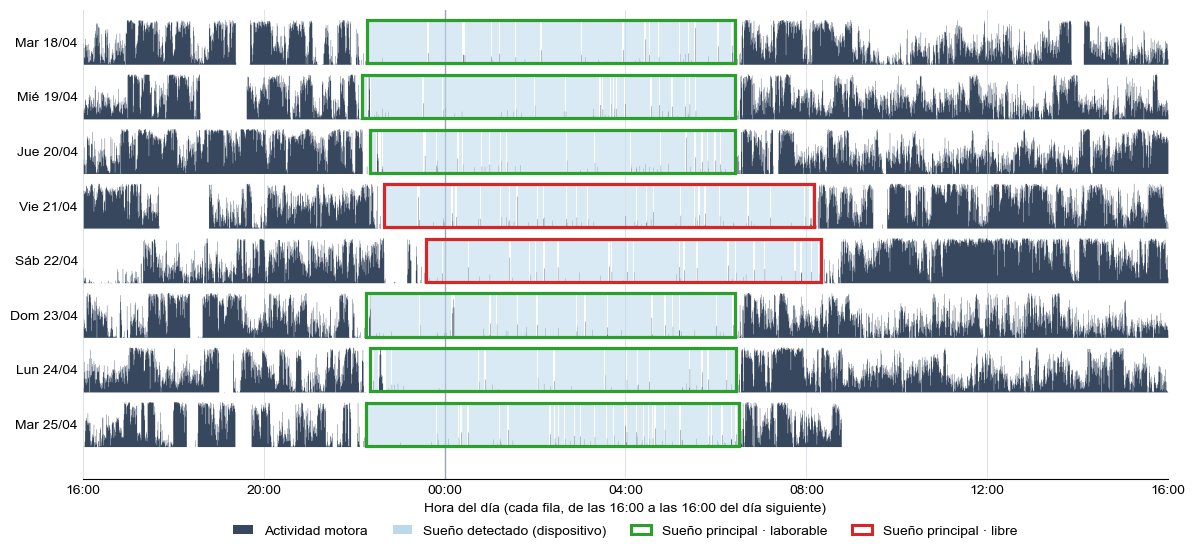

In [33]:

_DIAS_ES = {0: "Lun", 1: "Mar", 2: "Mié", 3: "Jue", 4: "Vie", 5: "Sáb", 6: "Dom"}


def actograma_sujeto(document, dias_libres=None, ventana=None,
                     mostrar_titulo=False, guardar=None):
    """Actograma de un sujeto, una fila por noche (16:00 -> 16:00) para que el
    sueño nocturno quede centrado y sin partir por la medianoche.

    Reutiliza `parsear_txt`, `detectar_episodios` y `calcular_noches`, así que el
    recuadro resalta exactamente el sueño principal que elige el cálculo del SJL
    (verde en días laborables, rojo en libres); su desplazamiento a horas más
    tardías en los libres es el jet lag social. `document` es el identificador
    del .txt y `dias_libres` el conjunto de fechas libres (por defecto el
    estándar del pipeline). Con `guardar=ruta` exporta la figura.
    """
    if dias_libres is None:
        dias_libres = dias_libres_estandar
    df = parsear_txt(RAW_MCA / f"{document}.txt", ventana=ventana)
    noches = calcular_noches(detectar_episodios(df), dias_libres)
    por_fecha = {r["fecha_noche"]: r for _, r in noches.iterrows()}

    def _norm(s):
        s = s.clip(lower=0).fillna(0)
        q = s.quantile(0.99)
        return (s / q).clip(0, 1) if q and q > 0 else s * 0
    act = _norm(df["t_mov"])
    marca2 = (df["marca"] == 2).fillna(False)

    A = ANCLA_NOCHE_H
    d0 = (df.index.min() - pd.Timedelta(hours=A)).normalize()
    dN = (df.index.max() - pd.Timedelta(hours=A)).normalize()
    filas = []
    for d in pd.date_range(d0, dN, freq="D"):
        w0 = d + pd.Timedelta(hours=A)
        if len(df.loc[w0:w0 + pd.Timedelta(hours=24)]) > 60:
            filas.append((d, w0))
    n = len(filas)
    row_h = 0.82

    # Arial local (rc_context) para no alterar el resto de figuras del notebook.
    with plt.rc_context({"font.family": "Arial", "pdf.fonttype": 42}):
        fig, ax = plt.subplots(figsize=(14, 0.55 * n + 1.7))
        for i, (d, w0) in enumerate(filas):
            y = n - 1 - i
            seg = df.loc[w0:w0 + pd.Timedelta(hours=24)]
            x = (seg.index - w0).total_seconds() / 3600.0
            # actividad motora (navy)
            ax.fill_between(x, y, y + row_h * act.loc[seg.index].values, step="mid",
                            color="#37475e", lw=0, zorder=2)
            # banda del sueño detectado por el dispositivo (marca == 2)
            ax.fill_between(x, y, y + row_h, where=marca2.loc[seg.index].values, step="mid",
                            color="#bcd9ec", alpha=0.55, lw=0, zorder=3)
            # recuadro del sueño principal de esa noche (reconstruye onset/offset
            # a partir de SO/SE y la fecha del despertar que da calcular_noches)
            r = por_fecha.get(d.date())
            if r is not None:
                fo = pd.Timestamp(r["fecha_offset"])
                off = fo + pd.Timedelta(hours=r["SE"])
                on = (fo if r["SO"] < A else fo - pd.Timedelta(days=1)) + pd.Timedelta(hours=r["SO"])
                x0 = (on - w0).total_seconds() / 3600.0
                x1 = (off - w0).total_seconds() / 3600.0
                col = "#d62728" if r["tipo_dia"] == "libre" else "#2ca02c"
                ax.add_patch(Rectangle((x0, y + 0.015), x1 - x0, row_h - 0.03,
                                       fill=False, edgecolor=col, lw=2.3, zorder=5))
        for hx in range(0, 25, 4):
            ax.axvline(hx, color="#d7dde6", lw=0.6, zorder=0)
        ax.axvline(8, color="#9aa6b8", lw=1.0, zorder=0)   # medianoche (16:00 + 8 h)
        ax.set_xlim(0, 24)
        ax.set_ylim(-0.6, n)
        ax.set_xticks(range(0, 25, 4))
        ax.set_xticklabels([f"{(A + h) % 24:02d}:00" for h in range(0, 25, 4)])
        ax.set_yticks([n - 1 - i + row_h / 2 for i in range(n)])
        ax.set_yticklabels([f"{_DIAS_ES[d.weekday()]} {d.strftime('%d/%m')}" for d, _ in filas])
        ax.set_xlabel("Hora del día (cada fila, de las 16:00 a las 16:00 del día siguiente)")
        ax.tick_params(length=0)
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)
        leg = [Patch(facecolor="#37475e", label="Actividad motora"),
               Patch(facecolor="#bcd9ec", label="Sueño detectado (dispositivo)"),
               Patch(facecolor="none", edgecolor="#2ca02c", lw=2.2, label="Sueño principal · laborable"),
               Patch(facecolor="none", edgecolor="#d62728", lw=2.2, label="Sueño principal · libre")]
        ax.legend(handles=leg, loc="upper center", bbox_to_anchor=(0.5, -0.07),
                  ncol=4, frameon=False, handlelength=1.4, columnspacing=1.8)
        if mostrar_titulo:
            ax.set_title(f"Actograma · document {document}", fontweight="bold")
        if guardar:
            fig.savefig(guardar, dpi=300, bbox_inches="tight")
        plt.show()


# Ejemplo: sujeto representativo
actograma_sujeto(200891)


#### Cálculo del SJL por sujeto

`calcular_sjl` orquesta el pipeline para un sujeto: invoca `detectar_episodios` y `calcular_noches`, comprueba los criterios de validez y devuelve un dict con:

- `MSW`, `MSF`, `MSF_sc` y las tres variantes del SJL (absoluta y con signo).
- **Variables resumen por tipo de día**: `SOW`/`SOF`/`SO` (hora media de inicio de sueño en laborables / libres / global), `SEW`/`SEF`/`SE` (hora media de fin de sueño) y `SDW`/`SDF`/`SD` (duración media). Estas variables se guardan en el CSV final junto al SJL y permiten describir directamente el patrón de sueño de la cohorte (p. ej. *"a qué hora se acostaban entre semana"*, *"cuánto dormían los días libres"*) sin tener que reprocesar el TXT más adelante. Se añade además `TST` (tiempo real de sueño): la suma de las épocas efectivamente dormidas del tramo principal, que `SD` no descuenta al medir el periodo de sueño completo.
- Recuentos auxiliares (noches conservadas por tipo, duración del registro, noches descartadas) y flags de validez.

**Criterios de validez por sujeto:**

- **≥ `MIN_NOCHES_POR_TIPO` noches laborables y libres** detectadas y conservadas tras descartar las de tramo principal corto. Garantiza que las medias se apoyan en al menos dos puntos reales del registro. Actúa como contrapartida, sobre las noches efectivamente detectadas (sin tramos demasiado cortos ni huecos largos), del criterio 3 de la sección 4 (`≥ 2 lab + ≥ 2 lib + ≥ 5 días naturales`), impuesto sobre la cohorte. Se comprueba dentro de `calcular_sjl`.
- **≥ `MIN_DIAS_VALIDOS` días naturales válidos**: un día se considera válido si tiene al menos `24 - MAX_OFF_DIA_H` h de registro útil (épocas ni en OFF ni ausentes), de modo que un día-frontera con pocas horas grabadas no cuenta. Este criterio por día se combina en el cierre con un tope al OFF global del registro: el de por día asegura suficientes días bien grabados (y evita que un único día malo invalide un registro por lo demás bueno) y el global acota el desgaste total. Para el cálculo del SJL apenas influye, porque solo intervienen los episodios de sueño nocturno (`marca == 2`); el motivo del filtro son las variables circadianas y no paramétricas del CRD (estabilidad interdiaria, variabilidad intradiaria, amplitud relativa, M10/L5, etc.), que se calculan por día sobre las 24 h y que un registro pobre vuelve poco fiables. Como esas variables se usan después en las correlaciones y en el aprendizaje automático, este filtro garantiza su validez.

De los dos criterios, el primero se comprueba dentro de `calcular_sjl`: si no se cumple, el sujeto se marca con `valido=False` y `motivo_excl` recoge la causa, que puede ser `sin_episodios` (no se detectó ningún tramo de sueño), `sin_noches_validas` (se detectaron tramos, pero todos cayeron fuera de la banda [3, 12] h) o `pocas_noches`. El criterio de días válidos, junto con las demás exclusiones metodológicas (SJL extremo, horario nocturno y edad), se aplica después, en el cierre del pipeline, al final de esta sección.


In [34]:
def calcular_sjl(df_raw, dias_libres=None, min_noches_por_tipo=None, ancla_h=None,
                 usar_cama=True):
    """Calcula MSW, MSF, las tres variantes del SJL y las variables resumen
    por tipo de día para un sujeto.

    Variables resumen añadidas al output (todas en horas decimales 0-24,
    salvo las duraciones que están en horas):

    - SOW / SOF / SO  : hora media de inicio de sueño (laborables / libres / global).
    - SEW / SEF / SE  : hora media de fin de sueño   (laborables / libres / global).
    - SDW / SDF / SD  : duración media del sueño     (laborables / libres / global).

    Devuelve siempre un dict con la misma estructura. Si el sujeto no cumple
    los criterios de validez, los campos del SJL y las variables resumen se devuelven como NaN y
    `valido=False` con `motivo_excl` indicando la causa.

    Por defecto (`usar_cama=True`) el sueño principal de cada noche se restringe
    al periodo en cama anotado; `usar_cama=False` usa el tramo más largo de la
    ventana sin esa restricción (alternativa de robustez, no usada en el cálculo principal).
    """
    if dias_libres is None:
        dias_libres = set()
    if min_noches_por_tipo is None:
        min_noches_por_tipo = MIN_NOCHES_POR_TIPO
    if ancla_h is None:
        ancla_h = ANCLA_NOCHE_H

    out = {
        "n_dias_registro": np.nan,
        "n_noches_lab": 0,
        "n_noches_libre": 0,
        "n_noches_descartadas": 0,
        # Variante 1 — principal, noche a noche
        "MSW": np.nan,
        "MSF": np.nan,
        "SJL": np.nan,
        "SJL_signed": np.nan,
        # Variante 2 — corrección por deuda de sueño
        "MSF_sc": np.nan,
        "SJL_sc": np.nan,
        "SJL_sc_signed": np.nan,
        # Variante 3 — Jankowski 2017
        "SJL_J": np.nan,
        "SJL_J_signed": np.nan,
        "SJL_J_caso": pd.NA,
        # Resumen por tipo de día (medias circulares de SO/SE y media aritmética de SD)
        "SOW": np.nan, "SOF": np.nan, "SO": np.nan,
        "SEW": np.nan, "SEF": np.nan, "SE": np.nan,
        "SDW": np.nan, "SDF": np.nan, "SD": np.nan,
        "TST": np.nan,
        # Flags de calidad
        "valido": False,
        "motivo_excl": None,
    }

    # Duración real del registro
    inicio, fin = df_raw.index.min(), df_raw.index.max()
    n_dias = (fin - inicio).total_seconds() / 86400
    out["n_dias_registro"] = n_dias

    # Detección de episodios y agregación por noche
    eps = detectar_episodios(df_raw)
    # Sueño principal anclado al periodo en cama anotado (marca 4 -> 8). Si una
    # noche no tiene anotación, calcular_noches cae al tramo más largo de la
    # ventana. usar_cama=False reproduce ese criterio simple.
    cama = _intervalos_cama(df_raw) if usar_cama else None
    noches = calcular_noches(eps, dias_libres, ancla_h=ancla_h,
                             intervalos_cama=cama)
    if noches.empty:
        # Distingue dos causas de noches vacías para que el desglose
        # de exclusiones sea informativo:
        # · `sin_episodios`     — no se detectó ningún tramo de sueño.
        # · `sin_noches_validas` — sí hubo tramos, pero todos cayeron
        #   fuera de [MIN_SD_NOCHE_H, MAX_SD_NOCHE_H] y se descartaron.
        out["motivo_excl"] = "sin_episodios" if eps.empty else "sin_noches_validas"
        return out

    # Estimación aproximada: días de calendario que cubre el registro menos
    # noches efectivamente conservadas. Da una idea de cuánta noche se ha
    # perdido por tramos fuera de [MIN_SD_NOCHE_H, MAX_SD_NOCHE_H], OFF largos
    # o ausencia de sueño.
    n_dias_calendario = int(np.ceil(n_dias))
    out["n_noches_descartadas"] = max(0, n_dias_calendario - len(noches))

    lab = noches[noches["tipo_dia"] == "laborable"]
    libre = noches[noches["tipo_dia"] == "libre"]
    out["n_noches_lab"] = len(lab)
    out["n_noches_libre"] = len(libre)

    # Comprobación: número mínimo de noches por tipo
    if len(lab) < min_noches_por_tipo or len(libre) < min_noches_por_tipo:
        out["motivo_excl"] = "pocas_noches"
        return out

    # Promedios por tipo de día.
    # SO, SE y MS: media circular sobre 24 h (cantidades circulares).
    # SD: media aritmética (es una duración, no cruza medianoche).
    so_lab, so_nolab = _media_circular(lab["SO"]), _media_circular(libre["SO"])
    se_lab, se_nolab = _media_circular(lab["SE"]), _media_circular(libre["SE"])
    sd_lab, sd_nolab = lab["SD"].mean(), libre["SD"].mean()

    # Resumen por tipo de día + global (todas las noches conservadas).
    out["SOW"] = so_lab; out["SOF"] = so_nolab
    out["SEW"] = se_lab; out["SEF"] = se_nolab
    out["SDW"] = sd_lab; out["SDF"] = sd_nolab
    out["SO"] = _media_circular(noches["SO"])
    out["SE"] = _media_circular(noches["SE"])
    out["SD"] = noches["SD"].mean()
    out["TST"] = noches["TST"].mean()

    # Variante 1 — principal, noche a noche
    # MS_i calculado por noche, promedios circulares a posteriori.
    msw = _media_circular(lab["MS"])
    msf = _media_circular(libre["MS"])
    out["MSW"] = msw
    out["MSF"] = msf
    # Versión absoluta (|MSF−MSW|, literatura clásica) y con signo (conserva
    # dirección: + retraso vespertino, − adelanto matutino).
    out["SJL"] = _diff_circular_abs(msf, msw)
    out["SJL_signed"] = _diff_circular_signed(msf, msw)

    # Variante 2 — corrección por deuda de sueño
    n_lab_n = len(lab)
    n_nolab_n = len(libre)
    sd_week = (n_lab_n * sd_lab + n_nolab_n * sd_nolab) / (n_lab_n + n_nolab_n)
    correccion = (sd_nolab - sd_week) / 2 if sd_nolab > sd_week else 0.0

    msf_sc = (msf - correccion) % 24
    out["MSF_sc"] = msf_sc
    out["SJL_sc"] = _diff_circular_abs(msf_sc, msw)
    out["SJL_sc_signed"] = _diff_circular_signed(msf_sc, msw)

    # Variante 3 — Jankowski 2017 (SJL_J)
    # ¿El inicio/fin del sueño libre va igual o más tarde que el laboral?
    # _diff_circular_signed(libre, lab) es >= 0 cuando el libre está por
    # delante (a la misma hora o más tarde), a prueba del cruce de medianoche.
    so_libre_posterior_o_igual = _diff_circular_signed(so_nolab, so_lab) >= 0
    se_libre_posterior_o_igual = _diff_circular_signed(se_nolab, se_lab) >= 0

    if sd_nolab > sd_lab and so_libre_posterior_o_igual:
        # Caso onset: más sueño libre y onset libre más tardío.
        # El sueño extra se acumula al final del episodio; el onset libre
        # no está distorsionado por la recuperación y actúa como ancla.
        out["SJL_J"] = _diff_circular_abs(so_nolab, so_lab)
        out["SJL_J_signed"] = _diff_circular_signed(so_nolab, so_lab)
        out["SJL_J_caso"] = "onset"
    elif sd_lab > sd_nolab and se_libre_posterior_o_igual:
        # Caso offset: más sueño laborable y offset libre más tardío.
        # El sueño extra está en laborables; el offset libre actúa como ancla.
        out["SJL_J"] = _diff_circular_abs(se_nolab, se_lab)
        out["SJL_J_signed"] = _diff_circular_signed(se_nolab, se_lab)
        out["SJL_J_caso"] = "offset"
    else:
        # Caso atípico: ambos extremos modificados a la vez, o duraciones
        # iguales. Jankowski recomienda usar la fórmula convencional.
        out["SJL_J"] = _diff_circular_abs(msf, msw)
        out["SJL_J_signed"] = _diff_circular_signed(msf, msw)
        out["SJL_J_caso"] = "atipico"

    out["valido"] = True
    return out

### Aplicación a la cohorte

`calcular_sjl` se ejecuta sobre cada uno de los `.txt` de la cohorte, recortados a la ventana CRD del sujeto vía el argumento `ventana=` de `parsear_txt` definido en la sección 6. El resultado es un DataFrame `df_sjl` con una fila por sujeto y todas las variantes del SJL, sus flags de calidad, los recuentos auxiliares (noches conservadas por tipo, duración del registro, motivo de exclusión) y las variables resumen por tipo de día (hora media de inicio y de fin de sueño, duración media). Sobre él se calcula el flag `sjl_outlier = SJL > 6 h`; su justificación, junto con la del criterio de horario nocturno, se desarrolla en el apartado «Exclusiones por inaplicabilidad del método: trabajo a turnos», más arriba en esta sección, y ambos se aplican en el cierre del pipeline.

#### Paralelización y checkpoints

La estrategia es distinta en comparación con la aplicada para la descarga masiva de la sección 5. A diferencia de la descarga, aquí el ordenador no espera red: para cada sujeto hay que leer su TXT, parsearlo, detectar episodios de sueño y calcular varias medias circulares. Los hilos usados en la descarga no sirven aquí porque Python solo puede ejecutar código de cálculo en un hilo a la vez, por una limitación interna del lenguaje. La solución es lanzar procesos completos e independientes — uno por núcleo — que corran en verdadero paralelo sin interferirse entre sí.

Para ello se usa `joblib.Parallel` con su variante `loky`, una librería pensada justo para este tipo de trabajo. Una de sus ventajas frente a otras opciones de Python es que puede empaquetar y mandar a los procesos hijos las funciones definidas en el propio notebook (como `parsear_txt` o `calcular_sjl`), algo que con el módulo estándar de Python no funciona en Windows. Se usan 12 de los 16 núcleos del equipo (`N_WORKERS_SJL`), dejando 4 libres para que el sistema operativo y el resto de programas no se queden sin recursos mientras corre el cálculo.

El progreso se guarda cada 50 sujetos en `data/processed/sjl_checkpoint.csv`. Los resultados se reciben conforme cada proceso termina, lo que permite ir guardando ese fichero de forma incremental. Si la celda se interrumpe por cualquier motivo, al relanzarla detecta automáticamente el checkpoint, identifica los sujetos que ya tienen resultado y solo procesa los que faltan. Al cargarlo, el checkpoint se poda a los `document` de la cohorte actual, de modo que si la cohorte cambia de composición entre ejecuciones no arrastra resultados de sujetos que ya no le pertenecen. Igual que con los TXTs de la descarga, el fichero se guarda en dos pasos para que nunca quede un checkpoint a medias.


In [35]:
# Parámetros del pipeline paralelo
# 12 de 16 núcleos: deja 4 libres para SO y otros programas.
N_WORKERS_SJL = min(12, max(1, (os.cpu_count() or 4) - 4))

# Checkpoint incremental: si la celda se interrumpe, al relanzar continúa
# desde donde se quedó.
CHECKPOINT_SJL = PROCESSED / "sjl_checkpoint.csv"
CHECKPOINT_EVERY = 50


def _procesar_sujeto(doc_id, raw_dir, dias_libres, ventana_crd=None):
    """Parsea el TXT de un sujeto (recortado a la ventana declarada por el
    CRD si se pasa) y calcula sus variantes de SJL. Si algo falla (TXT
    corrupto, formato inesperado...), devuelve el error como un campo del
    resultado en lugar de detener todo el cálculo.
    """
    fp = Path(raw_dir) / f"{doc_id}.txt"
    try:
        df_raw = parsear_txt(fp, ventana=ventana_crd)
        res = calcular_sjl(df_raw, dias_libres=dias_libres)
        res["document"] = doc_id
        # Calidad del registro: % global de OFF (informativo) y nº de días naturales
        # válidos. Un día es válido si tiene al menos 24 - MAX_OFF_DIA_H horas de
        # registro útil ese día (epocás ni en OFF ni ausentes); así un día-frontera
        # con pocas horas grabadas no cuenta como válido. El cierre excluye por días.
        if len(df_raw):
            es_off = df_raw["marca"] == 64
            horas_validas_dia = (
                (~es_off).groupby(df_raw.index.normalize()).sum()
                * INTERVALO_S / 3600
            )
            res["pct_off"] = float(es_off.mean() * 100)
            res["n_dias_validos"] = int((horas_validas_dia >= 24 - MAX_OFF_DIA_H).sum())
        else:
            res["pct_off"] = float("nan")
            res["n_dias_validos"] = 0
        res["_error"] = None
        return res
    except Exception as e:
        return {"document": doc_id,
                "_error": f"{type(e).__name__}: {str(e)[:120]}"}


def _guardar_checkpoint(resultados, ruta):
    """Guarda los resultados en el fichero de checkpoint.
    Guarda primero en un temporal y luego renombra, para que el fichero
    nunca quede a medias si el proceso muere durante el guardado."""
    tmp = ruta.with_suffix(ruta.suffix + ".tmp")
    pd.DataFrame(resultados).to_csv(tmp, index=False)
    # En Windows no se puede renombrar un fichero sobre otro que algún programa
    # tenga abierto en ese momento: OneDrive sincronizando la carpeta o Excel con
    # el CSV abierto para mirar el progreso, y replace() falla con PermissionError.
    # Se reintenta hasta 10 veces esperando un poco más cada vez (0,5 s, 1 s, 1,5 s...).
    ultimo_err = None
    for intento in range(10):
        try:
            tmp.replace(ruta)
            return
        except PermissionError as e:
            ultimo_err = e
            time.sleep(0.5 * (intento + 1))
    print(f"[checkpoint] No se pudo reemplazar {ruta.name} tras varios intentos: "
          f"{ultimo_err}. Se conserva {tmp.name} como respaldo.")


In [36]:
# Ejecución del pipeline paralelo.
# Carga el checkpoint si existe (podándolo a la cohorte actual) y procesa solo
# los sujetos pendientes. Guarda el progreso cada CHECKPOINT_EVERY sujetos.

# Documentos de la cohorte actual: universo de referencia de todo el pipeline y
# criterio para podar el checkpoint.
docs_cohorte = set(df_cohorte["document"].astype(int))

if CHECKPOINT_SJL.exists():
    df_ckpt = pd.read_csv(CHECKPOINT_SJL)
    df_ckpt["document"] = df_ckpt["document"].astype(int)
    n_ckpt_bruto = len(df_ckpt)
    df_ckpt = df_ckpt[df_ckpt["document"].isin(docs_cohorte)]
    n_podados = n_ckpt_bruto - len(df_ckpt)
    resultados = df_ckpt.to_dict("records")
    procesados = set(df_ckpt["document"].tolist())
    if n_podados:
        # Reescribe el checkpoint ya podado para que el fichero en disco deje de
        # arrastrar los sujetos fantasma en próximas ejecuciones.
        _guardar_checkpoint(resultados, CHECKPOINT_SJL)
        print(f"Checkpoint: {n_podados} sujetos de cohortes anteriores descartados.")
    print(f"Checkpoint encontrado: {len(procesados)} sujetos ya procesados.")
else:
    resultados = []
    procesados = set()

# Tabla de búsqueda document → (inicio, fin) que declara el CRD. Se pasa a cada
# worker para que `parsear_txt` recorte el TXT a esa ventana antes del cálculo.
ventana_por_doc = {
    int(r["document"]): (r["inicio"], r["fin"])
    for _, r in df_cohorte[["document", "inicio", "fin"]].iterrows()
}

todos = df_cohorte["document"].astype(int).tolist()
pendientes = [d for d in todos if d not in procesados]
total = len(todos)

print(f"Total cohorte: {total}  |  pendientes: {len(pendientes)}  "
      f"|  workers: {N_WORKERS_SJL}")

if pendientes:
    t0 = time.time()
    n_desde_ckpt = 0

    parallel = Parallel(
        n_jobs=N_WORKERS_SJL,
        backend="loky",
        return_as="generator_unordered",
    )
    tareas = (delayed(_procesar_sujeto)(d, str(RAW_MCA), dias_libres_estandar,
                                        ventana_por_doc.get(d))
              for d in pendientes)

    try:
        for i, res in enumerate(parallel(tareas), 1):
            resultados.append(res)
            n_desde_ckpt += 1

            if n_desde_ckpt >= CHECKPOINT_EVERY or i == len(pendientes):
                _guardar_checkpoint(resultados, CHECKPOINT_SJL)
                n_desde_ckpt = 0
                elapsed = time.time() - t0
                rate = i / elapsed if elapsed > 0 else 0
                t_rest = (len(pendientes) - i) / rate if rate > 0 else 0
                n_err = sum(1 for r in resultados if isinstance(r.get("_error"), str))
                n_val = sum(1 for r in resultados if r.get("valido"))
                n_noval = len(resultados) - n_val - n_err
                print(f"  {len(resultados):5}/{total}  "
                      f"({rate:5.1f} suj/s, restante: {t_rest/60:5.1f} min, "
                      f"válidos: {n_val}, no válidos: {n_noval}, errores: {n_err})")
    except KeyboardInterrupt:
        # El usuario ha parado la celda. Se guarda lo calculado hasta ahora y la
        # próxima ejecución continuará desde aquí.
        _guardar_checkpoint(resultados, CHECKPOINT_SJL)
        print("\nInterrumpido por el usuario. Checkpoint guardado; "
              "ejecuta de nuevo la celda para reanudar.")
        raise

# Separar los errores de proceso del resto.
df_full = pd.DataFrame(resultados)
mask_err = df_full["_error"].notna() if "_error" in df_full.columns else pd.Series(False, index=df_full.index)
errores_proc = list(zip(df_full.loc[mask_err, "document"].tolist(),
                        df_full.loc[mask_err, "_error"].tolist()))
df_sjl = df_full.loc[~mask_err].drop(columns=[c for c in ["_error"] if c in df_full.columns]).reset_index(drop=True)

# Marca (sin excluir todavía) los SJL atípicos; el cierre los excluye en orden.
df_sjl["sjl_outlier"] = df_sjl["valido"].astype(bool) & (df_sjl["SJL"] > SJL_OUTLIER_H)

# Resumen del cálculo en un único universo (los sujetos sin error de parseo):
# procesados = válidos del cálculo + sin noches suficientes.
n_val_77 = int(df_sjl["valido"].sum())
print(f"\nPipeline completado: {len(df_sjl)} procesados sin error  "
      f"({n_val_77} válidos, {len(df_sjl) - n_val_77} sin noches suficientes)  |  "
      f"{len(errores_proc)} con error de parseo")


Checkpoint encontrado: 3686 sujetos ya procesados.
Total cohorte: 3686  |  pendientes: 0  |  workers: 12

Pipeline completado: 3686 procesados sin error  (3431 válidos, 255 sin noches suficientes)  |  0 con error de parseo


### Cierre del pipeline: muestra analítica final

Se cierra el pipeline del SJL: sobre el resultado del cálculo, ya cruzado con la cohorte por `document`, se aplican las exclusiones metodológicas y se persiste la muestra analítica final. Las exclusiones, en orden:

1. **Calidad del registro** — dos criterios complementarios: (a) menos de `MIN_DIAS_VALIDOS` días naturales válidos, donde un día es válido si tiene al menos `24 - MAX_OFF_DIA_H` h de registro útil (épocas ni en OFF ni ausentes), lo que asegura suficientes días bien registrados sin que cuenten los días-frontera grabados a medias; y (b) OFF global del registro por encima de `OFF_GLOBAL_MAX_PCT` %. El de por día evita descartar un registro bueno por un único día flojo; el global acota el desgaste total. 
2. **Valor atípico** — SJL > 6 h: el SJL es una diferencia angular bien definida hasta su máximo de 12 h, pero en esta cohorte la distribución rara vez supera las 4 h, así que un valor por encima de 6 h queda muy alejado del grueso y se trata como atípico. Suele corresponder a un horario irregular o a trabajo a turnos, fuera del jet lag social ordinario que se quiere caracterizar (un trabajador a turnos podría superar ese valor legítimamente).
3. **Horario nocturno** — MSW > 12 h: indicador indirecto de trabajo a turnos de noche (misma justificación que la anterior).
4. **Edad** — menores de 13 años: la cohorte no alcanza la n necesaria para describir patrones poblacionales en ese rango.

Cada criterio actúa solo sobre los sujetos aún válidos, de modo que cada excluido queda con un único `motivo_excl` (gana el criterio prioritario). El resultado se persiste en dos CSVs:

- **`df_cohorte_con_sjl.csv`** — cohorte analítica final: solo los sujetos válidos y sin las columnas diagnósticas (`valido`, `motivo_excl`, `sjl_outlier`), que tras el filtrado serían constantes. Es el fichero que consumen todos los análisis posteriores.
- **`df_cohorte_excluidos.csv`** — registro de auditoría con los sujetos excluidos y su `motivo_excl`.


In [37]:
# Cierre del pipeline: cruce con la cohorte, exclusiones metodológicas y
# persistencia de los dos CSVs finales.

# Merge con la cohorte. how="left" sobre df_cohorte fija como base la cohorte con
# actigrafía: cada sujeto recibe sus variables de SJL.
df_cohorte_sjl = df_cohorte.merge(df_sjl, on="document", how="left")

# Parámetros de las exclusiones: umbrales que el cierre aplica sobre las
# columnas ya calculadas (n_dias_validos, pct_off, MSW, edad).
MIN_DIAS_VALIDOS = 5
OFF_GLOBAL_MAX_PCT = 15
MSW_NOCTURNO_H = 12
EDAD_MIN_ANALISIS = 13


def aplicar_exclusion(condicion, motivo):
    """Excluye a los sujetos que cumplen `condicion` y que seguían siendo válidos:
    los marca con valido=False, anota el `motivo` y devuelve cuántos excluye.

    El factor `& valido` lee el estado actual de la columna, de modo que cada
    criterio actúa solo sobre quien ningún criterio anterior haya excluido ya, y
    nunca se sobrescribe el primer motivo.
    """
    mask = condicion & df_cohorte_sjl["valido"].fillna(False).astype(bool)
    n = int(mask.sum())
    df_cohorte_sjl.loc[mask, "valido"] = False
    df_cohorte_sjl.loc[mask, "motivo_excl"] = motivo
    return n


# Las exclusiones metodológicas (en orden de prioridad)
n_reg = aplicar_exclusion(
    df_cohorte_sjl["n_dias_validos"].fillna(0) < MIN_DIAS_VALIDOS,
    f"registro_insuficiente (<{MIN_DIAS_VALIDOS} días válidos)")
n_off = aplicar_exclusion(
    df_cohorte_sjl["pct_off"].fillna(0) > OFF_GLOBAL_MAX_PCT,
    f"off_excesivo (>{OFF_GLOBAL_MAX_PCT}% del registro)")
n_out = aplicar_exclusion(
    df_cohorte_sjl["sjl_outlier"].fillna(False).astype(bool),
    f"sjl_outlier (>{SJL_OUTLIER_H:.0f}h)")
n_noct = aplicar_exclusion(
    df_cohorte_sjl["MSW"].notna() & (df_cohorte_sjl["MSW"] > MSW_NOCTURNO_H),
    f"horario_nocturno (MSW > {MSW_NOCTURNO_H} h)")
n_edad = aplicar_exclusion(
    df_cohorte_sjl["edad_estudio_int"].fillna(-1) < EDAD_MIN_ANALISIS,
    f"edad < {EDAD_MIN_ANALISIS} años")

# Recuento de la selección sobre la cohorte con actigrafía
MOTIVOS_CALCULO = ["sin_episodios", "sin_noches_validas", "pocas_noches"]
docs_con_resultado = set(df_sjl["document"])
docs_error = {d for d, _ in errores_proc}

n_cohorte = len(df_cohorte_sjl)
n_err = int(df_cohorte_sjl["document"].isin(docs_error).sum())
n_proc = int(df_cohorte_sjl["document"].isin(docs_con_resultado).sum())
# "sin procesar" = sujetos de la cohorte sin resultado de SJL y sin error; suele ser 0.
n_sin_proc = n_cohorte - n_proc - n_err
# "sin noches suficientes" = procesados que no pasaron el cálculo del SJL
n_sin_noches = int(df_cohorte_sjl["motivo_excl"].isin(MOTIVOS_CALCULO).sum())
n_val_calc = n_proc - n_sin_noches

mask_validos = df_cohorte_sjl["valido"].fillna(False).astype(bool)
n_final = int(mask_validos.sum())
n_excl_total = n_cohorte - n_final

COL = 42


def _fila(etiqueta, n, ind=4):
    s = " " * ind + etiqueta
    print(f"{s:<{COL}}{n:>6}")


print("Recuento de la selección sobre la cohorte con actigrafía")
_fila("Cohorte con actigrafía:", n_cohorte, ind=2)
_fila("errores de parseo:", n_err)
_fila("sin procesar:", n_sin_proc)
_fila("procesados:", n_proc)
print("  Procesados → cálculo del SJL:")
_fila("válidos:", n_val_calc)
_fila("sin noches suficientes:", n_sin_noches)
# Desglose por motivo del cálculo, para que cuadre con la tabla de exclusiones.
for _m in MOTIVOS_CALCULO:
    _n_m = int((df_cohorte_sjl["motivo_excl"] == _m).sum())
    if _n_m:
        _fila(f"{_m}:", _n_m, ind=6)
print("  Válidos → exclusiones metodológicas:")
_fila(f"registro < {MIN_DIAS_VALIDOS} días válidos:", n_reg)
_fila(f"OFF global > {OFF_GLOBAL_MAX_PCT}%:", n_off)
_fila(f"SJL > {SJL_OUTLIER_H:.0f} h:", n_out)
_fila(f"MSW > {MSW_NOCTURNO_H} h:", n_noct)
_fila(f"edad < {EDAD_MIN_ANALISIS} años:", n_edad)
print(f"{'  Cohorte analítica final:':<{COL}}{n_final:>6}  ({100*n_final/n_cohorte:.1f} %)")

if n_sin_proc:
    print(f"\nAviso: {n_sin_proc} sujetos de la cohorte no tienen resultado de SJL "
          f"(añadidos tras el último cálculo). Re-ejecuta la celda del pipeline "
          f"para procesarlos antes de dar por buena la muestra.")
if n_err:
    print(f"\nDetalle de los errores de parseo ({n_err}):")
    for doc, err in errores_proc[:3]:
        print(f"    {doc}: {err}")

# Desglose completo de excluidos por motivo
if n_excl_total:
    motivos = df_cohorte_sjl.loc[~mask_validos, "motivo_excl"].fillna("desconocido")
    desglose_excl = (motivos.value_counts()
                     .rename_axis("motivo_excl")
                     .to_frame("sujetos"))
    desglose_excl["% cohorte"] = (100 * desglose_excl["sujetos"] / n_cohorte).round(1)
    print(f"\nDesglose de exclusiones ({n_excl_total} sujetos):")
    display(desglose_excl)

# Persistencia en dos ficheros
df_cohorte_excluidos = (
    df_cohorte_sjl[~mask_validos]
    .drop(columns=["valido", "sjl_outlier"], errors="ignore")
    .reset_index(drop=True)
)

df_cohorte_sjl = (
    df_cohorte_sjl[mask_validos]
    .drop(columns=["valido", "motivo_excl", "sjl_outlier"], errors="ignore")
    .reset_index(drop=True)
)

path_main = PROCESSED / "df_cohorte_con_sjl.csv"
path_excl = PROCESSED / "df_cohorte_excluidos.csv"
df_cohorte_sjl.to_csv(path_main, index=False, encoding="utf-8-sig")
df_cohorte_excluidos.to_csv(path_excl, index=False, encoding="utf-8-sig")
print(f"\nGuardado: {path_main}  ({len(df_cohorte_sjl)} sujetos)")
print(f"Guardado: {path_excl}  ({len(df_cohorte_excluidos)} sujetos)")


Recuento de la selección sobre la cohorte con actigrafía
  Cohorte con actigrafía:                   3686
    errores de parseo:                         0
    sin procesar:                              0
    procesados:                             3686
  Procesados → cálculo del SJL:
    válidos:                                3431
    sin noches suficientes:                  255
      sin_episodios:                           1
      pocas_noches:                          254
  Válidos → exclusiones metodológicas:
    registro < 5 días válidos:               129
    OFF global > 15%:                         66
    SJL > 6 h:                                12
    MSW > 12 h:                               11
    edad < 13 años:                           23
  Cohorte analítica final:                  3190  (86.5 %)

Desglose de exclusiones (496 sujetos):


,sujetos,% cohorte
motivo_excl,,
pocas_noches,254,6.9000
registro_insuficiente (<5 días válidos),129,3.5000
off_excesivo (>15% del registro),66,1.8000
edad < 13 años,23,0.6000
sjl_outlier (>6h),12,0.3000
horario_nocturno (MSW > 12 h),11,0.3000
sin_episodios,1,0.0000



Guardado: data\processed\df_cohorte_con_sjl.csv  (3190 sujetos)
Guardado: data\processed\df_cohorte_excluidos.csv  (496 sujetos)


Del cierre se obtienen dos vistas de la cohorte analítica para los análisis posteriores:

- `val`: la cohorte completa, sanos y pacientes, ya con todos los filtros del pipeline aplicados.
- `val_sanos`: solo los sujetos sin patología (`es_sano`), base de los descriptivos por edad, sexo y cronotipo, donde mezclar patologías sesgaría la lectura.

In [38]:
val = df_cohorte_sjl
val_sanos = val[val["es_sano"]].copy()

n_val, n_sanos = len(val), len(val_sanos)
print(f"Cohorte analítica (val):    {n_val}")
print(f"  · sanos (val_sanos):      {n_sanos}  ({100*n_sanos/n_val:.1f}% de val)")
print(f"  · pacientes:              {n_val - n_sanos}  ({100*(n_val - n_sanos)/n_val:.1f}% de val)")

Cohorte analítica (val):    3190
  · sanos (val_sanos):      2693  (84.4% de val)
  · pacientes:              497  (15.6% de val)


---

# Material suplementario

Esta sección reúne análisis complementarios que respaldan algunas decisiones metodológicas del notebook pero que no forman parte del pipeline de cálculo en sí. Se organiza en dos bloques: el primero comprueba la robustez del SJL frente a la definición del calendario de días libres; el segundo documenta una vía de limpieza de los TXT que se exploró pero no se incorporó al análisis final.

### Configuración común de las figuras

Paleta de colores, etiquetas de las variantes del SJL, bins de edad y estilo de matplotlib (`rcParams`) que reutilizan todas las figuras del material suplementario. Se agrupan aquí para mantener una estética homogénea en las figuras de la sección de sensibilidad.

In [39]:
# Etiquetas y paleta consistentes para las figuras del material suplementario
VAR_ABS = ["SJL", "SJL_sc", "SJL_J"]
VAR_SIG = ["SJL_signed", "SJL_sc_signed", "SJL_J_signed"]
VAR_LABEL = {
    "SJL": "SJL  (Roenneberg)",
    "SJL_sc": "SJL_sc  (corr. deuda)",
    "SJL_J": "SJL_J  (Jankowski)",
    "SJL_signed": "SJL  (signo)",
    "SJL_sc_signed": "SJL_sc  (signo)",
    "SJL_J_signed": "SJL_J  (signo)",
}
COLOR = {"SJL": "#2c3e85", "SJL_sc": "#1f8a70", "SJL_J": "#c46f1f"}
COLOR_ACCENT = "#b03a2e"  # mediana, anotaciones
COLOR_REF = "#555555"     # diagonal, líneas guía
HEADER = "#1a2940"        # tipografía cabeceras de tablas

# Grupos de edad.
# El bin <13 se omite porque el filtro etario ya está aplicado en el CSV.
EDAD_BINS = [13, 18, 25, 41, 51, 65, 200]
EDAD_LABELS = ["13-17", "18-24", "25-40", "41-50", "51-64", "≥65"]
CRONO_COL = "crono_tipo_etiqueta_cronotipo_label"

# Estética común de matplotlib
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": HEADER,
    "axes.labelsize": 10,
    "axes.labelcolor": HEADER,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "legend.frameon": False,
    "font.family": "DejaVu Sans",
})

<a id="sensibilidad-calendario"></a>

## S1 · Sensibilidad del SJL al calendario de días libres

Un análisis de sensibilidad comprueba si una conclusión se mantiene cuando una decisión metodológica, aquí qué días se consideran "libres", se toma de otra forma razonable. Se mantiene fija la cohorte analítica y se recalcula el SJL de los mismos sujetos cambiando solo el calendario de etiquetado, de modo que cualquier diferencia es atribuible al calendario y no a la composición de la muestra (comparación pareada, cada sujeto consigo mismo).

Se comparan tres definiciones de día libre:

| Calendario | Sábado | Festivos regionales/locales |
|---|---|---|
| estándar (por defecto) | libre | excluidos |
| amplio | libre | incluidos como libres |
| estricto | laborable | excluidos |

Se muestra la mediana del SJL bajo cada calendario (panorama) y la concordancia pareada entre el estándar y el amplio.

In [40]:
# Recálculo del SJL bajo los tres calendarios sobre toda la cohorte analítica
# `val`, manteniéndola fija. Solo cambia el conjunto de días libres con que se
# etiqueta cada noche; el resto del pipeline es idéntico al de la sección 7.
#
# Para el panorama general se relaja el mínimo de noches por tipo a 1
# (MIN_NOCHES_PANORAMA): así el estricto produce un SJL también para los sujetos
# con una sola noche fija, que de otro modo quedarían indefinidos.

MIN_NOCHES_PANORAMA = 1
CALENDARIOS_SENS = {
    "estandar": dias_libres_estandar,
    "amplio": dias_libres_amplio,
    "estricto": dias_libres_estricto,
}
CHECKPOINT_SENS = PROCESSED / "sjl_sensibilidad_checkpoint.csv"


def _procesar_sujeto_sens(doc_id, raw_dir, calendarios, ventana_crd=None,
                          min_noches=MIN_NOCHES_PANORAMA):
    """Parsea el TXT de un sujeto una sola vez y calcula el SJL bajo cada
    calendario con el mínimo de noches relajado. Devuelve un dict, o el error
    como campo si el TXT falla, sin detener el resto del cálculo."""
    fp = Path(raw_dir) / f"{doc_id}.txt"
    try:
        df_raw = parsear_txt(fp, ventana=ventana_crd)
        out = {"document": doc_id, "_error": None}

        for nombre, cal in calendarios.items():
            res = calcular_sjl(df_raw, dias_libres=cal, min_noches_por_tipo=min_noches)
            out[f"SJL_{nombre}"] = res["SJL"]
            out[f"MSW_{nombre}"] = res["MSW"]
            out[f"MSF_{nombre}"] = res["MSF"]
            out[f"nlibre_{nombre}"] = res["n_noches_libre"]
            out[f"nlab_{nombre}"] = res["n_noches_lab"]
            out[f"valido_{nombre}"] = res["valido"]

        return out
    except Exception as e:
        return {"document": doc_id, "_error": f"{type(e).__name__}: {str(e)[:120]}"}


val["document"] = val["document"].astype(int)
docs_sens = val["document"].tolist()
ventana_sens = {
    int(r["document"]): (pd.to_datetime(r["inicio"]), pd.to_datetime(r["fin"]))
    for _, r in val[["document", "inicio", "fin"]].iterrows()
}

if CHECKPOINT_SENS.exists():
    df_sens = pd.read_csv(CHECKPOINT_SENS)
    df_sens["document"] = df_sens["document"].astype(int)
    res_sens = df_sens.to_dict("records")
    hechos = set(df_sens["document"])
else:
    res_sens = []
    hechos = set()

pendientes_sens = [d for d in docs_sens if d not in hechos]
print(f"Sensibilidad — cohorte completa: {len(docs_sens)}  |  "
      f"pendientes: {len(pendientes_sens)}  |  workers: {N_WORKERS_SJL}")

if pendientes_sens:
    parallel = Parallel(n_jobs=N_WORKERS_SJL, backend="loky",
                        return_as="generator_unordered")
    tareas = (delayed(_procesar_sujeto_sens)(d, str(RAW_MCA), CALENDARIOS_SENS,
                                             ventana_sens.get(d))
              for d in pendientes_sens)
    n_desde_ckpt = 0
    for i, r in enumerate(parallel(tareas), 1):
        res_sens.append(r)
        n_desde_ckpt += 1
        if n_desde_ckpt >= CHECKPOINT_EVERY or i == len(pendientes_sens):
            _guardar_checkpoint(res_sens, CHECKPOINT_SENS)
            n_desde_ckpt = 0
            print(f"  {len(res_sens)}/{len(docs_sens)} recalculados")

df_sens = pd.DataFrame(res_sens)
n_err = int(df_sens["_error"].notna().sum()) if "_error" in df_sens.columns else 0
print(f"Recálculo terminado: {len(df_sens)} sujetos  ({n_err} con error de proceso)")

Sensibilidad — cohorte completa: 3190  |  pendientes: 0  |  workers: 12
Recálculo terminado: 3190 sujetos  (0 con error de proceso)


In [41]:
# Ensamblaje sobre la cohorte analítica `val`. Referencia estándar: la columna
# `SJL` del pipeline. El pase de sensibilidad la recalcula; la desviación máxima
# verifica que ambos cómputos coinciden. Funciones auxiliares reutilizadas en las celdas
# siguientes.

def _to_bool(s):
    """Coacciona a booleano una serie de banderas `valido_*`, que según venga
    de los registros en memoria o reconstruida desde el checkpoint CSV puede
    ser ya booleana o texto ('True'/'False'); los NaN pasan a False."""
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().isin(["true", "1", "1.0"])


mm = val[["document", "SJL", "sexo"]].copy()
mm["document"] = mm["document"].astype(int)
mm = mm.merge(df_sens.drop(columns=[c for c in ["_error"] if c in df_sens.columns]),
              on="document", how="left")

desv = (mm["SJL_estandar"] - mm["SJL"]).abs().max()
print(f"Verificación recálculo estándar vs pipeline: desviación máx = {desv:.1e} h "
      f"({'OK' if pd.isna(desv) or desv < 1e-6 else 'REVISAR'})\n")

v_est = _to_bool(mm["valido_estandar"])
v_amp = _to_bool(mm["valido_amplio"])
v_str = _to_bool(mm["valido_estricto"])


def _resumen_sjl(s):
    """Mediana, IQR y media de una serie de SJL (ignora NaN)."""
    s = s.dropna()
    return {"n": len(s), "Mediana (h)": round(s.median(), 3),
            "IQR (h)": f"[{s.quantile(.25):.2f}, {s.quantile(.75):.2f}]",
            "Media (h)": round(s.mean(), 3)}


def _comparar(ref, alt, mask=None):
    """Concordancia pareada entre dos series de SJL (mismo sujeto): desplazamiento
    de mediana, sesgo medio, límites de acuerdo, correlación y % que cambian."""
    d = pd.concat([ref.rename("ref"), alt.rename("alt")], axis=1)
    if mask is not None:
        d = d[mask]
    d = d.dropna()
    dif = d["alt"] - d["ref"]
    return {"n": len(d),
            "Δ mediana (min)": round((d["alt"].median() - d["ref"].median()) * 60, 1),
            "sesgo (min)": round(dif.mean() * 60, 1),
            "|dif| med (min)": round(dif.abs().median() * 60, 1),
            "LoA 95% (h)": f"[{dif.mean()-1.96*dif.std():+.2f}, {dif.mean()+1.96*dif.std():+.2f}]",
            "r": round(d["ref"].corr(d["alt"]), 3),
            "% cambian": round(100 * (dif.abs() > 0.01).mean(), 1)}


# Panorama: mediana del SJL por calendario sobre la cohorte. estándar y amplio en
# todos; estricto donde hay >=1 noche fija (mínimo relajado) como vista de
# cobertura amplia, de menor fiabilidad individual.
panorama = pd.DataFrame({
    "estándar (cohorte)": _resumen_sjl(mm.loc[v_est, "SJL_estandar"]),
    "amplio (cohorte)": _resumen_sjl(mm.loc[v_amp, "SJL_amplio"]),
    "estricto (≥1 noche fija)": _resumen_sjl(mm.loc[v_str, "SJL_estricto"]),
}).T
print("PANORAMA — mediana del SJL por calendario:")
print(panorama.to_string())

print("\nResidencia — estándar vs amplio (cohorte completa):")
print(pd.Series(_comparar(mm["SJL_estandar"], mm["SJL_amplio"], v_amp)).to_string())

Verificación recálculo estándar vs pipeline: desviación máx = 0.0e+00 h (OK)

PANORAMA — mediana del SJL por calendario:
                             n Mediana (h)       IQR (h) Media (h)
estándar (cohorte)        3190      0.8630  [0.39, 1.50]    1.0810
amplio (cohorte)          3190      0.8530  [0.38, 1.49]    1.0680
estricto (≥1 noche fija)  3189      0.8360  [0.37, 1.55]    1.1120

Residencia — estándar vs amplio (cohorte completa):
n                            3190
Δ mediana (min)           -0.6000
sesgo (min)               -0.8000
|dif| med (min)            0.0000
LoA 95% (h)        [-0.35, +0.32]
r                          0.9830
% cambian                  7.5000


<a id="copias-limpias-txt"></a>

## S2 · Copias limpias de los TXT: corrección de caracteres (vía explorada)

Los TXT que entrega el servlet contienen en su cabecera el carácter de reemplazo de Unicode (`�`, U+FFFD) en lugar de algunos caracteres como `º` o `ñ`. Es un artefacto del sistema de origen, que ya los entrega así (la pérdida es irreversible: el carácter original no está en los bytes), y aparece solo en los metadatos del aparato (número de serie, firmware), no en las filas de datos de actigrafía, por lo que no afecta al cálculo del SJL.

Esta celda es independiente del análisis: genera copias corregidas en `data/raw/mca_txt_limpio/` sin tocar los originales. Restaura el carácter cuando su reconstrucción es inequívoca (el `Nº`/`nº` del número de serie y un vocabulario fijo como `batería`, `sueño` o `actímetro`) y sustituye por un carácter neutro las apariciones que no pueden reconstruirse con certeza (cadenas binarias del aparato, nombres propios acentuados y similares).

**Por qué se generan estas copias.** Surgieron al probar la re-subida de los TXT a la plataforma de análisis. El objetivo de aquellas pruebas era obtener las variables circadianas que calcula el software de forma separada por tipo de día (laborables frente a no laborables), para disponer de más análisis de cara a la estadística y el aprendizaje automático posteriores. Al subir los TXT tal cual, la plataforma daba error; se comprobó que la causa eran los caracteres corruptos y que, una vez sustituidos, los ficheros se subían y se analizaban correctamente.

**Por qué el análisis final no usa ese enfoque partido.** Separar el registro por tipo de día produce tramos no contiguos (por ejemplo, si se quiere la parte de días no laborables y el registro abarca dos semanas con dos fines de semana), y el software de la plataforma no maneja registros no contiguos. Se valoraron dos alternativas, ambas descartadas:

- Subir cada tramo como un fichero independiente, tratándolo como una visita distinta, y promediar después los valores obtenidos. Esa media no es representativa de lo que sería calcular esas variables (media de inicio del sueño, media de fin del sueño, etc., del tipo de las que alimentan el SJL) sobre el registro completo.
- Quedarse solo con el fragmento contiguo más largo de cada tipo de día. Por esta vía se perderían muchos días válidos.

A esto se suma que las variables no paramétricas como la estabilidad interdiaria (IS), que mide la regularidad de un día respecto a otro, necesitan un número mínimo de días para ser fiables; los registros partidos por tipo de día, sobre todo los de fin de semana, a menudo no alcanzarían esa duración mínima.

Por todo ello, el análisis se realiza sobre los TXT brutos completos: así no se pierde ningún día (festivos incluidos) y las variables reflejan el perfil del registro completo, que es justo lo que interesa. El enfoque de re-subida partida queda como una vía explorada pero no incorporada al análisis final; esta celda conserva únicamente la corrección de caracteres por si vuelve a hacer falta subir ficheros a la plataforma.

In [46]:
CORRUPTO = "�"     # carácter de reemplazo Unicode
PLACEHOLDER = "?"   # para los corruptos que no se pueden reconstruir

# Palabras de vocabulario fijo en las que el corrupto tiene una única
# reconstrucción válida en español, así que se restauran con certeza.
VOCAB_SEGURO = {
    "bater" + CORRUPTO + "a": "batería",
    "sue" + CORRUPTO + "o": "sueño",
    "Act" + CORRUPTO + "metro": "actímetro",
    "act" + CORRUPTO + "metro": "actímetro",
}

# Contadores para el informe final.
n_ficheros = n_saltados = n_con_corrupto = n_fix_serie = n_fix_vocab = n_placeholder = 0

ficheros = sorted(RAW_MCA.glob("*.txt"))
total = len(ficheros)
for fp in ficheros:
    destino = RAW_MCA_LIMPIO / fp.name
    n_ficheros += 1
    if n_ficheros % 500 == 0:
        print(f"  revisados {n_ficheros}/{total} ...")
    if destino.exists():
        # Ya generado antes: se salta, como la descarga (segura para relanzar).
        n_saltados += 1
        continue
    texto = fp.read_text(encoding="utf-8", newline="")
    if CORRUPTO in texto:
        n_con_corrupto += 1
        # 1) Caso seguro: "N"/"n" seguido del corrupto es el número de serie -> "Nº"/"nº".
        n_fix_serie += texto.count("N" + CORRUPTO) + texto.count("n" + CORRUPTO)
        texto = texto.replace("N" + CORRUPTO, "Nº").replace("n" + CORRUPTO, "nº")
        # 2) Vocabulario fijo con reconstrucción única (batería, sueño, actímetro).
        for corrupta, correcta in VOCAB_SEGURO.items():
            n_fix_vocab += texto.count(corrupta)
            texto = texto.replace(corrupta, correcta)
        # 3) Lo que quede corrupto no se puede saber sin adivinar: carácter neutro.
        n_placeholder += texto.count(CORRUPTO)
        texto = texto.replace(CORRUPTO, PLACEHOLDER)
    # Guardado en dos pasos (temporal + renombrado), como en la descarga: si se
    # interrumpe, no queda un fichero a medias que la próxima ejecución daría por bueno.
    tmp = destino.with_suffix(destino.suffix + ".tmp")
    tmp.write_text(texto, encoding="utf-8", newline="")
    tmp.replace(destino)

print(f"Ficheros en origen:                  {total}")
print(f"  ya estaban en la carpeta limpia:   {n_saltados}")
print(f"  generados en esta ejecución:       {n_ficheros - n_saltados}")
print(f"  con algún carácter corrupto:       {n_con_corrupto}")
print(f"Sustituciones seguras (Nº/nº):       {n_fix_serie}")
print(f"Sustituciones de vocabulario fijo:   {n_fix_vocab}")
print(f"Sustituciones por carácter neutro:   {n_placeholder}")
print(f"Copias limpias en la carpeta:        {len(list(RAW_MCA_LIMPIO.glob('*.txt')))}")


  revisados 500/3689 ...
  revisados 1000/3689 ...
  revisados 1500/3689 ...
  revisados 2000/3689 ...
  revisados 2500/3689 ...
  revisados 3000/3689 ...
  revisados 3500/3689 ...
Ficheros en origen:                  3689
  ya estaban en la carpeta limpia:   3689
  generados en esta ejecución:       0
  con algún carácter corrupto:       0
Sustituciones seguras (Nº/nº):       0
Sustituciones de vocabulario fijo:   0
Sustituciones por carácter neutro:   0
Copias limpias en la carpeta:        3689


---

## Referencias

1. Wittmann M, Dinich J, Merrow M, Roenneberg T. Social jetlag: misalignment of biological and social time. Chronobiol Int. 2006;23(1-2):497-509. doi:10.1080/07420520500545979

2. Roenneberg T, Allebrandt KV, Merrow M, Vetter C. Social jetlag and obesity. Curr Biol. 2012;22(10):939-943. doi:10.1016/j.cub.2012.03.038

3. Koopman ADM, Rauh SP, van 't Riet E, Groeneveld L, van der Heijden AA, Elders PJ, et al. The association between social jetlag, the metabolic syndrome, and type 2 diabetes mellitus in the general population: the New Hoorn Study. J Biol Rhythms. 2017;32(4):359-368. doi:10.1177/0748730417713572

4. Parsons MJ, Moffitt TE, Gregory AM, Goldman-Mellor S, Nolan PM, Poulton R, et al. Social jetlag, obesity and metabolic disorder: investigation in a cohort study. Int J Obes (Lond). 2015;39(5):842-848. doi:10.1038/ijo.2014.201

5. Wong PM, Hasler BP, Kamarck TW, Muldoon MF, Manuck SB. Social jetlag, chronotype, and cardiometabolic risk. J Clin Endocrinol Metab. 2015;100(12):4612-4620. doi:10.1210/jc.2015-2923

6. Rutters F, Lemmens SG, Adam TC, Bremmer MA, Elders PJ, Nijpels G, et al. Is social jetlag associated with an adverse endocrine, behavioral, and cardiovascular risk profile? J Biol Rhythms. 2014;29(5):377-383. doi:10.1177/0748730414550199

7. Levandovski R, Dantas G, Fernandes LC, Caumo W, Torres I, Roenneberg T, et al. Depression scores associate with chronotype and social jetlag in a rural population. Chronobiol Int. 2011;28(9):771-778. doi:10.3109/07420528.2011.602445

8. Henderson SEM, Brady EM, Robertson N. Associations between social jetlag and mental health in young people: A systematic review. Chronobiol Int. 2019;36(10):1316-1333. doi:10.1080/07420528.2019.1636813

9. Instituto Nacional de Estadística. Edad. En: DEFine: definiciones estadísticas [Internet]. Madrid: INE; [consultado 18 jun 2026]. Disponible en: https://www.ine.es/DEFIne/concepto.htm?c=4485

10. United Nations, Department of Economic and Social Affairs, Statistics Division. Principles and recommendations for population and housing censuses, Revision 4 [Internet]. New York: United Nations; 2025. (Statistical Papers, Series M, No. 67/Rev.4). Disponible en: https://unstats.un.org/unsd/publication/SeriesM/Series_M67Rev4en.pdf

11. van Hees VT, Sabia S, Jones SE, Wood AR, Anderson KN, Kivimäki M, et al. Estimating sleep parameters using an accelerometer without sleep diary. Sci Rep. 2018;8(1):12975. doi:10.1038/s41598-018-31266-z

12. Klerman EB, Wang W, Phillips AJK, Bianchi MT. Statistics for sleep and biological rhythms research. J Biol Rhythms. 2017;32(1):18-25. doi:10.1177/0748730416670051

13. Zhang Z, Cajochen C, Khatami R. Social jetlag and chronotypes in the Chinese population: analysis of data recorded by wearable devices. J Med Internet Res. 2019;21(6):e13482. doi:10.2196/13482

14. Roenneberg T, Kuehnle T, Pramstaller PP, Ricken J, Havel M, Guth A, et al. A marker for the end of adolescence. Curr Biol. 2004;14(24):R1038-R1039. doi:10.1016/j.cub.2004.11.039

15. Martínez-Lozano N, Barraco GM, Rios R, Ruiz MJ, Tvarijonaviciute A, Fardy P, et al. Evening types have social jet lag and metabolic alterations in school-age children. Sci Rep. 2020;10(1):16747. doi:10.1038/s41598-020-73297-5

16. Sabbagh MIR, de Oliveira T, Souza DR de O, Avelar MLD, da Silva E, Santos GA, et al. Social jetlag, sleep, and metabolic syndrome in adults: insights of circadian misalignment from NHANES 2017-2020. Sleep Sci Pract. 2025;9(1):35. doi:10.1186/s41606-025-00158-3

17. Jankowski KS. Social jet lag: sleep-corrected formula. Chronobiol Int. 2017;34(4):531-535. doi:10.1080/07420528.2017.1299162

18. Roenneberg T, Pilz LK, Zerbini G, Winnebeck EC. Chronotype and social jetlag: a (self-)critical review. Biology (Basel). 2019;8(3):54. doi:10.3390/biology8030054

19. Vartanian D. mctq: Munich ChronoType Questionnaire tools [software, paquete de R]. Versión 0.3.2. CRAN; rOpenSci; 2023. doi:10.32614/CRAN.package.mctq

20. Juda M, Vetter C, Roenneberg T. The Munich ChronoType Questionnaire for Shift-Workers (MCTQShift). J Biol Rhythms. 2013;28(2):130-140. doi:10.1177/0748730412475041

21. Juda M, Vetter C, Roenneberg T. Chronotype Modulates Sleep Duration, Sleep Quality, and Social Jet Lag in Shift-Workers. J Biol Rhythms. 2013;28(2):141-151. doi:10.1177/0748730412475042

---

## Entorno de ejecución

Versiones de Python y de los paquetes con las que se ejecutó este preprocesamiento, para reproducibilidad exacta.

In [47]:
import sys
from importlib.metadata import version, PackageNotFoundError

print("Python", sys.version.split()[0])
print("Plataforma:", sys.platform)
print()
paquetes = ["pandas", "numpy", "matplotlib", "scipy", "holidays",
            "python-dateutil", "joblib", "requests", "python-dotenv",
            "jinja2", "ipykernel", "imib-pyutils"]
for p in sorted(paquetes):
    try:
        print(f"{p:18s} {version(p)}")
    except PackageNotFoundError:
        print(f"{p:18s} (no instalado)")

Python 3.13.9
Plataforma: win32

holidays           0.98
imib-pyutils       0.2.26
ipykernel          6.31.0
jinja2             3.1.6
joblib             1.5.2
matplotlib         3.10.6
numpy              2.3.5
pandas             2.3.3
python-dateutil    2.9.0.post0
python-dotenv      1.1.0
requests           2.32.5
scipy              1.16.3
